---
title: Solving LinkedIn Patches by Linear Optimization
date: 2026-04-10
math:
    \yellowbox: '\color{#846A0B}{ \blacksquare }'
    \tealbox: '\color{#096B78}{ \blacksquare }'
    \purplebox: '\color{#5A3DB1}{ \blacksquare }'
    \greenbox: '\color{#0A7541}{ \blacksquare }'
    \orangebox: '\color{#EF6C00}{ \blacksquare }'
    \redbox: '\color{#E30102}{ \blacksquare }'
    \bluebox: '\color{#097BB1}{ \blacksquare }'
    \magentabox: '\color{#A01E4E}{ \blacksquare }'
    \brickbox: '\color{#9B3C1C}{ \blacksquare }'
    \brownbox: '\color{#503B36}{ \blacksquare }'
---

![Patches Banner](../assets/5-patches/banner.jpg)

# How to Play Patches

:::{figure} ../assets/5-patches/example.mp4
:label: patches-example
:alt: Patches Example
:align: center
:width: 50%
Example of a Patches minigame board. _Source: [LinkedIn Patches](https://www.linkedin.com/games/patches/)_
:::

Objective
: Partition the board into non-overlapping rectangular patches so that each patch meets the tip prescriptions on their tip squares.

Rules
: All rectangles have a tip square that may indicates the rectangle's type (vertical, horizontal, square, or any rectangle format) and/or its area, which must be respected to solve the game;
: The tip squares must be covered by a rectangle that attends its prescriptions;
: A rectangle must cover one and only one tip square;
: The area of ​​all rectangles must be greater than 1 square on the board. That is, rectangles with dimensions 1 $\times$ 1 are not allowed.

# Problem Modeling

## Ranges

Basically, we'll have three ranges for defining all the next components: a range for rows, columns and ractangles.

$I = \{1, \cdots, m\}$
: The row range, where $m$ is the total amount of rows on game board.

$J = \{1, \cdots, n\}$
: The column range, where $n$ is the total amount of columns on game board.

$K = \{1, \cdots, p\}$
: Range of all rectangles to be drawn on board game, where $p$ is the total of rectangles to be drawn on board.

## Sets

From $I$, $J$ and $K$ ranges, we can define the following sets:

$S = I \times J = \{(i,j) \mid \forall i \in I, \forall j \in J\}$
: Set of all board squares, that is just the Cartesian product between sets $I$ and $J$.

$T = \{(i,j,k) \mid  i \in I, j \in J, k \in K\} \subset I \times J \times K$
: Set of board squares $(i,j)$ with tips about a rectangle $k$.

$V \subseteq K$
: Set of vertical rectangles, i. e., rectangles whose height is greater than its width.

$H \subseteq K$
: Set of horizontal rectangles, i. e., rectangles whose width is greater than its height.

$Q \subseteq K$
: Set of square figures, i. e., rectangles whose width is equal to its height.

$A \subseteq K$
: Set of rectangles with a predefined area $a_k$.

## Decision Variables

For Patches game, it'll have four sets of decision varibles:

$x_{ijk} \in \B, \forall (i,j,k) \in I \times J \times K$
: $x_{ijk} = 1$, if the square $(i,j)$ will be covered by rectangle $k$.
: $x_{ijk} = 0$, otherwise

$c_k \in I, \forall k \in K$
: The column index of the upper leftmost cell of the rectangle $k$.

$r_k \in J, \forall k \in K$
: The row index of the upper leftmost cell of the rectangle $k$.

$w_k \in I, \forall k \in K$
: Width of the rectangle $k$.

$h_k \in J, \forall k \in K$
: Height of the rectangle $k$.

## Parameters

$a_k \in \N$
: Predefined area for the rectangle $k \in A$.

## Objective function

This time, the objective function won't be a constant, but rather a function that minimizes the total dimension of the rectangles, which will force the model to not cover any square that is not necessary to cover (this will be explained more later). Therefore, the objective function is crucial for the model to work properly.

$$ \text{Min} \ \sum_{k \in K}{w_k + h_k} $$

## Constraints

Domain Constraints
: First, let's settle the sets of constraints for the domain of decision variables.

    Binarity Constraints
    : Each $x_{ijk}$ must be a binary variable.
    : $$x_{ijk} \in \B, \forall (i,j,k) \in I \times J \times K$$

    Integrity Constraints
    : The remaining decision variables must be integers.
    : $$c_k \in \N, \forall k \in K$$
    : $$w_k \in \N, \forall k \in K$$
    : $$r_k \in \N, \forall k \in K$$
    : $$h_k \in \N, \forall k \in K$$

Unique-Rectangle-Per-Square Constraints
: Each board square $(i,j)$ must be covered by only one rectangle $k$.
: $$ \sum_{k \in K}{x_{ijk}} = 1, \forall (i,j) \in S $$

Rectangle-Inside-Board Constraints
: These sets of constraints ensure that any rectangle $k$ lies within the grid's row and column boundaries.

    First-Row-Position Constraints
    : For each rectangle $k$, the position $r_k$ of its first row must be equal or greater than 1.
    : $$r_k \ge 1, \forall k \in K$$

    Last-Row-Position Constraints
    : For each rectangle $k$, the position of its last row, given by the expression $r_k + h_k - 1$, must be equal or less than the total amount of rows $n$.
    : $$r_k + h_k - 1 \le n, \forall k \in K$$

    First-Column-Position Constraints
    : For each rectangle $k$, the position $c_k$ of its first column must be equal or greater than 1.
    : $$c_k \ge 1, \forall k \in K$$

    Last-Column-Position Constraints
    : For each rectangle $k$, the position of its last column, given by the expression $c_k + w_k - 1$, must be equal or less than the total amount of columns $m$.
    : $$c_k + w_k - 1 \le m, \forall k \in K$$

Square-Inside-Rectangle Constraints
: These sets of constraints ensure that any square $(i,j)$ covered by a rectangle $k$ lies within its row and column boundaries.

    Row-Lower-Bound-Coverage Constraints
    : if a square $(i,j)$ is covered by rectangle $k$, then its row index $i$ must be equal or greater than its first row's index $r_k$.
    : $$r_k - i \le M(1-x_{ijk}), \forall (i,j,k) \in I \times J \times K$$

    Row-Upper-Bound-Coverage Constraints
    : if a square $(i,j)$ is covered by rectangle $k$, then its row index $i$ must be equal or less than the rectangle's last row's index, given by $r_k + h_k - 1$.
    : $$i - (r_k + h_k - 1) \le M(1-x_{ijk}), \forall (i,j,k) \in I \times J \times K$$

    Column-Lower-Bound-Coverage Constraints
    : if a square $(i,j)$ is covered by rectangle $k$, then its column index $j$ must be equal or greater than rectangle's first column's index $c_k$.
    : $$c_k - j \le M(1-x_{ijk}), \forall (i,j,k) \in I \times J \times K$$

    Column-Upper-Bound-Coverage Constraints
    : if a square $(i,j)$ is covered by rectangle $k$, then its column index $j$ must be equal or less the rectangle's last column's index, given by $c_k + w_k - 1$.
    : $$j - (c_k + w_k - 1) \le M(1-x_{ijk}), \forall (i,j,k) \in I \times J \times K$$

:::{attention} The importance of the objetive function
This last set of constraints only ensures that, if $x_{ijk}$ is active, then the square $(i, j)$ will be inside the dimensions of rectangle $k$. However, this set of constraints **does not** ensure otherwise, i.e., it might be possible that a $x_{ijk} = 0$, but is still inside of rectangle's dimensions. In order to make sure that this does not happen, we need to set an objective function that minimizes the total dimension of the rectangles, which will force the model to not cover any square that is not necessary to cover. Therefore, since defining constraints that could force $x_{ijk}$ be zero if outside the rectangle $k$ would be very hard and could turn the model much more larger than it is, the objective function is crucial for the model to work properly.
:::

Tip Constraints
: These sets of constraints deal with prescriptions found on the tip squares.

    Tip-Square Constraints
    : For each square $(i,j)$ with tips about rectangle $k$, it must be covered by $k$.
    : $$x_{ijk} = 1, \forall (i,j,k) \in T$$

    Prescribed-Area Constraints
    : For each rectangle $k$ with a predefined area $a_k$, the sum of its covered squares $x_{ijk}$ must be equal to $a_k$
    : $$\sum_{(i,j) \in S}{x_{ijk}} = a_k, \forall k \in A$$

    Vertical-Rectangle Constraints
    : For each vertical rectangle $k$, its height $h_k$ must be greater than its width $w_k$.
    : $$w_k < h_k, \forall k \in V$$

    Horizontal-Rectangle Constraints
    : For each horizontal rectangle $k$, its width $w_k$ must be greater than its height $h_k$.
    : $$w_k > h_k, \forall k \in H$$

    Square-Rectangle Constraints
    : For each square rectangle $k$, its width $w_k$ must be equal to its height $h_k$.
    : $$w_k = h_k, \forall k \in Q$$

# Abstract Model

With all components defined, we have the following abstract model for Patches game:

:::{math}
:enumerated: false
\text{Min} \ \sum_{k \in K}{w_k + h_k}
:::

$$
\begin{array}{rll}
    \text{S.t.:} & & \\
    & \sum_{k \in K}{x_{ijk}} = 1,          & \forall (i,j) \in S \\
    & r_k \ge 1,                            & \forall k \in K \\
    & r_k + h_k - 1 \le n,                  & \forall k \in K \\
    & c_k \ge 1,                            & \forall k \in K \\
    & c_k + w_k - 1 \le m,                  & \forall k \in K \\
    & r_k - i \le M(1-x_{ijk}),             & \forall (i,j,k) \in I \times J \times K \\
    & i - (r_k + h_k - 1) \le M(1-x_{ijk}), & \forall (i,j,k) \in I \times J \times K \\
    & c_k - j \le M(1-x_{ijk}),             & \forall (i,j,k) \in I \times J \times K \\
    & j - (c_k + w_k - 1) \le M(1-x_{ijk}), & \forall (i,j,k) \in I \times J \times K \\
    & x_{ijk} = 1,                          & \forall (i,j,k) \in T \\
    & \sum_{(i,j) \in S}{x_{ijk}} = a_k,    & \forall k \in A \\
    & w_k < h_k,                            & \forall k \in V \\
    & w_k > h_k,                            & \forall k \in H \\
    & w_k = h_k,                            & \forall k \in Q \\
    & x_{ijk} \in \B,                  & \forall (i,j,k) \in I \times J \times K \\
    & c_k \in \N,                           & \forall k \in K \\
    & w_k \in \N,                           & \forall k \in K \\
    & r_k \in \N,                           & \forall k \in K \\
    & h_k \in \N,                           & \forall k \in K \\
\end{array}
$$

# Concrete model

The Patches game to be solved will be the No. 16, published on April 2{sup}`nd`, 2026.

:::{figure} ../assets/5-patches/problem.jpg
:label: patches-problem
:alt: Patches problem instance
:align: center
:width: 50%
Patches problem instance used in this article. _Source: [LinkedIn Patches](https://www.linkedin.com/games/patches)_
:::

And you concrete model is as the following:

:::{div}
:style: "text-align: center; overflow-x: visible;"
$
\text{Min} \ 
w_{\yellowbox} + h_{\yellowbox} + 
w_{\tealbox} + h_{\tealbox} + 
w_{\purplebox} + h_{\purplebox} + 
w_{\greenbox} + h_{\greenbox} + 
w_{\orangebox} + h_{\orangebox} + 
w_{\redbox} + h_{\redbox} + 
w_{\bluebox} + h_{\bluebox} + 
w_{\magentabox} + h_{\magentabox} + 
w_{\brickbox} + h_{\brickbox} +
w_{\brownbox} + h_{\brownbox}
$
:::

S.t.:

Unique-Rectangle-Per-Square Constraints
: $x_{11\yellowbox} + x_{11\tealbox} + x_{11\purplebox} + x_{11\greenbox} + x_{11\orangebox} + x_{11\redbox} + x_{11\bluebox} + x_{11\magentabox} + x_{11\brickbox} + x_{11\brownbox} = 1 $ {sub}`_Square (1,1)_`
: $x_{12\yellowbox} + x_{12\tealbox} + x_{12\purplebox} + x_{12\greenbox} + x_{12\orangebox} + x_{12\redbox} + x_{12\bluebox} + x_{12\magentabox} + x_{12\brickbox} + x_{12\brownbox} = 1 $ {sub}`_Square (1,2)_`
: $x_{13\yellowbox} + x_{13\tealbox} + x_{13\purplebox} + x_{13\greenbox} + x_{13\orangebox} + x_{13\redbox} + x_{13\bluebox} + x_{13\magentabox} + x_{13\brickbox} + x_{13\brownbox} = 1 $ {sub}`_Square (1,3)_`
: $x_{14\yellowbox} + x_{14\tealbox} + x_{14\purplebox} + x_{14\greenbox} + x_{14\orangebox} + x_{14\redbox} + x_{14\bluebox} + x_{14\magentabox} + x_{14\brickbox} + x_{14\brownbox} = 1 $ {sub}`_Square (1,4)_`
: $x_{15\yellowbox} + x_{15\tealbox} + x_{15\purplebox} + x_{15\greenbox} + x_{15\orangebox} + x_{15\redbox} + x_{15\bluebox} + x_{15\magentabox} + x_{15\brickbox} + x_{15\brownbox} = 1 $ {sub}`_Square (1,5)_`
: $x_{16\yellowbox} + x_{16\tealbox} + x_{16\purplebox} + x_{16\greenbox} + x_{16\orangebox} + x_{16\redbox} + x_{16\bluebox} + x_{16\magentabox} + x_{16\brickbox} + x_{16\brownbox} = 1 $ {sub}`_Square (1,6)_`
: $x_{21\yellowbox} + x_{21\tealbox} + x_{21\purplebox} + x_{21\greenbox} + x_{21\orangebox} + x_{21\redbox} + x_{21\bluebox} + x_{21\magentabox} + x_{21\brickbox} + x_{21\brownbox} = 1 $ {sub}`_Square (2,1)_`
: $x_{22\yellowbox} + x_{22\tealbox} + x_{22\purplebox} + x_{22\greenbox} + x_{22\orangebox} + x_{22\redbox} + x_{22\bluebox} + x_{22\magentabox} + x_{22\brickbox} + x_{22\brownbox} = 1 $ {sub}`_Square (2,2)_`
: $x_{23\yellowbox} + x_{23\tealbox} + x_{23\purplebox} + x_{23\greenbox} + x_{23\orangebox} + x_{23\redbox} + x_{23\bluebox} + x_{23\magentabox} + x_{23\brickbox} + x_{23\brownbox} = 1 $ {sub}`_Square (2,3)_`
: $x_{24\yellowbox} + x_{24\tealbox} + x_{24\purplebox} + x_{24\greenbox} + x_{24\orangebox} + x_{24\redbox} + x_{24\bluebox} + x_{24\magentabox} + x_{24\brickbox} + x_{24\brownbox} = 1 $ {sub}`_Square (2,4)_`
: $x_{25\yellowbox} + x_{25\tealbox} + x_{25\purplebox} + x_{25\greenbox} + x_{25\orangebox} + x_{25\redbox} + x_{25\bluebox} + x_{25\magentabox} + x_{25\brickbox} + x_{25\brownbox} = 1 $ {sub}`_Square (2,5)_`
: $x_{26\yellowbox} + x_{26\tealbox} + x_{26\purplebox} + x_{26\greenbox} + x_{26\orangebox} + x_{26\redbox} + x_{26\bluebox} + x_{26\magentabox} + x_{26\brickbox} + x_{26\brownbox} = 1 $ {sub}`_Square (2,6)_`
: $x_{31\yellowbox} + x_{31\tealbox} + x_{31\purplebox} + x_{31\greenbox} + x_{31\orangebox} + x_{31\redbox} + x_{31\bluebox} + x_{31\magentabox} + x_{31\brickbox} + x_{31\brownbox} = 1 $ {sub}`_Square (3,1)_`
: $x_{32\yellowbox} + x_{32\tealbox} + x_{32\purplebox} + x_{32\greenbox} + x_{32\orangebox} + x_{32\redbox} + x_{32\bluebox} + x_{32\magentabox} + x_{32\brickbox} + x_{32\brownbox} = 1 $ {sub}`_Square (3,2)_`
: $x_{33\yellowbox} + x_{33\tealbox} + x_{33\purplebox} + x_{33\greenbox} + x_{33\orangebox} + x_{33\redbox} + x_{33\bluebox} + x_{33\magentabox} + x_{33\brickbox} + x_{33\brownbox} = 1 $ {sub}`_Square (3,3)_`
: $x_{34\yellowbox} + x_{34\tealbox} + x_{34\purplebox} + x_{34\greenbox} + x_{34\orangebox} + x_{34\redbox} + x_{34\bluebox} + x_{34\magentabox} + x_{34\brickbox} + x_{34\brownbox} = 1 $ {sub}`_Square (3,4)_`
: $x_{35\yellowbox} + x_{35\tealbox} + x_{35\purplebox} + x_{35\greenbox} + x_{35\orangebox} + x_{35\redbox} + x_{35\bluebox} + x_{35\magentabox} + x_{35\brickbox} + x_{35\brownbox} = 1 $ {sub}`_Square (3,5)_`
: $x_{36\yellowbox} + x_{36\tealbox} + x_{36\purplebox} + x_{36\greenbox} + x_{36\orangebox} + x_{36\redbox} + x_{36\bluebox} + x_{36\magentabox} + x_{36\brickbox} + x_{36\brownbox} = 1 $ {sub}`_Square (3,6)_`
: $x_{41\yellowbox} + x_{41\tealbox} + x_{41\purplebox} + x_{41\greenbox} + x_{41\orangebox} + x_{41\redbox} + x_{41\bluebox} + x_{41\magentabox} + x_{41\brickbox} + x_{41\brownbox} = 1 $ {sub}`_Square (4,1)_`
: $x_{42\yellowbox} + x_{42\tealbox} + x_{42\purplebox} + x_{42\greenbox} + x_{42\orangebox} + x_{42\redbox} + x_{42\bluebox} + x_{42\magentabox} + x_{42\brickbox} + x_{42\brownbox} = 1 $ {sub}`_Square (4,2)_`
: $x_{43\yellowbox} + x_{43\tealbox} + x_{43\purplebox} + x_{43\greenbox} + x_{43\orangebox} + x_{43\redbox} + x_{43\bluebox} + x_{43\magentabox} + x_{43\brickbox} + x_{43\brownbox} = 1 $ {sub}`_Square (4,3)_`
: $x_{44\yellowbox} + x_{44\tealbox} + x_{44\purplebox} + x_{44\greenbox} + x_{44\orangebox} + x_{44\redbox} + x_{44\bluebox} + x_{44\magentabox} + x_{44\brickbox} + x_{44\brownbox} = 1 $ {sub}`_Square (4,4)_`
: $x_{45\yellowbox} + x_{45\tealbox} + x_{45\purplebox} + x_{45\greenbox} + x_{45\orangebox} + x_{45\redbox} + x_{45\bluebox} + x_{45\magentabox} + x_{45\brickbox} + x_{45\brownbox} = 1 $ {sub}`_Square (4,5)_`
: $x_{46\yellowbox} + x_{46\tealbox} + x_{46\purplebox} + x_{46\greenbox} + x_{46\orangebox} + x_{46\redbox} + x_{46\bluebox} + x_{46\magentabox} + x_{46\brickbox} + x_{46\brownbox} = 1 $ {sub}`_Square (4,6)_`
: $x_{51\yellowbox} + x_{51\tealbox} + x_{51\purplebox} + x_{51\greenbox} + x_{51\orangebox} + x_{51\redbox} + x_{51\bluebox} + x_{51\magentabox} + x_{51\brickbox} + x_{51\brownbox} = 1 $ {sub}`_Square (5,1)_`
: $x_{52\yellowbox} + x_{52\tealbox} + x_{52\purplebox} + x_{52\greenbox} + x_{52\orangebox} + x_{52\redbox} + x_{52\bluebox} + x_{52\magentabox} + x_{52\brickbox} + x_{52\brownbox} = 1 $ {sub}`_Square (5,2)_`
: $x_{53\yellowbox} + x_{53\tealbox} + x_{53\purplebox} + x_{53\greenbox} + x_{53\orangebox} + x_{53\redbox} + x_{53\bluebox} + x_{53\magentabox} + x_{53\brickbox} + x_{53\brownbox} = 1 $ {sub}`_Square (5,3)_`
: $x_{54\yellowbox} + x_{54\tealbox} + x_{54\purplebox} + x_{54\greenbox} + x_{54\orangebox} + x_{54\redbox} + x_{54\bluebox} + x_{54\magentabox} + x_{54\brickbox} + x_{54\brownbox} = 1 $ {sub}`_Square (5,4)_`
: $x_{55\yellowbox} + x_{55\tealbox} + x_{55\purplebox} + x_{55\greenbox} + x_{55\orangebox} + x_{55\redbox} + x_{55\bluebox} + x_{55\magentabox} + x_{55\brickbox} + x_{55\brownbox} = 1 $ {sub}`_Square (5,5)_`
: $x_{56\yellowbox} + x_{56\tealbox} + x_{56\purplebox} + x_{56\greenbox} + x_{56\orangebox} + x_{56\redbox} + x_{56\bluebox} + x_{56\magentabox} + x_{56\brickbox} + x_{56\brownbox} = 1 $ {sub}`_Square (5,6)_`
: $x_{61\yellowbox} + x_{61\tealbox} + x_{61\purplebox} + x_{61\greenbox} + x_{61\orangebox} + x_{61\redbox} + x_{61\bluebox} + x_{61\magentabox} + x_{61\brickbox} + x_{61\brownbox} = 1 $ {sub}`_Square (6,1)_`
: $x_{62\yellowbox} + x_{62\tealbox} + x_{62\purplebox} + x_{62\greenbox} + x_{62\orangebox} + x_{62\redbox} + x_{62\bluebox} + x_{62\magentabox} + x_{62\brickbox} + x_{62\brownbox} = 1 $ {sub}`_Square (6,2)_`
: $x_{63\yellowbox} + x_{63\tealbox} + x_{63\purplebox} + x_{63\greenbox} + x_{63\orangebox} + x_{63\redbox} + x_{63\bluebox} + x_{63\magentabox} + x_{63\brickbox} + x_{63\brownbox} = 1 $ {sub}`_Square (6,3)_`
: $x_{64\yellowbox} + x_{64\tealbox} + x_{64\purplebox} + x_{64\greenbox} + x_{64\orangebox} + x_{64\redbox} + x_{64\bluebox} + x_{64\magentabox} + x_{64\brickbox} + x_{64\brownbox} = 1 $ {sub}`_Square (6,4)_`
: $x_{65\yellowbox} + x_{65\tealbox} + x_{65\purplebox} + x_{65\greenbox} + x_{65\orangebox} + x_{65\redbox} + x_{65\bluebox} + x_{65\magentabox} + x_{65\brickbox} + x_{65\brownbox} = 1 $ {sub}`_Square (6,5)_`
: $x_{66\yellowbox} + x_{66\tealbox} + x_{66\purplebox} + x_{66\greenbox} + x_{66\orangebox} + x_{66\redbox} + x_{66\bluebox} + x_{66\magentabox} + x_{66\brickbox} + x_{66\brownbox} = 1 $ {sub}`_Square (6,6)_`

First-Row-Position Constraints
: $r_{\yellowbox} \ge 1$ {sub}`_Yellow Rectangle_`
: $r_{\tealbox} \ge 1$ {sub}`_Teal Rectangle_`
: $r_{\purplebox} \ge 1$ {sub}`_Purple Rectangle_`
: $r_{\greenbox} \ge 1$ {sub}`_Green Rectangle_`
: $r_{\orangebox} \ge 1$ {sub}`_Orange Rectangle_`
: $r_{\redbox} \ge 1$ {sub}`_Red Rectangle_`
: $r_{\bluebox} \ge 1$ {sub}`_Blue Rectangle_`
: $r_{\magentabox} \ge 1$ {sub}`_Magenta Rectangle_`
: $r_{\brickbox} \ge 1$ {sub}`_Brick Rectangle_`
: $r_{\brownbox} \ge 1$ {sub}`_Brown Rectangle_`

Last-Row-Position Constraints
: $r_{\yellowbox} + h_{\yellowbox} \le 7$ {sub}`_Yellow Rectangle_`
: $r_{\tealbox} + h_{\tealbox} \le 7$ {sub}`_Teal Rectangle_`
: $r_{\purplebox} + h_{\purplebox} \le 7$ {sub}`_Purple Rectangle_`
: $r_{\greenbox} + h_{\greenbox} \le 7$ {sub}`_Green Rectangle_`
: $r_{\orangebox} + h_{\orangebox} \le 7$ {sub}`_Orange Rectangle_`
: $r_{\redbox} + h_{\redbox} \le 7$ {sub}`_Red Rectangle_`
: $r_{\bluebox} + h_{\bluebox} \le 7$ {sub}`_Blue Rectangle_`
: $r_{\magentabox} + h_{\magentabox} \le 7$ {sub}`_Magenta Rectangle_`
: $r_{\brickbox} + h_{\brickbox} \le 7$ {sub}`_Brick Rectangle_`
: $r_{\brownbox} + h_{\brownbox} \le 7$ {sub}`_Brown Rectangle_`

First-Column-Position Constraints
: $c_{\yellowbox} \ge 1$ {sub}`_Yellow Rectangle_`
: $c_{\tealbox} \ge 1$ {sub}`_Teal Rectangle_`
: $c_{\purplebox} \ge 1$ {sub}`_Purple Rectangle_`
: $c_{\greenbox} \ge 1$ {sub}`_Green Rectangle_`
: $c_{\orangebox} \ge 1$ {sub}`_Orange Rectangle_`
: $c_{\redbox} \ge 1$ {sub}`_Red Rectangle_`
: $c_{\bluebox} \ge 1$ {sub}`_Blue Rectangle_`
: $c_{\magentabox} \ge 1$ {sub}`_Magenta Rectangle_`
: $c_{\brickbox} \ge 1$ {sub}`_Brick Rectangle_`
: $c_{\brownbox} \ge 1$ {sub}`_Brown Rectangle_`

Last-Column-Position Constraints
: $c_{\yellowbox} + w_{\yellowbox} \le 7$ {sub}`_Yellow Rectangle_`
: $c_{\tealbox} + w_{\tealbox} \le 7$ {sub}`_Teal Rectangle_`
: $c_{\purplebox} + w_{\purplebox} \le 7$ {sub}`_Purple Rectangle_`
: $c_{\greenbox} + w_{\greenbox} \le 7$ {sub}`_Green Rectangle_`
: $c_{\orangebox} + w_{\orangebox} \le 7$ {sub}`_Orange Rectangle_`
: $c_{\redbox} + w_{\redbox} \le 7$ {sub}`_Red Rectangle_`
: $c_{\bluebox} + w_{\bluebox} \le 7$ {sub}`_Blue Rectangle_`
: $c_{\magentabox} + w_{\magentabox} \le 7$ {sub}`_Magenta Rectangle_`
: $c_{\brickbox} + w_{\brickbox} \le 7$ {sub}`_Brick Rectangle_`
: $c_{\brownbox} + w_{\brownbox} \le 7$ {sub}`_Brown Rectangle_`

Row-Lower-Bound-Coverage Constraints
: $r_{\yellowbox} - 1 \le 6(1-x_{11\yellowbox})$ {sub}`_Square (1,1), Yellow_`
: $r_{\yellowbox} - 1 \le 6(1-x_{12\yellowbox})$ {sub}`_Square (1,2), Yellow_`
: $r_{\yellowbox} - 1 \le 6(1-x_{13\yellowbox})$ {sub}`_Square (1,3), Yellow_`
: $r_{\yellowbox} - 1 \le 6(1-x_{14\yellowbox})$ {sub}`_Square (1,4), Yellow_`
: $r_{\yellowbox} - 1 \le 6(1-x_{15\yellowbox})$ {sub}`_Square (1,5), Yellow_`
: $r_{\yellowbox} - 1 \le 6(1-x_{16\yellowbox})$ {sub}`_Square (1,6), Yellow_`
: $r_{\yellowbox} - 2 \le 6(1-x_{21\yellowbox})$ {sub}`_Square (2,1), Yellow_`
: $r_{\yellowbox} - 2 \le 6(1-x_{22\yellowbox})$ {sub}`_Square (2,2), Yellow_`
: $r_{\yellowbox} - 2 \le 6(1-x_{23\yellowbox})$ {sub}`_Square (2,3), Yellow_`
: $r_{\yellowbox} - 2 \le 6(1-x_{24\yellowbox})$ {sub}`_Square (2,4), Yellow_`
: $r_{\yellowbox} - 2 \le 6(1-x_{25\yellowbox})$ {sub}`_Square (2,5), Yellow_`
: $r_{\yellowbox} - 2 \le 6(1-x_{26\yellowbox})$ {sub}`_Square (2,6), Yellow_`
: $r_{\yellowbox} - 3 \le 6(1-x_{31\yellowbox})$ {sub}`_Square (3,1), Yellow_`
: $r_{\yellowbox} - 3 \le 6(1-x_{32\yellowbox})$ {sub}`_Square (3,2), Yellow_`
: $r_{\yellowbox} - 3 \le 6(1-x_{33\yellowbox})$ {sub}`_Square (3,3), Yellow_`
: $r_{\yellowbox} - 3 \le 6(1-x_{34\yellowbox})$ {sub}`_Square (3,4), Yellow_`
: $r_{\yellowbox} - 3 \le 6(1-x_{35\yellowbox})$ {sub}`_Square (3,5), Yellow_`
: $r_{\yellowbox} - 3 \le 6(1-x_{36\yellowbox})$ {sub}`_Square (3,6), Yellow_`
: $r_{\yellowbox} - 4 \le 6(1-x_{41\yellowbox})$ {sub}`_Square (4,1), Yellow_`
: $r_{\yellowbox} - 4 \le 6(1-x_{42\yellowbox})$ {sub}`_Square (4,2), Yellow_`
: $r_{\yellowbox} - 4 \le 6(1-x_{43\yellowbox})$ {sub}`_Square (4,3), Yellow_`
: $r_{\yellowbox} - 4 \le 6(1-x_{44\yellowbox})$ {sub}`_Square (4,4), Yellow_`
: $r_{\yellowbox} - 4 \le 6(1-x_{45\yellowbox})$ {sub}`_Square (4,5), Yellow_`
: $r_{\yellowbox} - 4 \le 6(1-x_{46\yellowbox})$ {sub}`_Square (4,6), Yellow_`
: $r_{\yellowbox} - 5 \le 6(1-x_{51\yellowbox})$ {sub}`_Square (5,1), Yellow_`
: $r_{\yellowbox} - 5 \le 6(1-x_{52\yellowbox})$ {sub}`_Square (5,2), Yellow_`
: $r_{\yellowbox} - 5 \le 6(1-x_{53\yellowbox})$ {sub}`_Square (5,3), Yellow_`
: $r_{\yellowbox} - 5 \le 6(1-x_{54\yellowbox})$ {sub}`_Square (5,4), Yellow_`
: $r_{\yellowbox} - 5 \le 6(1-x_{55\yellowbox})$ {sub}`_Square (5,5), Yellow_`
: $r_{\yellowbox} - 5 \le 6(1-x_{56\yellowbox})$ {sub}`_Square (5,6), Yellow_`
: $r_{\yellowbox} - 6 \le 6(1-x_{61\yellowbox})$ {sub}`_Square (6,1), Yellow_`
: $r_{\yellowbox} - 6 \le 6(1-x_{62\yellowbox})$ {sub}`_Square (6,2), Yellow_`
: $r_{\yellowbox} - 6 \le 6(1-x_{63\yellowbox})$ {sub}`_Square (6,3), Yellow_`
: $r_{\yellowbox} - 6 \le 6(1-x_{64\yellowbox})$ {sub}`_Square (6,4), Yellow_`
: $r_{\yellowbox} - 6 \le 6(1-x_{65\yellowbox})$ {sub}`_Square (6,5), Yellow_`
: $r_{\yellowbox} - 6 \le 6(1-x_{66\yellowbox})$ {sub}`_Square (6,6), Yellow_`
: $r_{\tealbox} - 1 \le 6(1-x_{11\tealbox})$ {sub}`_Square (1,1), Teal_`
: $r_{\tealbox} - 1 \le 6(1-x_{12\tealbox})$ {sub}`_Square (1,2), Teal_`
: $r_{\tealbox} - 1 \le 6(1-x_{13\tealbox})$ {sub}`_Square (1,3), Teal_`
: $r_{\tealbox} - 1 \le 6(1-x_{14\tealbox})$ {sub}`_Square (1,4), Teal_`
: $r_{\tealbox} - 1 \le 6(1-x_{15\tealbox})$ {sub}`_Square (1,5), Teal_`
: $r_{\tealbox} - 1 \le 6(1-x_{16\tealbox})$ {sub}`_Square (1,6), Teal_`
: $r_{\tealbox} - 2 \le 6(1-x_{21\tealbox})$ {sub}`_Square (2,1), Teal_`
: $r_{\tealbox} - 2 \le 6(1-x_{22\tealbox})$ {sub}`_Square (2,2), Teal_`
: $r_{\tealbox} - 2 \le 6(1-x_{23\tealbox})$ {sub}`_Square (2,3), Teal_`
: $r_{\tealbox} - 2 \le 6(1-x_{24\tealbox})$ {sub}`_Square (2,4), Teal_`
: $r_{\tealbox} - 2 \le 6(1-x_{25\tealbox})$ {sub}`_Square (2,5), Teal_`
: $r_{\tealbox} - 2 \le 6(1-x_{26\tealbox})$ {sub}`_Square (2,6), Teal_`
: $r_{\tealbox} - 3 \le 6(1-x_{31\tealbox})$ {sub}`_Square (3,1), Teal_`
: $r_{\tealbox} - 3 \le 6(1-x_{32\tealbox})$ {sub}`_Square (3,2), Teal_`
: $r_{\tealbox} - 3 \le 6(1-x_{33\tealbox})$ {sub}`_Square (3,3), Teal_`
: $r_{\tealbox} - 3 \le 6(1-x_{34\tealbox})$ {sub}`_Square (3,4), Teal_`
: $r_{\tealbox} - 3 \le 6(1-x_{35\tealbox})$ {sub}`_Square (3,5), Teal_`
: $r_{\tealbox} - 3 \le 6(1-x_{36\tealbox})$ {sub}`_Square (3,6), Teal_`
: $r_{\tealbox} - 4 \le 6(1-x_{41\tealbox})$ {sub}`_Square (4,1), Teal_`
: $r_{\tealbox} - 4 \le 6(1-x_{42\tealbox})$ {sub}`_Square (4,2), Teal_`
: $r_{\tealbox} - 4 \le 6(1-x_{43\tealbox})$ {sub}`_Square (4,3), Teal_`
: $r_{\tealbox} - 4 \le 6(1-x_{44\tealbox})$ {sub}`_Square (4,4), Teal_`
: $r_{\tealbox} - 4 \le 6(1-x_{45\tealbox})$ {sub}`_Square (4,5), Teal_`
: $r_{\tealbox} - 4 \le 6(1-x_{46\tealbox})$ {sub}`_Square (4,6), Teal_`
: $r_{\tealbox} - 5 \le 6(1-x_{51\tealbox})$ {sub}`_Square (5,1), Teal_`
: $r_{\tealbox} - 5 \le 6(1-x_{52\tealbox})$ {sub}`_Square (5,2), Teal_`
: $r_{\tealbox} - 5 \le 6(1-x_{53\tealbox})$ {sub}`_Square (5,3), Teal_`
: $r_{\tealbox} - 5 \le 6(1-x_{54\tealbox})$ {sub}`_Square (5,4), Teal_`
: $r_{\tealbox} - 5 \le 6(1-x_{55\tealbox})$ {sub}`_Square (5,5), Teal_`
: $r_{\tealbox} - 5 \le 6(1-x_{56\tealbox})$ {sub}`_Square (5,6), Teal_`
: $r_{\tealbox} - 6 \le 6(1-x_{61\tealbox})$ {sub}`_Square (6,1), Teal_`
: $r_{\tealbox} - 6 \le 6(1-x_{62\tealbox})$ {sub}`_Square (6,2), Teal_`
: $r_{\tealbox} - 6 \le 6(1-x_{63\tealbox})$ {sub}`_Square (6,3), Teal_`
: $r_{\tealbox} - 6 \le 6(1-x_{64\tealbox})$ {sub}`_Square (6,4), Teal_`
: $r_{\tealbox} - 6 \le 6(1-x_{65\tealbox})$ {sub}`_Square (6,5), Teal_`
: $r_{\tealbox} - 6 \le 6(1-x_{66\tealbox})$ {sub}`_Square (6,6), Teal_`
: $r_{\purplebox} - 1 \le 6(1-x_{11\purplebox})$ {sub}`_Square (1,1), Purple_`
: $r_{\purplebox} - 1 \le 6(1-x_{12\purplebox})$ {sub}`_Square (1,2), Purple_`
: $r_{\purplebox} - 1 \le 6(1-x_{13\purplebox})$ {sub}`_Square (1,3), Purple_`
: $r_{\purplebox} - 1 \le 6(1-x_{14\purplebox})$ {sub}`_Square (1,4), Purple_`
: $r_{\purplebox} - 1 \le 6(1-x_{15\purplebox})$ {sub}`_Square (1,5), Purple_`
: $r_{\purplebox} - 1 \le 6(1-x_{16\purplebox})$ {sub}`_Square (1,6), Purple_`
: $r_{\purplebox} - 2 \le 6(1-x_{21\purplebox})$ {sub}`_Square (2,1), Purple_`
: $r_{\purplebox} - 2 \le 6(1-x_{22\purplebox})$ {sub}`_Square (2,2), Purple_`
: $r_{\purplebox} - 2 \le 6(1-x_{23\purplebox})$ {sub}`_Square (2,3), Purple_`
: $r_{\purplebox} - 2 \le 6(1-x_{24\purplebox})$ {sub}`_Square (2,4), Purple_`
: $r_{\purplebox} - 2 \le 6(1-x_{25\purplebox})$ {sub}`_Square (2,5), Purple_`
: $r_{\purplebox} - 2 \le 6(1-x_{26\purplebox})$ {sub}`_Square (2,6), Purple_`
: $r_{\purplebox} - 3 \le 6(1-x_{31\purplebox})$ {sub}`_Square (3,1), Purple_`
: $r_{\purplebox} - 3 \le 6(1-x_{32\purplebox})$ {sub}`_Square (3,2), Purple_`
: $r_{\purplebox} - 3 \le 6(1-x_{33\purplebox})$ {sub}`_Square (3,3), Purple_`
: $r_{\purplebox} - 3 \le 6(1-x_{34\purplebox})$ {sub}`_Square (3,4), Purple_`
: $r_{\purplebox} - 3 \le 6(1-x_{35\purplebox})$ {sub}`_Square (3,5), Purple_`
: $r_{\purplebox} - 3 \le 6(1-x_{36\purplebox})$ {sub}`_Square (3,6), Purple_`
: $r_{\purplebox} - 4 \le 6(1-x_{41\purplebox})$ {sub}`_Square (4,1), Purple_`
: $r_{\purplebox} - 4 \le 6(1-x_{42\purplebox})$ {sub}`_Square (4,2), Purple_`
: $r_{\purplebox} - 4 \le 6(1-x_{43\purplebox})$ {sub}`_Square (4,3), Purple_`
: $r_{\purplebox} - 4 \le 6(1-x_{44\purplebox})$ {sub}`_Square (4,4), Purple_`
: $r_{\purplebox} - 4 \le 6(1-x_{45\purplebox})$ {sub}`_Square (4,5), Purple_`
: $r_{\purplebox} - 4 \le 6(1-x_{46\purplebox})$ {sub}`_Square (4,6), Purple_`
: $r_{\purplebox} - 5 \le 6(1-x_{51\purplebox})$ {sub}`_Square (5,1), Purple_`
: $r_{\purplebox} - 5 \le 6(1-x_{52\purplebox})$ {sub}`_Square (5,2), Purple_`
: $r_{\purplebox} - 5 \le 6(1-x_{53\purplebox})$ {sub}`_Square (5,3), Purple_`
: $r_{\purplebox} - 5 \le 6(1-x_{54\purplebox})$ {sub}`_Square (5,4), Purple_`
: $r_{\purplebox} - 5 \le 6(1-x_{55\purplebox})$ {sub}`_Square (5,5), Purple_`
: $r_{\purplebox} - 5 \le 6(1-x_{56\purplebox})$ {sub}`_Square (5,6), Purple_`
: $r_{\purplebox} - 6 \le 6(1-x_{61\purplebox})$ {sub}`_Square (6,1), Purple_`
: $r_{\purplebox} - 6 \le 6(1-x_{62\purplebox})$ {sub}`_Square (6,2), Purple_`
: $r_{\purplebox} - 6 \le 6(1-x_{63\purplebox})$ {sub}`_Square (6,3), Purple_`
: $r_{\purplebox} - 6 \le 6(1-x_{64\purplebox})$ {sub}`_Square (6,4), Purple_`
: $r_{\purplebox} - 6 \le 6(1-x_{65\purplebox})$ {sub}`_Square (6,5), Purple_`
: $r_{\purplebox} - 6 \le 6(1-x_{66\purplebox})$ {sub}`_Square (6,6), Purple_`
: $r_{\greenbox} - 1 \le 6(1-x_{11\greenbox})$ {sub}`_Square (1,1), Green_`
: $r_{\greenbox} - 1 \le 6(1-x_{12\greenbox})$ {sub}`_Square (1,2), Green_`
: $r_{\greenbox} - 1 \le 6(1-x_{13\greenbox})$ {sub}`_Square (1,3), Green_`
: $r_{\greenbox} - 1 \le 6(1-x_{14\greenbox})$ {sub}`_Square (1,4), Green_`
: $r_{\greenbox} - 1 \le 6(1-x_{15\greenbox})$ {sub}`_Square (1,5), Green_`
: $r_{\greenbox} - 1 \le 6(1-x_{16\greenbox})$ {sub}`_Square (1,6), Green_`
: $r_{\greenbox} - 2 \le 6(1-x_{21\greenbox})$ {sub}`_Square (2,1), Green_`
: $r_{\greenbox} - 2 \le 6(1-x_{22\greenbox})$ {sub}`_Square (2,2), Green_`
: $r_{\greenbox} - 2 \le 6(1-x_{23\greenbox})$ {sub}`_Square (2,3), Green_`
: $r_{\greenbox} - 2 \le 6(1-x_{24\greenbox})$ {sub}`_Square (2,4), Green_`
: $r_{\greenbox} - 2 \le 6(1-x_{25\greenbox})$ {sub}`_Square (2,5), Green_`
: $r_{\greenbox} - 2 \le 6(1-x_{26\greenbox})$ {sub}`_Square (2,6), Green_`
: $r_{\greenbox} - 3 \le 6(1-x_{31\greenbox})$ {sub}`_Square (3,1), Green_`
: $r_{\greenbox} - 3 \le 6(1-x_{32\greenbox})$ {sub}`_Square (3,2), Green_`
: $r_{\greenbox} - 3 \le 6(1-x_{33\greenbox})$ {sub}`_Square (3,3), Green_`
: $r_{\greenbox} - 3 \le 6(1-x_{34\greenbox})$ {sub}`_Square (3,4), Green_`
: $r_{\greenbox} - 3 \le 6(1-x_{35\greenbox})$ {sub}`_Square (3,5), Green_`
: $r_{\greenbox} - 3 \le 6(1-x_{36\greenbox})$ {sub}`_Square (3,6), Green_`
: $r_{\greenbox} - 4 \le 6(1-x_{41\greenbox})$ {sub}`_Square (4,1), Green_`
: $r_{\greenbox} - 4 \le 6(1-x_{42\greenbox})$ {sub}`_Square (4,2), Green_`
: $r_{\greenbox} - 4 \le 6(1-x_{43\greenbox})$ {sub}`_Square (4,3), Green_`
: $r_{\greenbox} - 4 \le 6(1-x_{44\greenbox})$ {sub}`_Square (4,4), Green_`
: $r_{\greenbox} - 4 \le 6(1-x_{45\greenbox})$ {sub}`_Square (4,5), Green_`
: $r_{\greenbox} - 4 \le 6(1-x_{46\greenbox})$ {sub}`_Square (4,6), Green_`
: $r_{\greenbox} - 5 \le 6(1-x_{51\greenbox})$ {sub}`_Square (5,1), Green_`
: $r_{\greenbox} - 5 \le 6(1-x_{52\greenbox})$ {sub}`_Square (5,2), Green_`
: $r_{\greenbox} - 5 \le 6(1-x_{53\greenbox})$ {sub}`_Square (5,3), Green_`
: $r_{\greenbox} - 5 \le 6(1-x_{54\greenbox})$ {sub}`_Square (5,4), Green_`
: $r_{\greenbox} - 5 \le 6(1-x_{55\greenbox})$ {sub}`_Square (5,5), Green_`
: $r_{\greenbox} - 5 \le 6(1-x_{56\greenbox})$ {sub}`_Square (5,6), Green_`
: $r_{\greenbox} - 6 \le 6(1-x_{61\greenbox})$ {sub}`_Square (6,1), Green_`
: $r_{\greenbox} - 6 \le 6(1-x_{62\greenbox})$ {sub}`_Square (6,2), Green_`
: $r_{\greenbox} - 6 \le 6(1-x_{63\greenbox})$ {sub}`_Square (6,3), Green_`
: $r_{\greenbox} - 6 \le 6(1-x_{64\greenbox})$ {sub}`_Square (6,4), Green_`
: $r_{\greenbox} - 6 \le 6(1-x_{65\greenbox})$ {sub}`_Square (6,5), Green_`
: $r_{\greenbox} - 6 \le 6(1-x_{66\greenbox})$ {sub}`_Square (6,6), Green_`
: $r_{\orangebox} - 1 \le 6(1-x_{11\orangebox})$ {sub}`_Square (1,1), Orange_`
: $r_{\orangebox} - 1 \le 6(1-x_{12\orangebox})$ {sub}`_Square (1,2), Orange_`
: $r_{\orangebox} - 1 \le 6(1-x_{13\orangebox})$ {sub}`_Square (1,3), Orange_`
: $r_{\orangebox} - 1 \le 6(1-x_{14\orangebox})$ {sub}`_Square (1,4), Orange_`
: $r_{\orangebox} - 1 \le 6(1-x_{15\orangebox})$ {sub}`_Square (1,5), Orange_`
: $r_{\orangebox} - 1 \le 6(1-x_{16\orangebox})$ {sub}`_Square (1,6), Orange_`
: $r_{\orangebox} - 2 \le 6(1-x_{21\orangebox})$ {sub}`_Square (2,1), Orange_`
: $r_{\orangebox} - 2 \le 6(1-x_{22\orangebox})$ {sub}`_Square (2,2), Orange_`
: $r_{\orangebox} - 2 \le 6(1-x_{23\orangebox})$ {sub}`_Square (2,3), Orange_`
: $r_{\orangebox} - 2 \le 6(1-x_{24\orangebox})$ {sub}`_Square (2,4), Orange_`
: $r_{\orangebox} - 2 \le 6(1-x_{25\orangebox})$ {sub}`_Square (2,5), Orange_`
: $r_{\orangebox} - 2 \le 6(1-x_{26\orangebox})$ {sub}`_Square (2,6), Orange_`
: $r_{\orangebox} - 3 \le 6(1-x_{31\orangebox})$ {sub}`_Square (3,1), Orange_`
: $r_{\orangebox} - 3 \le 6(1-x_{32\orangebox})$ {sub}`_Square (3,2), Orange_`
: $r_{\orangebox} - 3 \le 6(1-x_{33\orangebox})$ {sub}`_Square (3,3), Orange_`
: $r_{\orangebox} - 3 \le 6(1-x_{34\orangebox})$ {sub}`_Square (3,4), Orange_`
: $r_{\orangebox} - 3 \le 6(1-x_{35\orangebox})$ {sub}`_Square (3,5), Orange_`
: $r_{\orangebox} - 3 \le 6(1-x_{36\orangebox})$ {sub}`_Square (3,6), Orange_`
: $r_{\orangebox} - 4 \le 6(1-x_{41\orangebox})$ {sub}`_Square (4,1), Orange_`
: $r_{\orangebox} - 4 \le 6(1-x_{42\orangebox})$ {sub}`_Square (4,2), Orange_`
: $r_{\orangebox} - 4 \le 6(1-x_{43\orangebox})$ {sub}`_Square (4,3), Orange_`
: $r_{\orangebox} - 4 \le 6(1-x_{44\orangebox})$ {sub}`_Square (4,4), Orange_`
: $r_{\orangebox} - 4 \le 6(1-x_{45\orangebox})$ {sub}`_Square (4,5), Orange_`
: $r_{\orangebox} - 4 \le 6(1-x_{46\orangebox})$ {sub}`_Square (4,6), Orange_`
: $r_{\orangebox} - 5 \le 6(1-x_{51\orangebox})$ {sub}`_Square (5,1), Orange_`
: $r_{\orangebox} - 5 \le 6(1-x_{52\orangebox})$ {sub}`_Square (5,2), Orange_`
: $r_{\orangebox} - 5 \le 6(1-x_{53\orangebox})$ {sub}`_Square (5,3), Orange_`
: $r_{\orangebox} - 5 \le 6(1-x_{54\orangebox})$ {sub}`_Square (5,4), Orange_`
: $r_{\orangebox} - 5 \le 6(1-x_{55\orangebox})$ {sub}`_Square (5,5), Orange_`
: $r_{\orangebox} - 5 \le 6(1-x_{56\orangebox})$ {sub}`_Square (5,6), Orange_`
: $r_{\orangebox} - 6 \le 6(1-x_{61\orangebox})$ {sub}`_Square (6,1), Orange_`
: $r_{\orangebox} - 6 \le 6(1-x_{62\orangebox})$ {sub}`_Square (6,2), Orange_`
: $r_{\orangebox} - 6 \le 6(1-x_{63\orangebox})$ {sub}`_Square (6,3), Orange_`
: $r_{\orangebox} - 6 \le 6(1-x_{64\orangebox})$ {sub}`_Square (6,4), Orange_`
: $r_{\orangebox} - 6 \le 6(1-x_{65\orangebox})$ {sub}`_Square (6,5), Orange_`
: $r_{\orangebox} - 6 \le 6(1-x_{66\orangebox})$ {sub}`_Square (6,6), Orange_`
: $r_{\redbox} - 1 \le 6(1-x_{11\redbox})$ {sub}`_Square (1,1), Red_`
: $r_{\redbox} - 1 \le 6(1-x_{12\redbox})$ {sub}`_Square (1,2), Red_`
: $r_{\redbox} - 1 \le 6(1-x_{13\redbox})$ {sub}`_Square (1,3), Red_`
: $r_{\redbox} - 1 \le 6(1-x_{14\redbox})$ {sub}`_Square (1,4), Red_`
: $r_{\redbox} - 1 \le 6(1-x_{15\redbox})$ {sub}`_Square (1,5), Red_`
: $r_{\redbox} - 1 \le 6(1-x_{16\redbox})$ {sub}`_Square (1,6), Red_`
: $r_{\redbox} - 2 \le 6(1-x_{21\redbox})$ {sub}`_Square (2,1), Red_`
: $r_{\redbox} - 2 \le 6(1-x_{22\redbox})$ {sub}`_Square (2,2), Red_`
: $r_{\redbox} - 2 \le 6(1-x_{23\redbox})$ {sub}`_Square (2,3), Red_`
: $r_{\redbox} - 2 \le 6(1-x_{24\redbox})$ {sub}`_Square (2,4), Red_`
: $r_{\redbox} - 2 \le 6(1-x_{25\redbox})$ {sub}`_Square (2,5), Red_`
: $r_{\redbox} - 2 \le 6(1-x_{26\redbox})$ {sub}`_Square (2,6), Red_`
: $r_{\redbox} - 3 \le 6(1-x_{31\redbox})$ {sub}`_Square (3,1), Red_`
: $r_{\redbox} - 3 \le 6(1-x_{32\redbox})$ {sub}`_Square (3,2), Red_`
: $r_{\redbox} - 3 \le 6(1-x_{33\redbox})$ {sub}`_Square (3,3), Red_`
: $r_{\redbox} - 3 \le 6(1-x_{34\redbox})$ {sub}`_Square (3,4), Red_`
: $r_{\redbox} - 3 \le 6(1-x_{35\redbox})$ {sub}`_Square (3,5), Red_`
: $r_{\redbox} - 3 \le 6(1-x_{36\redbox})$ {sub}`_Square (3,6), Red_`
: $r_{\redbox} - 4 \le 6(1-x_{41\redbox})$ {sub}`_Square (4,1), Red_`
: $r_{\redbox} - 4 \le 6(1-x_{42\redbox})$ {sub}`_Square (4,2), Red_`
: $r_{\redbox} - 4 \le 6(1-x_{43\redbox})$ {sub}`_Square (4,3), Red_`
: $r_{\redbox} - 4 \le 6(1-x_{44\redbox})$ {sub}`_Square (4,4), Red_`
: $r_{\redbox} - 4 \le 6(1-x_{45\redbox})$ {sub}`_Square (4,5), Red_`
: $r_{\redbox} - 4 \le 6(1-x_{46\redbox})$ {sub}`_Square (4,6), Red_`
: $r_{\redbox} - 5 \le 6(1-x_{51\redbox})$ {sub}`_Square (5,1), Red_`
: $r_{\redbox} - 5 \le 6(1-x_{52\redbox})$ {sub}`_Square (5,2), Red_`
: $r_{\redbox} - 5 \le 6(1-x_{53\redbox})$ {sub}`_Square (5,3), Red_`
: $r_{\redbox} - 5 \le 6(1-x_{54\redbox})$ {sub}`_Square (5,4), Red_`
: $r_{\redbox} - 5 \le 6(1-x_{55\redbox})$ {sub}`_Square (5,5), Red_`
: $r_{\redbox} - 5 \le 6(1-x_{56\redbox})$ {sub}`_Square (5,6), Red_`
: $r_{\redbox} - 6 \le 6(1-x_{61\redbox})$ {sub}`_Square (6,1), Red_`
: $r_{\redbox} - 6 \le 6(1-x_{62\redbox})$ {sub}`_Square (6,2), Red_`
: $r_{\redbox} - 6 \le 6(1-x_{63\redbox})$ {sub}`_Square (6,3), Red_`
: $r_{\redbox} - 6 \le 6(1-x_{64\redbox})$ {sub}`_Square (6,4), Red_`
: $r_{\redbox} - 6 \le 6(1-x_{65\redbox})$ {sub}`_Square (6,5), Red_`
: $r_{\redbox} - 6 \le 6(1-x_{66\redbox})$ {sub}`_Square (6,6), Red_`
: $r_{\bluebox} - 1 \le 6(1-x_{11\bluebox})$ {sub}`_Square (1,1), Blue_`
: $r_{\bluebox} - 1 \le 6(1-x_{12\bluebox})$ {sub}`_Square (1,2), Blue_`
: $r_{\bluebox} - 1 \le 6(1-x_{13\bluebox})$ {sub}`_Square (1,3), Blue_`
: $r_{\bluebox} - 1 \le 6(1-x_{14\bluebox})$ {sub}`_Square (1,4), Blue_`
: $r_{\bluebox} - 1 \le 6(1-x_{15\bluebox})$ {sub}`_Square (1,5), Blue_`
: $r_{\bluebox} - 1 \le 6(1-x_{16\bluebox})$ {sub}`_Square (1,6), Blue_`
: $r_{\bluebox} - 2 \le 6(1-x_{21\bluebox})$ {sub}`_Square (2,1), Blue_`
: $r_{\bluebox} - 2 \le 6(1-x_{22\bluebox})$ {sub}`_Square (2,2), Blue_`
: $r_{\bluebox} - 2 \le 6(1-x_{23\bluebox})$ {sub}`_Square (2,3), Blue_`
: $r_{\bluebox} - 2 \le 6(1-x_{24\bluebox})$ {sub}`_Square (2,4), Blue_`
: $r_{\bluebox} - 2 \le 6(1-x_{25\bluebox})$ {sub}`_Square (2,5), Blue_`
: $r_{\bluebox} - 2 \le 6(1-x_{26\bluebox})$ {sub}`_Square (2,6), Blue_`
: $r_{\bluebox} - 3 \le 6(1-x_{31\bluebox})$ {sub}`_Square (3,1), Blue_`
: $r_{\bluebox} - 3 \le 6(1-x_{32\bluebox})$ {sub}`_Square (3,2), Blue_`
: $r_{\bluebox} - 3 \le 6(1-x_{33\bluebox})$ {sub}`_Square (3,3), Blue_`
: $r_{\bluebox} - 3 \le 6(1-x_{34\bluebox})$ {sub}`_Square (3,4), Blue_`
: $r_{\bluebox} - 3 \le 6(1-x_{35\bluebox})$ {sub}`_Square (3,5), Blue_`
: $r_{\bluebox} - 3 \le 6(1-x_{36\bluebox})$ {sub}`_Square (3,6), Blue_`
: $r_{\bluebox} - 4 \le 6(1-x_{41\bluebox})$ {sub}`_Square (4,1), Blue_`
: $r_{\bluebox} - 4 \le 6(1-x_{42\bluebox})$ {sub}`_Square (4,2), Blue_`
: $r_{\bluebox} - 4 \le 6(1-x_{43\bluebox})$ {sub}`_Square (4,3), Blue_`
: $r_{\bluebox} - 4 \le 6(1-x_{44\bluebox})$ {sub}`_Square (4,4), Blue_`
: $r_{\bluebox} - 4 \le 6(1-x_{45\bluebox})$ {sub}`_Square (4,5), Blue_`
: $r_{\bluebox} - 4 \le 6(1-x_{46\bluebox})$ {sub}`_Square (4,6), Blue_`
: $r_{\bluebox} - 5 \le 6(1-x_{51\bluebox})$ {sub}`_Square (5,1), Blue_`
: $r_{\bluebox} - 5 \le 6(1-x_{52\bluebox})$ {sub}`_Square (5,2), Blue_`
: $r_{\bluebox} - 5 \le 6(1-x_{53\bluebox})$ {sub}`_Square (5,3), Blue_`
: $r_{\bluebox} - 5 \le 6(1-x_{54\bluebox})$ {sub}`_Square (5,4), Blue_`
: $r_{\bluebox} - 5 \le 6(1-x_{55\bluebox})$ {sub}`_Square (5,5), Blue_`
: $r_{\bluebox} - 5 \le 6(1-x_{56\bluebox})$ {sub}`_Square (5,6), Blue_`
: $r_{\bluebox} - 6 \le 6(1-x_{61\bluebox})$ {sub}`_Square (6,1), Blue_`
: $r_{\bluebox} - 6 \le 6(1-x_{62\bluebox})$ {sub}`_Square (6,2), Blue_`
: $r_{\bluebox} - 6 \le 6(1-x_{63\bluebox})$ {sub}`_Square (6,3), Blue_`
: $r_{\bluebox} - 6 \le 6(1-x_{64\bluebox})$ {sub}`_Square (6,4), Blue_`
: $r_{\bluebox} - 6 \le 6(1-x_{65\bluebox})$ {sub}`_Square (6,5), Blue_`
: $r_{\bluebox} - 6 \le 6(1-x_{66\bluebox})$ {sub}`_Square (6,6), Blue_`
: $r_{\magentabox} - 1 \le 6(1-x_{11\magentabox})$ {sub}`_Square (1,1), Magenta_`
: $r_{\magentabox} - 1 \le 6(1-x_{12\magentabox})$ {sub}`_Square (1,2), Magenta_`
: $r_{\magentabox} - 1 \le 6(1-x_{13\magentabox})$ {sub}`_Square (1,3), Magenta_`
: $r_{\magentabox} - 1 \le 6(1-x_{14\magentabox})$ {sub}`_Square (1,4), Magenta_`
: $r_{\magentabox} - 1 \le 6(1-x_{15\magentabox})$ {sub}`_Square (1,5), Magenta_`
: $r_{\magentabox} - 1 \le 6(1-x_{16\magentabox})$ {sub}`_Square (1,6), Magenta_`
: $r_{\magentabox} - 2 \le 6(1-x_{21\magentabox})$ {sub}`_Square (2,1), Magenta_`
: $r_{\magentabox} - 2 \le 6(1-x_{22\magentabox})$ {sub}`_Square (2,2), Magenta_`
: $r_{\magentabox} - 2 \le 6(1-x_{23\magentabox})$ {sub}`_Square (2,3), Magenta_`
: $r_{\magentabox} - 2 \le 6(1-x_{24\magentabox})$ {sub}`_Square (2,4), Magenta_`
: $r_{\magentabox} - 2 \le 6(1-x_{25\magentabox})$ {sub}`_Square (2,5), Magenta_`
: $r_{\magentabox} - 2 \le 6(1-x_{26\magentabox})$ {sub}`_Square (2,6), Magenta_`
: $r_{\magentabox} - 3 \le 6(1-x_{31\magentabox})$ {sub}`_Square (3,1), Magenta_`
: $r_{\magentabox} - 3 \le 6(1-x_{32\magentabox})$ {sub}`_Square (3,2), Magenta_`
: $r_{\magentabox} - 3 \le 6(1-x_{33\magentabox})$ {sub}`_Square (3,3), Magenta_`
: $r_{\magentabox} - 3 \le 6(1-x_{34\magentabox})$ {sub}`_Square (3,4), Magenta_`
: $r_{\magentabox} - 3 \le 6(1-x_{35\magentabox})$ {sub}`_Square (3,5), Magenta_`
: $r_{\magentabox} - 3 \le 6(1-x_{36\magentabox})$ {sub}`_Square (3,6), Magenta_`
: $r_{\magentabox} - 4 \le 6(1-x_{41\magentabox})$ {sub}`_Square (4,1), Magenta_`
: $r_{\magentabox} - 4 \le 6(1-x_{42\magentabox})$ {sub}`_Square (4,2), Magenta_`
: $r_{\magentabox} - 4 \le 6(1-x_{43\magentabox})$ {sub}`_Square (4,3), Magenta_`
: $r_{\magentabox} - 4 \le 6(1-x_{44\magentabox})$ {sub}`_Square (4,4), Magenta_`
: $r_{\magentabox} - 4 \le 6(1-x_{45\magentabox})$ {sub}`_Square (4,5), Magenta_`
: $r_{\magentabox} - 4 \le 6(1-x_{46\magentabox})$ {sub}`_Square (4,6), Magenta_`
: $r_{\magentabox} - 5 \le 6(1-x_{51\magentabox})$ {sub}`_Square (5,1), Magenta_`
: $r_{\magentabox} - 5 \le 6(1-x_{52\magentabox})$ {sub}`_Square (5,2), Magenta_`
: $r_{\magentabox} - 5 \le 6(1-x_{53\magentabox})$ {sub}`_Square (5,3), Magenta_`
: $r_{\magentabox} - 5 \le 6(1-x_{54\magentabox})$ {sub}`_Square (5,4), Magenta_`
: $r_{\magentabox} - 5 \le 6(1-x_{55\magentabox})$ {sub}`_Square (5,5), Magenta_`
: $r_{\magentabox} - 5 \le 6(1-x_{56\magentabox})$ {sub}`_Square (5,6), Magenta_`
: $r_{\magentabox} - 6 \le 6(1-x_{61\magentabox})$ {sub}`_Square (6,1), Magenta_`
: $r_{\magentabox} - 6 \le 6(1-x_{62\magentabox})$ {sub}`_Square (6,2), Magenta_`
: $r_{\magentabox} - 6 \le 6(1-x_{63\magentabox})$ {sub}`_Square (6,3), Magenta_`
: $r_{\magentabox} - 6 \le 6(1-x_{64\magentabox})$ {sub}`_Square (6,4), Magenta_`
: $r_{\magentabox} - 6 \le 6(1-x_{65\magentabox})$ {sub}`_Square (6,5), Magenta_`
: $r_{\magentabox} - 6 \le 6(1-x_{66\magentabox})$ {sub}`_Square (6,6), Magenta_`
: $r_{\brickbox} - 1 \le 6(1-x_{11\brickbox})$ {sub}`_Square (1,1), Brick_`
: $r_{\brickbox} - 1 \le 6(1-x_{12\brickbox})$ {sub}`_Square (1,2), Brick_`
: $r_{\brickbox} - 1 \le 6(1-x_{13\brickbox})$ {sub}`_Square (1,3), Brick_`
: $r_{\brickbox} - 1 \le 6(1-x_{14\brickbox})$ {sub}`_Square (1,4), Brick_`
: $r_{\brickbox} - 1 \le 6(1-x_{15\brickbox})$ {sub}`_Square (1,5), Brick_`
: $r_{\brickbox} - 1 \le 6(1-x_{16\brickbox})$ {sub}`_Square (1,6), Brick_`
: $r_{\brickbox} - 2 \le 6(1-x_{21\brickbox})$ {sub}`_Square (2,1), Brick_`
: $r_{\brickbox} - 2 \le 6(1-x_{22\brickbox})$ {sub}`_Square (2,2), Brick_`
: $r_{\brickbox} - 2 \le 6(1-x_{23\brickbox})$ {sub}`_Square (2,3), Brick_`
: $r_{\brickbox} - 2 \le 6(1-x_{24\brickbox})$ {sub}`_Square (2,4), Brick_`
: $r_{\brickbox} - 2 \le 6(1-x_{25\brickbox})$ {sub}`_Square (2,5), Brick_`
: $r_{\brickbox} - 2 \le 6(1-x_{26\brickbox})$ {sub}`_Square (2,6), Brick_`
: $r_{\brickbox} - 3 \le 6(1-x_{31\brickbox})$ {sub}`_Square (3,1), Brick_`
: $r_{\brickbox} - 3 \le 6(1-x_{32\brickbox})$ {sub}`_Square (3,2), Brick_`
: $r_{\brickbox} - 3 \le 6(1-x_{33\brickbox})$ {sub}`_Square (3,3), Brick_`
: $r_{\brickbox} - 3 \le 6(1-x_{34\brickbox})$ {sub}`_Square (3,4), Brick_`
: $r_{\brickbox} - 3 \le 6(1-x_{35\brickbox})$ {sub}`_Square (3,5), Brick_`
: $r_{\brickbox} - 3 \le 6(1-x_{36\brickbox})$ {sub}`_Square (3,6), Brick_`
: $r_{\brickbox} - 4 \le 6(1-x_{41\brickbox})$ {sub}`_Square (4,1), Brick_`
: $r_{\brickbox} - 4 \le 6(1-x_{42\brickbox})$ {sub}`_Square (4,2), Brick_`
: $r_{\brickbox} - 4 \le 6(1-x_{43\brickbox})$ {sub}`_Square (4,3), Brick_`
: $r_{\brickbox} - 4 \le 6(1-x_{44\brickbox})$ {sub}`_Square (4,4), Brick_`
: $r_{\brickbox} - 4 \le 6(1-x_{45\brickbox})$ {sub}`_Square (4,5), Brick_`
: $r_{\brickbox} - 4 \le 6(1-x_{46\brickbox})$ {sub}`_Square (4,6), Brick_`
: $r_{\brickbox} - 5 \le 6(1-x_{51\brickbox})$ {sub}`_Square (5,1), Brick_`
: $r_{\brickbox} - 5 \le 6(1-x_{52\brickbox})$ {sub}`_Square (5,2), Brick_`
: $r_{\brickbox} - 5 \le 6(1-x_{53\brickbox})$ {sub}`_Square (5,3), Brick_`
: $r_{\brickbox} - 5 \le 6(1-x_{54\brickbox})$ {sub}`_Square (5,4), Brick_`
: $r_{\brickbox} - 5 \le 6(1-x_{55\brickbox})$ {sub}`_Square (5,5), Brick_`
: $r_{\brickbox} - 5 \le 6(1-x_{56\brickbox})$ {sub}`_Square (5,6), Brick_`
: $r_{\brickbox} - 6 \le 6(1-x_{61\brickbox})$ {sub}`_Square (6,1), Brick_`
: $r_{\brickbox} - 6 \le 6(1-x_{62\brickbox})$ {sub}`_Square (6,2), Brick_`
: $r_{\brickbox} - 6 \le 6(1-x_{63\brickbox})$ {sub}`_Square (6,3), Brick_`
: $r_{\brickbox} - 6 \le 6(1-x_{64\brickbox})$ {sub}`_Square (6,4), Brick_`
: $r_{\brickbox} - 6 \le 6(1-x_{65\brickbox})$ {sub}`_Square (6,5), Brick_`
: $r_{\brickbox} - 6 \le 6(1-x_{66\brickbox})$ {sub}`_Square (6,6), Brick_`
: $r_{\brownbox} - 1 \le 6(1-x_{11\brownbox})$ {sub}`_Square (1,1), Brown_`
: $r_{\brownbox} - 1 \le 6(1-x_{12\brownbox})$ {sub}`_Square (1,2), Brown_`
: $r_{\brownbox} - 1 \le 6(1-x_{13\brownbox})$ {sub}`_Square (1,3), Brown_`
: $r_{\brownbox} - 1 \le 6(1-x_{14\brownbox})$ {sub}`_Square (1,4), Brown_`
: $r_{\brownbox} - 1 \le 6(1-x_{15\brownbox})$ {sub}`_Square (1,5), Brown_`
: $r_{\brownbox} - 1 \le 6(1-x_{16\brownbox})$ {sub}`_Square (1,6), Brown_`
: $r_{\brownbox} - 2 \le 6(1-x_{21\brownbox})$ {sub}`_Square (2,1), Brown_`
: $r_{\brownbox} - 2 \le 6(1-x_{22\brownbox})$ {sub}`_Square (2,2), Brown_`
: $r_{\brownbox} - 2 \le 6(1-x_{23\brownbox})$ {sub}`_Square (2,3), Brown_`
: $r_{\brownbox} - 2 \le 6(1-x_{24\brownbox})$ {sub}`_Square (2,4), Brown_`
: $r_{\brownbox} - 2 \le 6(1-x_{25\brownbox})$ {sub}`_Square (2,5), Brown_`
: $r_{\brownbox} - 2 \le 6(1-x_{26\brownbox})$ {sub}`_Square (2,6), Brown_`
: $r_{\brownbox} - 3 \le 6(1-x_{31\brownbox})$ {sub}`_Square (3,1), Brown_`
: $r_{\brownbox} - 3 \le 6(1-x_{32\brownbox})$ {sub}`_Square (3,2), Brown_`
: $r_{\brownbox} - 3 \le 6(1-x_{33\brownbox})$ {sub}`_Square (3,3), Brown_`
: $r_{\brownbox} - 3 \le 6(1-x_{34\brownbox})$ {sub}`_Square (3,4), Brown_`
: $r_{\brownbox} - 3 \le 6(1-x_{35\brownbox})$ {sub}`_Square (3,5), Brown_`
: $r_{\brownbox} - 3 \le 6(1-x_{36\brownbox})$ {sub}`_Square (3,6), Brown_`
: $r_{\brownbox} - 4 \le 6(1-x_{41\brownbox})$ {sub}`_Square (4,1), Brown_`
: $r_{\brownbox} - 4 \le 6(1-x_{42\brownbox})$ {sub}`_Square (4,2), Brown_`
: $r_{\brownbox} - 4 \le 6(1-x_{43\brownbox})$ {sub}`_Square (4,3), Brown_`
: $r_{\brownbox} - 4 \le 6(1-x_{44\brownbox})$ {sub}`_Square (4,4), Brown_`
: $r_{\brownbox} - 4 \le 6(1-x_{45\brownbox})$ {sub}`_Square (4,5), Brown_`
: $r_{\brownbox} - 4 \le 6(1-x_{46\brownbox})$ {sub}`_Square (4,6), Brown_`
: $r_{\brownbox} - 5 \le 6(1-x_{51\brownbox})$ {sub}`_Square (5,1), Brown_`
: $r_{\brownbox} - 5 \le 6(1-x_{52\brownbox})$ {sub}`_Square (5,2), Brown_`
: $r_{\brownbox} - 5 \le 6(1-x_{53\brownbox})$ {sub}`_Square (5,3), Brown_`
: $r_{\brownbox} - 5 \le 6(1-x_{54\brownbox})$ {sub}`_Square (5,4), Brown_`
: $r_{\brownbox} - 5 \le 6(1-x_{55\brownbox})$ {sub}`_Square (5,5), Brown_`
: $r_{\brownbox} - 5 \le 6(1-x_{56\brownbox})$ {sub}`_Square (5,6), Brown_`
: $r_{\brownbox} - 6 \le 6(1-x_{61\brownbox})$ {sub}`_Square (6,1), Brown_`
: $r_{\brownbox} - 6 \le 6(1-x_{62\brownbox})$ {sub}`_Square (6,2), Brown_`
: $r_{\brownbox} - 6 \le 6(1-x_{63\brownbox})$ {sub}`_Square (6,3), Brown_`
: $r_{\brownbox} - 6 \le 6(1-x_{64\brownbox})$ {sub}`_Square (6,4), Brown_`
: $r_{\brownbox} - 6 \le 6(1-x_{65\brownbox})$ {sub}`_Square (6,5), Brown_`
: $r_{\brownbox} - 6 \le 6(1-x_{66\brownbox})$ {sub}`_Square (6,6), Brown_`

Row-Upper-Bound-Coverage Constraints
: $1 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{11\yellowbox})$ {sub}`_Square (1,1), Yellow_`
: $1 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{12\yellowbox})$ {sub}`_Square (1,2), Yellow_`
: $1 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{13\yellowbox})$ {sub}`_Square (1,3), Yellow_`
: $1 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{14\yellowbox})$ {sub}`_Square (1,4), Yellow_`
: $1 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{15\yellowbox})$ {sub}`_Square (1,5), Yellow_`
: $1 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{16\yellowbox})$ {sub}`_Square (1,6), Yellow_`
: $2 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{21\yellowbox})$ {sub}`_Square (2,1), Yellow_`
: $2 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{22\yellowbox})$ {sub}`_Square (2,2), Yellow_`
: $2 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{23\yellowbox})$ {sub}`_Square (2,3), Yellow_`
: $2 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{24\yellowbox})$ {sub}`_Square (2,4), Yellow_`
: $2 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{25\yellowbox})$ {sub}`_Square (2,5), Yellow_`
: $2 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{26\yellowbox})$ {sub}`_Square (2,6), Yellow_`
: $3 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{31\yellowbox})$ {sub}`_Square (3,1), Yellow_`
: $3 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{32\yellowbox})$ {sub}`_Square (3,2), Yellow_`
: $3 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{33\yellowbox})$ {sub}`_Square (3,3), Yellow_`
: $3 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{34\yellowbox})$ {sub}`_Square (3,4), Yellow_`
: $3 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{35\yellowbox})$ {sub}`_Square (3,5), Yellow_`
: $3 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{36\yellowbox})$ {sub}`_Square (3,6), Yellow_`
: $4 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{41\yellowbox})$ {sub}`_Square (4,1), Yellow_`
: $4 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{42\yellowbox})$ {sub}`_Square (4,2), Yellow_`
: $4 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{43\yellowbox})$ {sub}`_Square (4,3), Yellow_`
: $4 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{44\yellowbox})$ {sub}`_Square (4,4), Yellow_`
: $4 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{45\yellowbox})$ {sub}`_Square (4,5), Yellow_`
: $4 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{46\yellowbox})$ {sub}`_Square (4,6), Yellow_`
: $5 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{51\yellowbox})$ {sub}`_Square (5,1), Yellow_`
: $5 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{52\yellowbox})$ {sub}`_Square (5,2), Yellow_`
: $5 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{53\yellowbox})$ {sub}`_Square (5,3), Yellow_`
: $5 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{54\yellowbox})$ {sub}`_Square (5,4), Yellow_`
: $5 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{55\yellowbox})$ {sub}`_Square (5,5), Yellow_`
: $5 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{56\yellowbox})$ {sub}`_Square (5,6), Yellow_`
: $6 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{61\yellowbox})$ {sub}`_Square (6,1), Yellow_`
: $6 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{62\yellowbox})$ {sub}`_Square (6,2), Yellow_`
: $6 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{63\yellowbox})$ {sub}`_Square (6,3), Yellow_`
: $6 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{64\yellowbox})$ {sub}`_Square (6,4), Yellow_`
: $6 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{65\yellowbox})$ {sub}`_Square (6,5), Yellow_`
: $6 -(r_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1-x_{66\yellowbox})$ {sub}`_Square (6,6), Yellow_`
: $1 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{11\tealbox})$ {sub}`_Square (1,1), Teal_`
: $1 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{12\tealbox})$ {sub}`_Square (1,2), Teal_`
: $1 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{13\tealbox})$ {sub}`_Square (1,3), Teal_`
: $1 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{14\tealbox})$ {sub}`_Square (1,4), Teal_`
: $1 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{15\tealbox})$ {sub}`_Square (1,5), Teal_`
: $1 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{16\tealbox})$ {sub}`_Square (1,6), Teal_`
: $2 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{21\tealbox})$ {sub}`_Square (2,1), Teal_`
: $2 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{22\tealbox})$ {sub}`_Square (2,2), Teal_`
: $2 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{23\tealbox})$ {sub}`_Square (2,3), Teal_`
: $2 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{24\tealbox})$ {sub}`_Square (2,4), Teal_`
: $2 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{25\tealbox})$ {sub}`_Square (2,5), Teal_`
: $2 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{26\tealbox})$ {sub}`_Square (2,6), Teal_`
: $3 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{31\tealbox})$ {sub}`_Square (3,1), Teal_`
: $3 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{32\tealbox})$ {sub}`_Square (3,2), Teal_`
: $3 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{33\tealbox})$ {sub}`_Square (3,3), Teal_`
: $3 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{34\tealbox})$ {sub}`_Square (3,4), Teal_`
: $3 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{35\tealbox})$ {sub}`_Square (3,5), Teal_`
: $3 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{36\tealbox})$ {sub}`_Square (3,6), Teal_`
: $4 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{41\tealbox})$ {sub}`_Square (4,1), Teal_`
: $4 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{42\tealbox})$ {sub}`_Square (4,2), Teal_`
: $4 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{43\tealbox})$ {sub}`_Square (4,3), Teal_`
: $4 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{44\tealbox})$ {sub}`_Square (4,4), Teal_`
: $4 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{45\tealbox})$ {sub}`_Square (4,5), Teal_`
: $4 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{46\tealbox})$ {sub}`_Square (4,6), Teal_`
: $5 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{51\tealbox})$ {sub}`_Square (5,1), Teal_`
: $5 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{52\tealbox})$ {sub}`_Square (5,2), Teal_`
: $5 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{53\tealbox})$ {sub}`_Square (5,3), Teal_`
: $5 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{54\tealbox})$ {sub}`_Square (5,4), Teal_`
: $5 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{55\tealbox})$ {sub}`_Square (5,5), Teal_`
: $5 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{56\tealbox})$ {sub}`_Square (5,6), Teal_`
: $6 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{61\tealbox})$ {sub}`_Square (6,1), Teal_`
: $6 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{62\tealbox})$ {sub}`_Square (6,2), Teal_`
: $6 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{63\tealbox})$ {sub}`_Square (6,3), Teal_`
: $6 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{64\tealbox})$ {sub}`_Square (6,4), Teal_`
: $6 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{65\tealbox})$ {sub}`_Square (6,5), Teal_`
: $6 -(r_{\tealbox} + h_{\tealbox} - 1) \le 6(1-x_{66\tealbox})$ {sub}`_Square (6,6), Teal_`
: $1 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{11\purplebox})$ {sub}`_Square (1,1), Purple_`
: $1 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{12\purplebox})$ {sub}`_Square (1,2), Purple_`
: $1 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{13\purplebox})$ {sub}`_Square (1,3), Purple_`
: $1 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{14\purplebox})$ {sub}`_Square (1,4), Purple_`
: $1 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{15\purplebox})$ {sub}`_Square (1,5), Purple_`
: $1 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{16\purplebox})$ {sub}`_Square (1,6), Purple_`
: $2 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{21\purplebox})$ {sub}`_Square (2,1), Purple_`
: $2 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{22\purplebox})$ {sub}`_Square (2,2), Purple_`
: $2 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{23\purplebox})$ {sub}`_Square (2,3), Purple_`
: $2 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{24\purplebox})$ {sub}`_Square (2,4), Purple_`
: $2 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{25\purplebox})$ {sub}`_Square (2,5), Purple_`
: $2 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{26\purplebox})$ {sub}`_Square (2,6), Purple_`
: $3 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{31\purplebox})$ {sub}`_Square (3,1), Purple_`
: $3 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{32\purplebox})$ {sub}`_Square (3,2), Purple_`
: $3 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{33\purplebox})$ {sub}`_Square (3,3), Purple_`
: $3 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{34\purplebox})$ {sub}`_Square (3,4), Purple_`
: $3 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{35\purplebox})$ {sub}`_Square (3,5), Purple_`
: $3 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{36\purplebox})$ {sub}`_Square (3,6), Purple_`
: $4 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{41\purplebox})$ {sub}`_Square (4,1), Purple_`
: $4 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{42\purplebox})$ {sub}`_Square (4,2), Purple_`
: $4 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{43\purplebox})$ {sub}`_Square (4,3), Purple_`
: $4 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{44\purplebox})$ {sub}`_Square (4,4), Purple_`
: $4 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{45\purplebox})$ {sub}`_Square (4,5), Purple_`
: $4 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{46\purplebox})$ {sub}`_Square (4,6), Purple_`
: $5 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{51\purplebox})$ {sub}`_Square (5,1), Purple_`
: $5 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{52\purplebox})$ {sub}`_Square (5,2), Purple_`
: $5 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{53\purplebox})$ {sub}`_Square (5,3), Purple_`
: $5 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{54\purplebox})$ {sub}`_Square (5,4), Purple_`
: $5 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{55\purplebox})$ {sub}`_Square (5,5), Purple_`
: $5 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{56\purplebox})$ {sub}`_Square (5,6), Purple_`
: $6 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{61\purplebox})$ {sub}`_Square (6,1), Purple_`
: $6 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{62\purplebox})$ {sub}`_Square (6,2), Purple_`
: $6 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{63\purplebox})$ {sub}`_Square (6,3), Purple_`
: $6 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{64\purplebox})$ {sub}`_Square (6,4), Purple_`
: $6 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{65\purplebox})$ {sub}`_Square (6,5), Purple_`
: $6 -(r_{\purplebox} + h_{\purplebox} - 1) \le 6(1-x_{66\purplebox})$ {sub}`_Square (6,6), Purple_`
: $1 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{11\greenbox})$ {sub}`_Square (1,1), Green_`
: $1 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{12\greenbox})$ {sub}`_Square (1,2), Green_`
: $1 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{13\greenbox})$ {sub}`_Square (1,3), Green_`
: $1 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{14\greenbox})$ {sub}`_Square (1,4), Green_`
: $1 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{15\greenbox})$ {sub}`_Square (1,5), Green_`
: $1 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{16\greenbox})$ {sub}`_Square (1,6), Green_`
: $2 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{21\greenbox})$ {sub}`_Square (2,1), Green_`
: $2 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{22\greenbox})$ {sub}`_Square (2,2), Green_`
: $2 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{23\greenbox})$ {sub}`_Square (2,3), Green_`
: $2 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{24\greenbox})$ {sub}`_Square (2,4), Green_`
: $2 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{25\greenbox})$ {sub}`_Square (2,5), Green_`
: $2 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{26\greenbox})$ {sub}`_Square (2,6), Green_`
: $3 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{31\greenbox})$ {sub}`_Square (3,1), Green_`
: $3 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{32\greenbox})$ {sub}`_Square (3,2), Green_`
: $3 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{33\greenbox})$ {sub}`_Square (3,3), Green_`
: $3 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{34\greenbox})$ {sub}`_Square (3,4), Green_`
: $3 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{35\greenbox})$ {sub}`_Square (3,5), Green_`
: $3 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{36\greenbox})$ {sub}`_Square (3,6), Green_`
: $4 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{41\greenbox})$ {sub}`_Square (4,1), Green_`
: $4 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{42\greenbox})$ {sub}`_Square (4,2), Green_`
: $4 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{43\greenbox})$ {sub}`_Square (4,3), Green_`
: $4 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{44\greenbox})$ {sub}`_Square (4,4), Green_`
: $4 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{45\greenbox})$ {sub}`_Square (4,5), Green_`
: $4 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{46\greenbox})$ {sub}`_Square (4,6), Green_`
: $5 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{51\greenbox})$ {sub}`_Square (5,1), Green_`
: $5 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{52\greenbox})$ {sub}`_Square (5,2), Green_`
: $5 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{53\greenbox})$ {sub}`_Square (5,3), Green_`
: $5 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{54\greenbox})$ {sub}`_Square (5,4), Green_`
: $5 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{55\greenbox})$ {sub}`_Square (5,5), Green_`
: $5 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{56\greenbox})$ {sub}`_Square (5,6), Green_`
: $6 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{61\greenbox})$ {sub}`_Square (6,1), Green_`
: $6 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{62\greenbox})$ {sub}`_Square (6,2), Green_`
: $6 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{63\greenbox})$ {sub}`_Square (6,3), Green_`
: $6 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{64\greenbox})$ {sub}`_Square (6,4), Green_`
: $6 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{65\greenbox})$ {sub}`_Square (6,5), Green_`
: $6 -(r_{\greenbox} + h_{\greenbox} - 1) \le 6(1-x_{66\greenbox})$ {sub}`_Square (6,6), Green_`
: $1 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{11\orangebox})$ {sub}`_Square (1,1), Orange_`
: $1 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{12\orangebox})$ {sub}`_Square (1,2), Orange_`
: $1 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{13\orangebox})$ {sub}`_Square (1,3), Orange_`
: $1 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{14\orangebox})$ {sub}`_Square (1,4), Orange_`
: $1 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{15\orangebox})$ {sub}`_Square (1,5), Orange_`
: $1 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{16\orangebox})$ {sub}`_Square (1,6), Orange_`
: $2 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{21\orangebox})$ {sub}`_Square (2,1), Orange_`
: $2 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{22\orangebox})$ {sub}`_Square (2,2), Orange_`
: $2 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{23\orangebox})$ {sub}`_Square (2,3), Orange_`
: $2 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{24\orangebox})$ {sub}`_Square (2,4), Orange_`
: $2 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{25\orangebox})$ {sub}`_Square (2,5), Orange_`
: $2 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{26\orangebox})$ {sub}`_Square (2,6), Orange_`
: $3 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{31\orangebox})$ {sub}`_Square (3,1), Orange_`
: $3 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{32\orangebox})$ {sub}`_Square (3,2), Orange_`
: $3 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{33\orangebox})$ {sub}`_Square (3,3), Orange_`
: $3 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{34\orangebox})$ {sub}`_Square (3,4), Orange_`
: $3 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{35\orangebox})$ {sub}`_Square (3,5), Orange_`
: $3 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{36\orangebox})$ {sub}`_Square (3,6), Orange_`
: $4 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{41\orangebox})$ {sub}`_Square (4,1), Orange_`
: $4 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{42\orangebox})$ {sub}`_Square (4,2), Orange_`
: $4 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{43\orangebox})$ {sub}`_Square (4,3), Orange_`
: $4 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{44\orangebox})$ {sub}`_Square (4,4), Orange_`
: $4 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{45\orangebox})$ {sub}`_Square (4,5), Orange_`
: $4 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{46\orangebox})$ {sub}`_Square (4,6), Orange_`
: $5 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{51\orangebox})$ {sub}`_Square (5,1), Orange_`
: $5 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{52\orangebox})$ {sub}`_Square (5,2), Orange_`
: $5 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{53\orangebox})$ {sub}`_Square (5,3), Orange_`
: $5 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{54\orangebox})$ {sub}`_Square (5,4), Orange_`
: $5 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{55\orangebox})$ {sub}`_Square (5,5), Orange_`
: $5 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{56\orangebox})$ {sub}`_Square (5,6), Orange_`
: $6 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{61\orangebox})$ {sub}`_Square (6,1), Orange_`
: $6 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{62\orangebox})$ {sub}`_Square (6,2), Orange_`
: $6 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{63\orangebox})$ {sub}`_Square (6,3), Orange_`
: $6 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{64\orangebox})$ {sub}`_Square (6,4), Orange_`
: $6 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{65\orangebox})$ {sub}`_Square (6,5), Orange_`
: $6 -(r_{\orangebox} + h_{\orangebox} - 1) \le 6(1-x_{66\orangebox})$ {sub}`_Square (6,6), Orange_`
: $1 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{11\redbox})$ {sub}`_Square (1,1), Red_`
: $1 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{12\redbox})$ {sub}`_Square (1,2), Red_`
: $1 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{13\redbox})$ {sub}`_Square (1,3), Red_`
: $1 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{14\redbox})$ {sub}`_Square (1,4), Red_`
: $1 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{15\redbox})$ {sub}`_Square (1,5), Red_`
: $1 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{16\redbox})$ {sub}`_Square (1,6), Red_`
: $2 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{21\redbox})$ {sub}`_Square (2,1), Red_`
: $2 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{22\redbox})$ {sub}`_Square (2,2), Red_`
: $2 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{23\redbox})$ {sub}`_Square (2,3), Red_`
: $2 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{24\redbox})$ {sub}`_Square (2,4), Red_`
: $2 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{25\redbox})$ {sub}`_Square (2,5), Red_`
: $2 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{26\redbox})$ {sub}`_Square (2,6), Red_`
: $3 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{31\redbox})$ {sub}`_Square (3,1), Red_`
: $3 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{32\redbox})$ {sub}`_Square (3,2), Red_`
: $3 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{33\redbox})$ {sub}`_Square (3,3), Red_`
: $3 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{34\redbox})$ {sub}`_Square (3,4), Red_`
: $3 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{35\redbox})$ {sub}`_Square (3,5), Red_`
: $3 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{36\redbox})$ {sub}`_Square (3,6), Red_`
: $4 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{41\redbox})$ {sub}`_Square (4,1), Red_`
: $4 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{42\redbox})$ {sub}`_Square (4,2), Red_`
: $4 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{43\redbox})$ {sub}`_Square (4,3), Red_`
: $4 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{44\redbox})$ {sub}`_Square (4,4), Red_`
: $4 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{45\redbox})$ {sub}`_Square (4,5), Red_`
: $4 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{46\redbox})$ {sub}`_Square (4,6), Red_`
: $5 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{51\redbox})$ {sub}`_Square (5,1), Red_`
: $5 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{52\redbox})$ {sub}`_Square (5,2), Red_`
: $5 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{53\redbox})$ {sub}`_Square (5,3), Red_`
: $5 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{54\redbox})$ {sub}`_Square (5,4), Red_`
: $5 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{55\redbox})$ {sub}`_Square (5,5), Red_`
: $5 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{56\redbox})$ {sub}`_Square (5,6), Red_`
: $6 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{61\redbox})$ {sub}`_Square (6,1), Red_`
: $6 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{62\redbox})$ {sub}`_Square (6,2), Red_`
: $6 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{63\redbox})$ {sub}`_Square (6,3), Red_`
: $6 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{64\redbox})$ {sub}`_Square (6,4), Red_`
: $6 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{65\redbox})$ {sub}`_Square (6,5), Red_`
: $6 -(r_{\redbox} + h_{\redbox} - 1) \le 6(1-x_{66\redbox})$ {sub}`_Square (6,6), Red_`
: $1 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{11\bluebox})$ {sub}`_Square (1,1), Blue_`
: $1 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{12\bluebox})$ {sub}`_Square (1,2), Blue_`
: $1 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{13\bluebox})$ {sub}`_Square (1,3), Blue_`
: $1 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{14\bluebox})$ {sub}`_Square (1,4), Blue_`
: $1 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{15\bluebox})$ {sub}`_Square (1,5), Blue_`
: $1 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{16\bluebox})$ {sub}`_Square (1,6), Blue_`
: $2 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{21\bluebox})$ {sub}`_Square (2,1), Blue_`
: $2 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{22\bluebox})$ {sub}`_Square (2,2), Blue_`
: $2 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{23\bluebox})$ {sub}`_Square (2,3), Blue_`
: $2 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{24\bluebox})$ {sub}`_Square (2,4), Blue_`
: $2 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{25\bluebox})$ {sub}`_Square (2,5), Blue_`
: $2 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{26\bluebox})$ {sub}`_Square (2,6), Blue_`
: $3 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{31\bluebox})$ {sub}`_Square (3,1), Blue_`
: $3 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{32\bluebox})$ {sub}`_Square (3,2), Blue_`
: $3 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{33\bluebox})$ {sub}`_Square (3,3), Blue_`
: $3 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{34\bluebox})$ {sub}`_Square (3,4), Blue_`
: $3 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{35\bluebox})$ {sub}`_Square (3,5), Blue_`
: $3 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{36\bluebox})$ {sub}`_Square (3,6), Blue_`
: $4 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{41\bluebox})$ {sub}`_Square (4,1), Blue_`
: $4 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{42\bluebox})$ {sub}`_Square (4,2), Blue_`
: $4 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{43\bluebox})$ {sub}`_Square (4,3), Blue_`
: $4 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{44\bluebox})$ {sub}`_Square (4,4), Blue_`
: $4 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{45\bluebox})$ {sub}`_Square (4,5), Blue_`
: $4 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{46\bluebox})$ {sub}`_Square (4,6), Blue_`
: $5 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{51\bluebox})$ {sub}`_Square (5,1), Blue_`
: $5 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{52\bluebox})$ {sub}`_Square (5,2), Blue_`
: $5 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{53\bluebox})$ {sub}`_Square (5,3), Blue_`
: $5 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{54\bluebox})$ {sub}`_Square (5,4), Blue_`
: $5 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{55\bluebox})$ {sub}`_Square (5,5), Blue_`
: $5 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{56\bluebox})$ {sub}`_Square (5,6), Blue_`
: $6 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{61\bluebox})$ {sub}`_Square (6,1), Blue_`
: $6 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{62\bluebox})$ {sub}`_Square (6,2), Blue_`
: $6 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{63\bluebox})$ {sub}`_Square (6,3), Blue_`
: $6 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{64\bluebox})$ {sub}`_Square (6,4), Blue_`
: $6 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{65\bluebox})$ {sub}`_Square (6,5), Blue_`
: $6 -(r_{\bluebox} + h_{\bluebox} - 1) \le 6(1-x_{66\bluebox})$ {sub}`_Square (6,6), Blue_`
: $1 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{11\magentabox})$ {sub}`_Square (1,1), Magenta_`
: $1 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{12\magentabox})$ {sub}`_Square (1,2), Magenta_`
: $1 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{13\magentabox})$ {sub}`_Square (1,3), Magenta_`
: $1 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{14\magentabox})$ {sub}`_Square (1,4), Magenta_`
: $1 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{15\magentabox})$ {sub}`_Square (1,5), Magenta_`
: $1 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{16\magentabox})$ {sub}`_Square (1,6), Magenta_`
: $2 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{21\magentabox})$ {sub}`_Square (2,1), Magenta_`
: $2 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{22\magentabox})$ {sub}`_Square (2,2), Magenta_`
: $2 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{23\magentabox})$ {sub}`_Square (2,3), Magenta_`
: $2 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{24\magentabox})$ {sub}`_Square (2,4), Magenta_`
: $2 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{25\magentabox})$ {sub}`_Square (2,5), Magenta_`
: $2 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{26\magentabox})$ {sub}`_Square (2,6), Magenta_`
: $3 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{31\magentabox})$ {sub}`_Square (3,1), Magenta_`
: $3 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{32\magentabox})$ {sub}`_Square (3,2), Magenta_`
: $3 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{33\magentabox})$ {sub}`_Square (3,3), Magenta_`
: $3 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{34\magentabox})$ {sub}`_Square (3,4), Magenta_`
: $3 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{35\magentabox})$ {sub}`_Square (3,5), Magenta_`
: $3 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{36\magentabox})$ {sub}`_Square (3,6), Magenta_`
: $4 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{41\magentabox})$ {sub}`_Square (4,1), Magenta_`
: $4 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{42\magentabox})$ {sub}`_Square (4,2), Magenta_`
: $4 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{43\magentabox})$ {sub}`_Square (4,3), Magenta_`
: $4 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{44\magentabox})$ {sub}`_Square (4,4), Magenta_`
: $4 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{45\magentabox})$ {sub}`_Square (4,5), Magenta_`
: $4 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{46\magentabox})$ {sub}`_Square (4,6), Magenta_`
: $5 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{51\magentabox})$ {sub}`_Square (5,1), Magenta_`
: $5 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{52\magentabox})$ {sub}`_Square (5,2), Magenta_`
: $5 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{53\magentabox})$ {sub}`_Square (5,3), Magenta_`
: $5 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{54\magentabox})$ {sub}`_Square (5,4), Magenta_`
: $5 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{55\magentabox})$ {sub}`_Square (5,5), Magenta_`
: $5 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{56\magentabox})$ {sub}`_Square (5,6), Magenta_`
: $6 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{61\magentabox})$ {sub}`_Square (6,1), Magenta_`
: $6 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{62\magentabox})$ {sub}`_Square (6,2), Magenta_`
: $6 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{63\magentabox})$ {sub}`_Square (6,3), Magenta_`
: $6 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{64\magentabox})$ {sub}`_Square (6,4), Magenta_`
: $6 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{65\magentabox})$ {sub}`_Square (6,5), Magenta_`
: $6 -(r_{\magentabox} + h_{\magentabox} - 1) \le 6(1-x_{66\magentabox})$ {sub}`_Square (6,6), Magenta_`
: $1 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{11\brickbox})$ {sub}`_Square (1,1), Brick_`
: $1 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{12\brickbox})$ {sub}`_Square (1,2), Brick_`
: $1 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{13\brickbox})$ {sub}`_Square (1,3), Brick_`
: $1 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{14\brickbox})$ {sub}`_Square (1,4), Brick_`
: $1 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{15\brickbox})$ {sub}`_Square (1,5), Brick_`
: $1 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{16\brickbox})$ {sub}`_Square (1,6), Brick_`
: $2 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{21\brickbox})$ {sub}`_Square (2,1), Brick_`
: $2 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{22\brickbox})$ {sub}`_Square (2,2), Brick_`
: $2 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{23\brickbox})$ {sub}`_Square (2,3), Brick_`
: $2 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{24\brickbox})$ {sub}`_Square (2,4), Brick_`
: $2 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{25\brickbox})$ {sub}`_Square (2,5), Brick_`
: $2 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{26\brickbox})$ {sub}`_Square (2,6), Brick_`
: $3 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{31\brickbox})$ {sub}`_Square (3,1), Brick_`
: $3 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{32\brickbox})$ {sub}`_Square (3,2), Brick_`
: $3 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{33\brickbox})$ {sub}`_Square (3,3), Brick_`
: $3 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{34\brickbox})$ {sub}`_Square (3,4), Brick_`
: $3 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{35\brickbox})$ {sub}`_Square (3,5), Brick_`
: $3 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{36\brickbox})$ {sub}`_Square (3,6), Brick_`
: $4 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{41\brickbox})$ {sub}`_Square (4,1), Brick_`
: $4 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{42\brickbox})$ {sub}`_Square (4,2), Brick_`
: $4 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{43\brickbox})$ {sub}`_Square (4,3), Brick_`
: $4 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{44\brickbox})$ {sub}`_Square (4,4), Brick_`
: $4 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{45\brickbox})$ {sub}`_Square (4,5), Brick_`
: $4 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{46\brickbox})$ {sub}`_Square (4,6), Brick_`
: $5 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{51\brickbox})$ {sub}`_Square (5,1), Brick_`
: $5 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{52\brickbox})$ {sub}`_Square (5,2), Brick_`
: $5 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{53\brickbox})$ {sub}`_Square (5,3), Brick_`
: $5 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{54\brickbox})$ {sub}`_Square (5,4), Brick_`
: $5 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{55\brickbox})$ {sub}`_Square (5,5), Brick_`
: $5 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{56\brickbox})$ {sub}`_Square (5,6), Brick_`
: $6 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{61\brickbox})$ {sub}`_Square (6,1), Brick_`
: $6 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{62\brickbox})$ {sub}`_Square (6,2), Brick_`
: $6 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{63\brickbox})$ {sub}`_Square (6,3), Brick_`
: $6 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{64\brickbox})$ {sub}`_Square (6,4), Brick_`
: $6 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{65\brickbox})$ {sub}`_Square (6,5), Brick_`
: $6 -(r_{\brickbox} + h_{\brickbox} - 1) \le 6(1-x_{66\brickbox})$ {sub}`_Square (6,6), Brick_`
: $1 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{11\brownbox})$ {sub}`_Square (1,1), Brown_`
: $1 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{12\brownbox})$ {sub}`_Square (1,2), Brown_`
: $1 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{13\brownbox})$ {sub}`_Square (1,3), Brown_`
: $1 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{14\brownbox})$ {sub}`_Square (1,4), Brown_`
: $1 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{15\brownbox})$ {sub}`_Square (1,5), Brown_`
: $1 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{16\brownbox})$ {sub}`_Square (1,6), Brown_`
: $2 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{21\brownbox})$ {sub}`_Square (2,1), Brown_`
: $2 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{22\brownbox})$ {sub}`_Square (2,2), Brown_`
: $2 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{23\brownbox})$ {sub}`_Square (2,3), Brown_`
: $2 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{24\brownbox})$ {sub}`_Square (2,4), Brown_`
: $2 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{25\brownbox})$ {sub}`_Square (2,5), Brown_`
: $2 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{26\brownbox})$ {sub}`_Square (2,6), Brown_`
: $3 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{31\brownbox})$ {sub}`_Square (3,1), Brown_`
: $3 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{32\brownbox})$ {sub}`_Square (3,2), Brown_`
: $3 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{33\brownbox})$ {sub}`_Square (3,3), Brown_`
: $3 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{34\brownbox})$ {sub}`_Square (3,4), Brown_`
: $3 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{35\brownbox})$ {sub}`_Square (3,5), Brown_`
: $3 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{36\brownbox})$ {sub}`_Square (3,6), Brown_`
: $4 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{41\brownbox})$ {sub}`_Square (4,1), Brown_`
: $4 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{42\brownbox})$ {sub}`_Square (4,2), Brown_`
: $4 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{43\brownbox})$ {sub}`_Square (4,3), Brown_`
: $4 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{44\brownbox})$ {sub}`_Square (4,4), Brown_`
: $4 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{45\brownbox})$ {sub}`_Square (4,5), Brown_`
: $4 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{46\brownbox})$ {sub}`_Square (4,6), Brown_`
: $5 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{51\brownbox})$ {sub}`_Square (5,1), Brown_`
: $5 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{52\brownbox})$ {sub}`_Square (5,2), Brown_`
: $5 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{53\brownbox})$ {sub}`_Square (5,3), Brown_`
: $5 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{54\brownbox})$ {sub}`_Square (5,4), Brown_`
: $5 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{55\brownbox})$ {sub}`_Square (5,5), Brown_`
: $5 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{56\brownbox})$ {sub}`_Square (5,6), Brown_`
: $6 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{61\brownbox})$ {sub}`_Square (6,1), Brown_`
: $6 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{62\brownbox})$ {sub}`_Square (6,2), Brown_`
: $6 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{63\brownbox})$ {sub}`_Square (6,3), Brown_`
: $6 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{64\brownbox})$ {sub}`_Square (6,4), Brown_`
: $6 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{65\brownbox})$ {sub}`_Square (6,5), Brown_`
: $6 -(r_{\brownbox} + h_{\brownbox} - 1) \le 6(1-x_{66\brownbox})$ {sub}`_Square (6,6), Brown_`

Column-Lower-Bound-Coverage Constraints
: $c_{\yellowbox} - 1 \le 6(1-x_{11\yellowbox})$ {sub}`_Square (1,1), Yellow_`
: $c_{\yellowbox} - 2 \le 6(1-x_{12\yellowbox})$ {sub}`_Square (1,2), Yellow_`
: $c_{\yellowbox} - 3 \le 6(1-x_{13\yellowbox})$ {sub}`_Square (1,3), Yellow_`
: $c_{\yellowbox} - 4 \le 6(1-x_{14\yellowbox})$ {sub}`_Square (1,4), Yellow_`
: $c_{\yellowbox} - 5 \le 6(1-x_{15\yellowbox})$ {sub}`_Square (1,5), Yellow_`
: $c_{\yellowbox} - 6 \le 6(1-x_{16\yellowbox})$ {sub}`_Square (1,6), Yellow_`
: $c_{\yellowbox} - 1 \le 6(1-x_{21\yellowbox})$ {sub}`_Square (2,1), Yellow_`
: $c_{\yellowbox} - 2 \le 6(1-x_{22\yellowbox})$ {sub}`_Square (2,2), Yellow_`
: $c_{\yellowbox} - 3 \le 6(1-x_{23\yellowbox})$ {sub}`_Square (2,3), Yellow_`
: $c_{\yellowbox} - 4 \le 6(1-x_{24\yellowbox})$ {sub}`_Square (2,4), Yellow_`
: $c_{\yellowbox} - 5 \le 6(1-x_{25\yellowbox})$ {sub}`_Square (2,5), Yellow_`
: $c_{\yellowbox} - 6 \le 6(1-x_{26\yellowbox})$ {sub}`_Square (2,6), Yellow_`
: $c_{\yellowbox} - 1 \le 6(1-x_{31\yellowbox})$ {sub}`_Square (3,1), Yellow_`
: $c_{\yellowbox} - 2 \le 6(1-x_{32\yellowbox})$ {sub}`_Square (3,2), Yellow_`
: $c_{\yellowbox} - 3 \le 6(1-x_{33\yellowbox})$ {sub}`_Square (3,3), Yellow_`
: $c_{\yellowbox} - 4 \le 6(1-x_{34\yellowbox})$ {sub}`_Square (3,4), Yellow_`
: $c_{\yellowbox} - 5 \le 6(1-x_{35\yellowbox})$ {sub}`_Square (3,5), Yellow_`
: $c_{\yellowbox} - 6 \le 6(1-x_{36\yellowbox})$ {sub}`_Square (3,6), Yellow_`
: $c_{\yellowbox} - 1 \le 6(1-x_{41\yellowbox})$ {sub}`_Square (4,1), Yellow_`
: $c_{\yellowbox} - 2 \le 6(1-x_{42\yellowbox})$ {sub}`_Square (4,2), Yellow_`
: $c_{\yellowbox} - 3 \le 6(1-x_{43\yellowbox})$ {sub}`_Square (4,3), Yellow_`
: $c_{\yellowbox} - 4 \le 6(1-x_{44\yellowbox})$ {sub}`_Square (4,4), Yellow_`
: $c_{\yellowbox} - 5 \le 6(1-x_{45\yellowbox})$ {sub}`_Square (4,5), Yellow_`
: $c_{\yellowbox} - 6 \le 6(1-x_{46\yellowbox})$ {sub}`_Square (4,6), Yellow_`
: $c_{\yellowbox} - 1 \le 6(1-x_{51\yellowbox})$ {sub}`_Square (5,1), Yellow_`
: $c_{\yellowbox} - 2 \le 6(1-x_{52\yellowbox})$ {sub}`_Square (5,2), Yellow_`
: $c_{\yellowbox} - 3 \le 6(1-x_{53\yellowbox})$ {sub}`_Square (5,3), Yellow_`
: $c_{\yellowbox} - 4 \le 6(1-x_{54\yellowbox})$ {sub}`_Square (5,4), Yellow_`
: $c_{\yellowbox} - 5 \le 6(1-x_{55\yellowbox})$ {sub}`_Square (5,5), Yellow_`
: $c_{\yellowbox} - 6 \le 6(1-x_{56\yellowbox})$ {sub}`_Square (5,6), Yellow_`
: $c_{\yellowbox} - 1 \le 6(1-x_{61\yellowbox})$ {sub}`_Square (6,1), Yellow_`
: $c_{\yellowbox} - 2 \le 6(1-x_{62\yellowbox})$ {sub}`_Square (6,2), Yellow_`
: $c_{\yellowbox} - 3 \le 6(1-x_{63\yellowbox})$ {sub}`_Square (6,3), Yellow_`
: $c_{\yellowbox} - 4 \le 6(1-x_{64\yellowbox})$ {sub}`_Square (6,4), Yellow_`
: $c_{\yellowbox} - 5 \le 6(1-x_{65\yellowbox})$ {sub}`_Square (6,5), Yellow_`
: $c_{\yellowbox} - 6 \le 6(1-x_{66\yellowbox})$ {sub}`_Square (6,6), Yellow_`
: $c_{\tealbox} - 1 \le 6(1-x_{11\tealbox})$ {sub}`_Square (1,1), Teal_`
: $c_{\tealbox} - 2 \le 6(1-x_{12\tealbox})$ {sub}`_Square (1,2), Teal_`
: $c_{\tealbox} - 3 \le 6(1-x_{13\tealbox})$ {sub}`_Square (1,3), Teal_`
: $c_{\tealbox} - 4 \le 6(1-x_{14\tealbox})$ {sub}`_Square (1,4), Teal_`
: $c_{\tealbox} - 5 \le 6(1-x_{15\tealbox})$ {sub}`_Square (1,5), Teal_`
: $c_{\tealbox} - 6 \le 6(1-x_{16\tealbox})$ {sub}`_Square (1,6), Teal_`
: $c_{\tealbox} - 1 \le 6(1-x_{21\tealbox})$ {sub}`_Square (2,1), Teal_`
: $c_{\tealbox} - 2 \le 6(1-x_{22\tealbox})$ {sub}`_Square (2,2), Teal_`
: $c_{\tealbox} - 3 \le 6(1-x_{23\tealbox})$ {sub}`_Square (2,3), Teal_`
: $c_{\tealbox} - 4 \le 6(1-x_{24\tealbox})$ {sub}`_Square (2,4), Teal_`
: $c_{\tealbox} - 5 \le 6(1-x_{25\tealbox})$ {sub}`_Square (2,5), Teal_`
: $c_{\tealbox} - 6 \le 6(1-x_{26\tealbox})$ {sub}`_Square (2,6), Teal_`
: $c_{\tealbox} - 1 \le 6(1-x_{31\tealbox})$ {sub}`_Square (3,1), Teal_`
: $c_{\tealbox} - 2 \le 6(1-x_{32\tealbox})$ {sub}`_Square (3,2), Teal_`
: $c_{\tealbox} - 3 \le 6(1-x_{33\tealbox})$ {sub}`_Square (3,3), Teal_`
: $c_{\tealbox} - 4 \le 6(1-x_{34\tealbox})$ {sub}`_Square (3,4), Teal_`
: $c_{\tealbox} - 5 \le 6(1-x_{35\tealbox})$ {sub}`_Square (3,5), Teal_`
: $c_{\tealbox} - 6 \le 6(1-x_{36\tealbox})$ {sub}`_Square (3,6), Teal_`
: $c_{\tealbox} - 1 \le 6(1-x_{41\tealbox})$ {sub}`_Square (4,1), Teal_`
: $c_{\tealbox} - 2 \le 6(1-x_{42\tealbox})$ {sub}`_Square (4,2), Teal_`
: $c_{\tealbox} - 3 \le 6(1-x_{43\tealbox})$ {sub}`_Square (4,3), Teal_`
: $c_{\tealbox} - 4 \le 6(1-x_{44\tealbox})$ {sub}`_Square (4,4), Teal_`
: $c_{\tealbox} - 5 \le 6(1-x_{45\tealbox})$ {sub}`_Square (4,5), Teal_`
: $c_{\tealbox} - 6 \le 6(1-x_{46\tealbox})$ {sub}`_Square (4,6), Teal_`
: $c_{\tealbox} - 1 \le 6(1-x_{51\tealbox})$ {sub}`_Square (5,1), Teal_`
: $c_{\tealbox} - 2 \le 6(1-x_{52\tealbox})$ {sub}`_Square (5,2), Teal_`
: $c_{\tealbox} - 3 \le 6(1-x_{53\tealbox})$ {sub}`_Square (5,3), Teal_`
: $c_{\tealbox} - 4 \le 6(1-x_{54\tealbox})$ {sub}`_Square (5,4), Teal_`
: $c_{\tealbox} - 5 \le 6(1-x_{55\tealbox})$ {sub}`_Square (5,5), Teal_`
: $c_{\tealbox} - 6 \le 6(1-x_{56\tealbox})$ {sub}`_Square (5,6), Teal_`
: $c_{\tealbox} - 1 \le 6(1-x_{61\tealbox})$ {sub}`_Square (6,1), Teal_`
: $c_{\tealbox} - 2 \le 6(1-x_{62\tealbox})$ {sub}`_Square (6,2), Teal_`
: $c_{\tealbox} - 3 \le 6(1-x_{63\tealbox})$ {sub}`_Square (6,3), Teal_`
: $c_{\tealbox} - 4 \le 6(1-x_{64\tealbox})$ {sub}`_Square (6,4), Teal_`
: $c_{\tealbox} - 5 \le 6(1-x_{65\tealbox})$ {sub}`_Square (6,5), Teal_`
: $c_{\tealbox} - 6 \le 6(1-x_{66\tealbox})$ {sub}`_Square (6,6), Teal_`
: $c_{\purplebox} - 1 \le 6(1-x_{11\purplebox})$ {sub}`_Square (1,1), Purple_`
: $c_{\purplebox} - 2 \le 6(1-x_{12\purplebox})$ {sub}`_Square (1,2), Purple_`
: $c_{\purplebox} - 3 \le 6(1-x_{13\purplebox})$ {sub}`_Square (1,3), Purple_`
: $c_{\purplebox} - 4 \le 6(1-x_{14\purplebox})$ {sub}`_Square (1,4), Purple_`
: $c_{\purplebox} - 5 \le 6(1-x_{15\purplebox})$ {sub}`_Square (1,5), Purple_`
: $c_{\purplebox} - 6 \le 6(1-x_{16\purplebox})$ {sub}`_Square (1,6), Purple_`
: $c_{\purplebox} - 1 \le 6(1-x_{21\purplebox})$ {sub}`_Square (2,1), Purple_`
: $c_{\purplebox} - 2 \le 6(1-x_{22\purplebox})$ {sub}`_Square (2,2), Purple_`
: $c_{\purplebox} - 3 \le 6(1-x_{23\purplebox})$ {sub}`_Square (2,3), Purple_`
: $c_{\purplebox} - 4 \le 6(1-x_{24\purplebox})$ {sub}`_Square (2,4), Purple_`
: $c_{\purplebox} - 5 \le 6(1-x_{25\purplebox})$ {sub}`_Square (2,5), Purple_`
: $c_{\purplebox} - 6 \le 6(1-x_{26\purplebox})$ {sub}`_Square (2,6), Purple_`
: $c_{\purplebox} - 1 \le 6(1-x_{31\purplebox})$ {sub}`_Square (3,1), Purple_`
: $c_{\purplebox} - 2 \le 6(1-x_{32\purplebox})$ {sub}`_Square (3,2), Purple_`
: $c_{\purplebox} - 3 \le 6(1-x_{33\purplebox})$ {sub}`_Square (3,3), Purple_`
: $c_{\purplebox} - 4 \le 6(1-x_{34\purplebox})$ {sub}`_Square (3,4), Purple_`
: $c_{\purplebox} - 5 \le 6(1-x_{35\purplebox})$ {sub}`_Square (3,5), Purple_`
: $c_{\purplebox} - 6 \le 6(1-x_{36\purplebox})$ {sub}`_Square (3,6), Purple_`
: $c_{\purplebox} - 1 \le 6(1-x_{41\purplebox})$ {sub}`_Square (4,1), Purple_`
: $c_{\purplebox} - 2 \le 6(1-x_{42\purplebox})$ {sub}`_Square (4,2), Purple_`
: $c_{\purplebox} - 3 \le 6(1-x_{43\purplebox})$ {sub}`_Square (4,3), Purple_`
: $c_{\purplebox} - 4 \le 6(1-x_{44\purplebox})$ {sub}`_Square (4,4), Purple_`
: $c_{\purplebox} - 5 \le 6(1-x_{45\purplebox})$ {sub}`_Square (4,5), Purple_`
: $c_{\purplebox} - 6 \le 6(1-x_{46\purplebox})$ {sub}`_Square (4,6), Purple_`
: $c_{\purplebox} - 1 \le 6(1-x_{51\purplebox})$ {sub}`_Square (5,1), Purple_`
: $c_{\purplebox} - 2 \le 6(1-x_{52\purplebox})$ {sub}`_Square (5,2), Purple_`
: $c_{\purplebox} - 3 \le 6(1-x_{53\purplebox})$ {sub}`_Square (5,3), Purple_`
: $c_{\purplebox} - 4 \le 6(1-x_{54\purplebox})$ {sub}`_Square (5,4), Purple_`
: $c_{\purplebox} - 5 \le 6(1-x_{55\purplebox})$ {sub}`_Square (5,5), Purple_`
: $c_{\purplebox} - 6 \le 6(1-x_{56\purplebox})$ {sub}`_Square (5,6), Purple_`
: $c_{\purplebox} - 1 \le 6(1-x_{61\purplebox})$ {sub}`_Square (6,1), Purple_`
: $c_{\purplebox} - 2 \le 6(1-x_{62\purplebox})$ {sub}`_Square (6,2), Purple_`
: $c_{\purplebox} - 3 \le 6(1-x_{63\purplebox})$ {sub}`_Square (6,3), Purple_`
: $c_{\purplebox} - 4 \le 6(1-x_{64\purplebox})$ {sub}`_Square (6,4), Purple_`
: $c_{\purplebox} - 5 \le 6(1-x_{65\purplebox})$ {sub}`_Square (6,5), Purple_`
: $c_{\purplebox} - 6 \le 6(1-x_{66\purplebox})$ {sub}`_Square (6,6), Purple_`
: $c_{\greenbox} - 1 \le 6(1-x_{11\greenbox})$ {sub}`_Square (1,1), Green_`
: $c_{\greenbox} - 2 \le 6(1-x_{12\greenbox})$ {sub}`_Square (1,2), Green_`
: $c_{\greenbox} - 3 \le 6(1-x_{13\greenbox})$ {sub}`_Square (1,3), Green_`
: $c_{\greenbox} - 4 \le 6(1-x_{14\greenbox})$ {sub}`_Square (1,4), Green_`
: $c_{\greenbox} - 5 \le 6(1-x_{15\greenbox})$ {sub}`_Square (1,5), Green_`
: $c_{\greenbox} - 6 \le 6(1-x_{16\greenbox})$ {sub}`_Square (1,6), Green_`
: $c_{\greenbox} - 1 \le 6(1-x_{21\greenbox})$ {sub}`_Square (2,1), Green_`
: $c_{\greenbox} - 2 \le 6(1-x_{22\greenbox})$ {sub}`_Square (2,2), Green_`
: $c_{\greenbox} - 3 \le 6(1-x_{23\greenbox})$ {sub}`_Square (2,3), Green_`
: $c_{\greenbox} - 4 \le 6(1-x_{24\greenbox})$ {sub}`_Square (2,4), Green_`
: $c_{\greenbox} - 5 \le 6(1-x_{25\greenbox})$ {sub}`_Square (2,5), Green_`
: $c_{\greenbox} - 6 \le 6(1-x_{26\greenbox})$ {sub}`_Square (2,6), Green_`
: $c_{\greenbox} - 1 \le 6(1-x_{31\greenbox})$ {sub}`_Square (3,1), Green_`
: $c_{\greenbox} - 2 \le 6(1-x_{32\greenbox})$ {sub}`_Square (3,2), Green_`
: $c_{\greenbox} - 3 \le 6(1-x_{33\greenbox})$ {sub}`_Square (3,3), Green_`
: $c_{\greenbox} - 4 \le 6(1-x_{34\greenbox})$ {sub}`_Square (3,4), Green_`
: $c_{\greenbox} - 5 \le 6(1-x_{35\greenbox})$ {sub}`_Square (3,5), Green_`
: $c_{\greenbox} - 6 \le 6(1-x_{36\greenbox})$ {sub}`_Square (3,6), Green_`
: $c_{\greenbox} - 1 \le 6(1-x_{41\greenbox})$ {sub}`_Square (4,1), Green_`
: $c_{\greenbox} - 2 \le 6(1-x_{42\greenbox})$ {sub}`_Square (4,2), Green_`
: $c_{\greenbox} - 3 \le 6(1-x_{43\greenbox})$ {sub}`_Square (4,3), Green_`
: $c_{\greenbox} - 4 \le 6(1-x_{44\greenbox})$ {sub}`_Square (4,4), Green_`
: $c_{\greenbox} - 5 \le 6(1-x_{45\greenbox})$ {sub}`_Square (4,5), Green_`
: $c_{\greenbox} - 6 \le 6(1-x_{46\greenbox})$ {sub}`_Square (4,6), Green_`
: $c_{\greenbox} - 1 \le 6(1-x_{51\greenbox})$ {sub}`_Square (5,1), Green_`
: $c_{\greenbox} - 2 \le 6(1-x_{52\greenbox})$ {sub}`_Square (5,2), Green_`
: $c_{\greenbox} - 3 \le 6(1-x_{53\greenbox})$ {sub}`_Square (5,3), Green_`
: $c_{\greenbox} - 4 \le 6(1-x_{54\greenbox})$ {sub}`_Square (5,4), Green_`
: $c_{\greenbox} - 5 \le 6(1-x_{55\greenbox})$ {sub}`_Square (5,5), Green_`
: $c_{\greenbox} - 6 \le 6(1-x_{56\greenbox})$ {sub}`_Square (5,6), Green_`
: $c_{\greenbox} - 1 \le 6(1-x_{61\greenbox})$ {sub}`_Square (6,1), Green_`
: $c_{\greenbox} - 2 \le 6(1-x_{62\greenbox})$ {sub}`_Square (6,2), Green_`
: $c_{\greenbox} - 3 \le 6(1-x_{63\greenbox})$ {sub}`_Square (6,3), Green_`
: $c_{\greenbox} - 4 \le 6(1-x_{64\greenbox})$ {sub}`_Square (6,4), Green_`
: $c_{\greenbox} - 5 \le 6(1-x_{65\greenbox})$ {sub}`_Square (6,5), Green_`
: $c_{\greenbox} - 6 \le 6(1-x_{66\greenbox})$ {sub}`_Square (6,6), Green_`
: $c_{\orangebox} - 1 \le 6(1-x_{11\orangebox})$ {sub}`_Square (1,1), Orange_`
: $c_{\orangebox} - 2 \le 6(1-x_{12\orangebox})$ {sub}`_Square (1,2), Orange_`
: $c_{\orangebox} - 3 \le 6(1-x_{13\orangebox})$ {sub}`_Square (1,3), Orange_`
: $c_{\orangebox} - 4 \le 6(1-x_{14\orangebox})$ {sub}`_Square (1,4), Orange_`
: $c_{\orangebox} - 5 \le 6(1-x_{15\orangebox})$ {sub}`_Square (1,5), Orange_`
: $c_{\orangebox} - 6 \le 6(1-x_{16\orangebox})$ {sub}`_Square (1,6), Orange_`
: $c_{\orangebox} - 1 \le 6(1-x_{21\orangebox})$ {sub}`_Square (2,1), Orange_`
: $c_{\orangebox} - 2 \le 6(1-x_{22\orangebox})$ {sub}`_Square (2,2), Orange_`
: $c_{\orangebox} - 3 \le 6(1-x_{23\orangebox})$ {sub}`_Square (2,3), Orange_`
: $c_{\orangebox} - 4 \le 6(1-x_{24\orangebox})$ {sub}`_Square (2,4), Orange_`
: $c_{\orangebox} - 5 \le 6(1-x_{25\orangebox})$ {sub}`_Square (2,5), Orange_`
: $c_{\orangebox} - 6 \le 6(1-x_{26\orangebox})$ {sub}`_Square (2,6), Orange_`
: $c_{\orangebox} - 1 \le 6(1-x_{31\orangebox})$ {sub}`_Square (3,1), Orange_`
: $c_{\orangebox} - 2 \le 6(1-x_{32\orangebox})$ {sub}`_Square (3,2), Orange_`
: $c_{\orangebox} - 3 \le 6(1-x_{33\orangebox})$ {sub}`_Square (3,3), Orange_`
: $c_{\orangebox} - 4 \le 6(1-x_{34\orangebox})$ {sub}`_Square (3,4), Orange_`
: $c_{\orangebox} - 5 \le 6(1-x_{35\orangebox})$ {sub}`_Square (3,5), Orange_`
: $c_{\orangebox} - 6 \le 6(1-x_{36\orangebox})$ {sub}`_Square (3,6), Orange_`
: $c_{\orangebox} - 1 \le 6(1-x_{41\orangebox})$ {sub}`_Square (4,1), Orange_`
: $c_{\orangebox} - 2 \le 6(1-x_{42\orangebox})$ {sub}`_Square (4,2), Orange_`
: $c_{\orangebox} - 3 \le 6(1-x_{43\orangebox})$ {sub}`_Square (4,3), Orange_`
: $c_{\orangebox} - 4 \le 6(1-x_{44\orangebox})$ {sub}`_Square (4,4), Orange_`
: $c_{\orangebox} - 5 \le 6(1-x_{45\orangebox})$ {sub}`_Square (4,5), Orange_`
: $c_{\orangebox} - 6 \le 6(1-x_{46\orangebox})$ {sub}`_Square (4,6), Orange_`
: $c_{\orangebox} - 1 \le 6(1-x_{51\orangebox})$ {sub}`_Square (5,1), Orange_`
: $c_{\orangebox} - 2 \le 6(1-x_{52\orangebox})$ {sub}`_Square (5,2), Orange_`
: $c_{\orangebox} - 3 \le 6(1-x_{53\orangebox})$ {sub}`_Square (5,3), Orange_`
: $c_{\orangebox} - 4 \le 6(1-x_{54\orangebox})$ {sub}`_Square (5,4), Orange_`
: $c_{\orangebox} - 5 \le 6(1-x_{55\orangebox})$ {sub}`_Square (5,5), Orange_`
: $c_{\orangebox} - 6 \le 6(1-x_{56\orangebox})$ {sub}`_Square (5,6), Orange_`
: $c_{\orangebox} - 1 \le 6(1-x_{61\orangebox})$ {sub}`_Square (6,1), Orange_`
: $c_{\orangebox} - 2 \le 6(1-x_{62\orangebox})$ {sub}`_Square (6,2), Orange_`
: $c_{\orangebox} - 3 \le 6(1-x_{63\orangebox})$ {sub}`_Square (6,3), Orange_`
: $c_{\orangebox} - 4 \le 6(1-x_{64\orangebox})$ {sub}`_Square (6,4), Orange_`
: $c_{\orangebox} - 5 \le 6(1-x_{65\orangebox})$ {sub}`_Square (6,5), Orange_`
: $c_{\orangebox} - 6 \le 6(1-x_{66\orangebox})$ {sub}`_Square (6,6), Orange_`
: $c_{\redbox} - 1 \le 6(1-x_{11\redbox})$ {sub}`_Square (1,1), Red_`
: $c_{\redbox} - 2 \le 6(1-x_{12\redbox})$ {sub}`_Square (1,2), Red_`
: $c_{\redbox} - 3 \le 6(1-x_{13\redbox})$ {sub}`_Square (1,3), Red_`
: $c_{\redbox} - 4 \le 6(1-x_{14\redbox})$ {sub}`_Square (1,4), Red_`
: $c_{\redbox} - 5 \le 6(1-x_{15\redbox})$ {sub}`_Square (1,5), Red_`
: $c_{\redbox} - 6 \le 6(1-x_{16\redbox})$ {sub}`_Square (1,6), Red_`
: $c_{\redbox} - 1 \le 6(1-x_{21\redbox})$ {sub}`_Square (2,1), Red_`
: $c_{\redbox} - 2 \le 6(1-x_{22\redbox})$ {sub}`_Square (2,2), Red_`
: $c_{\redbox} - 3 \le 6(1-x_{23\redbox})$ {sub}`_Square (2,3), Red_`
: $c_{\redbox} - 4 \le 6(1-x_{24\redbox})$ {sub}`_Square (2,4), Red_`
: $c_{\redbox} - 5 \le 6(1-x_{25\redbox})$ {sub}`_Square (2,5), Red_`
: $c_{\redbox} - 6 \le 6(1-x_{26\redbox})$ {sub}`_Square (2,6), Red_`
: $c_{\redbox} - 1 \le 6(1-x_{31\redbox})$ {sub}`_Square (3,1), Red_`
: $c_{\redbox} - 2 \le 6(1-x_{32\redbox})$ {sub}`_Square (3,2), Red_`
: $c_{\redbox} - 3 \le 6(1-x_{33\redbox})$ {sub}`_Square (3,3), Red_`
: $c_{\redbox} - 4 \le 6(1-x_{34\redbox})$ {sub}`_Square (3,4), Red_`
: $c_{\redbox} - 5 \le 6(1-x_{35\redbox})$ {sub}`_Square (3,5), Red_`
: $c_{\redbox} - 6 \le 6(1-x_{36\redbox})$ {sub}`_Square (3,6), Red_`
: $c_{\redbox} - 1 \le 6(1-x_{41\redbox})$ {sub}`_Square (4,1), Red_`
: $c_{\redbox} - 2 \le 6(1-x_{42\redbox})$ {sub}`_Square (4,2), Red_`
: $c_{\redbox} - 3 \le 6(1-x_{43\redbox})$ {sub}`_Square (4,3), Red_`
: $c_{\redbox} - 4 \le 6(1-x_{44\redbox})$ {sub}`_Square (4,4), Red_`
: $c_{\redbox} - 5 \le 6(1-x_{45\redbox})$ {sub}`_Square (4,5), Red_`
: $c_{\redbox} - 6 \le 6(1-x_{46\redbox})$ {sub}`_Square (4,6), Red_`
: $c_{\redbox} - 1 \le 6(1-x_{51\redbox})$ {sub}`_Square (5,1), Red_`
: $c_{\redbox} - 2 \le 6(1-x_{52\redbox})$ {sub}`_Square (5,2), Red_`
: $c_{\redbox} - 3 \le 6(1-x_{53\redbox})$ {sub}`_Square (5,3), Red_`
: $c_{\redbox} - 4 \le 6(1-x_{54\redbox})$ {sub}`_Square (5,4), Red_`
: $c_{\redbox} - 5 \le 6(1-x_{55\redbox})$ {sub}`_Square (5,5), Red_`
: $c_{\redbox} - 6 \le 6(1-x_{56\redbox})$ {sub}`_Square (5,6), Red_`
: $c_{\redbox} - 1 \le 6(1-x_{61\redbox})$ {sub}`_Square (6,1), Red_`
: $c_{\redbox} - 2 \le 6(1-x_{62\redbox})$ {sub}`_Square (6,2), Red_`
: $c_{\redbox} - 3 \le 6(1-x_{63\redbox})$ {sub}`_Square (6,3), Red_`
: $c_{\redbox} - 4 \le 6(1-x_{64\redbox})$ {sub}`_Square (6,4), Red_`
: $c_{\redbox} - 5 \le 6(1-x_{65\redbox})$ {sub}`_Square (6,5), Red_`
: $c_{\redbox} - 6 \le 6(1-x_{66\redbox})$ {sub}`_Square (6,6), Red_`
: $c_{\bluebox} - 1 \le 6(1-x_{11\bluebox})$ {sub}`_Square (1,1), Blue_`
: $c_{\bluebox} - 2 \le 6(1-x_{12\bluebox})$ {sub}`_Square (1,2), Blue_`
: $c_{\bluebox} - 3 \le 6(1-x_{13\bluebox})$ {sub}`_Square (1,3), Blue_`
: $c_{\bluebox} - 4 \le 6(1-x_{14\bluebox})$ {sub}`_Square (1,4), Blue_`
: $c_{\bluebox} - 5 \le 6(1-x_{15\bluebox})$ {sub}`_Square (1,5), Blue_`
: $c_{\bluebox} - 6 \le 6(1-x_{16\bluebox})$ {sub}`_Square (1,6), Blue_`
: $c_{\bluebox} - 1 \le 6(1-x_{21\bluebox})$ {sub}`_Square (2,1), Blue_`
: $c_{\bluebox} - 2 \le 6(1-x_{22\bluebox})$ {sub}`_Square (2,2), Blue_`
: $c_{\bluebox} - 3 \le 6(1-x_{23\bluebox})$ {sub}`_Square (2,3), Blue_`
: $c_{\bluebox} - 4 \le 6(1-x_{24\bluebox})$ {sub}`_Square (2,4), Blue_`
: $c_{\bluebox} - 5 \le 6(1-x_{25\bluebox})$ {sub}`_Square (2,5), Blue_`
: $c_{\bluebox} - 6 \le 6(1-x_{26\bluebox})$ {sub}`_Square (2,6), Blue_`
: $c_{\bluebox} - 1 \le 6(1-x_{31\bluebox})$ {sub}`_Square (3,1), Blue_`
: $c_{\bluebox} - 2 \le 6(1-x_{32\bluebox})$ {sub}`_Square (3,2), Blue_`
: $c_{\bluebox} - 3 \le 6(1-x_{33\bluebox})$ {sub}`_Square (3,3), Blue_`
: $c_{\bluebox} - 4 \le 6(1-x_{34\bluebox})$ {sub}`_Square (3,4), Blue_`
: $c_{\bluebox} - 5 \le 6(1-x_{35\bluebox})$ {sub}`_Square (3,5), Blue_`
: $c_{\bluebox} - 6 \le 6(1-x_{36\bluebox})$ {sub}`_Square (3,6), Blue_`
: $c_{\bluebox} - 1 \le 6(1-x_{41\bluebox})$ {sub}`_Square (4,1), Blue_`
: $c_{\bluebox} - 2 \le 6(1-x_{42\bluebox})$ {sub}`_Square (4,2), Blue_`
: $c_{\bluebox} - 3 \le 6(1-x_{43\bluebox})$ {sub}`_Square (4,3), Blue_`
: $c_{\bluebox} - 4 \le 6(1-x_{44\bluebox})$ {sub}`_Square (4,4), Blue_`
: $c_{\bluebox} - 5 \le 6(1-x_{45\bluebox})$ {sub}`_Square (4,5), Blue_`
: $c_{\bluebox} - 6 \le 6(1-x_{46\bluebox})$ {sub}`_Square (4,6), Blue_`
: $c_{\bluebox} - 1 \le 6(1-x_{51\bluebox})$ {sub}`_Square (5,1), Blue_`
: $c_{\bluebox} - 2 \le 6(1-x_{52\bluebox})$ {sub}`_Square (5,2), Blue_`
: $c_{\bluebox} - 3 \le 6(1-x_{53\bluebox})$ {sub}`_Square (5,3), Blue_`
: $c_{\bluebox} - 4 \le 6(1-x_{54\bluebox})$ {sub}`_Square (5,4), Blue_`
: $c_{\bluebox} - 5 \le 6(1-x_{55\bluebox})$ {sub}`_Square (5,5), Blue_`
: $c_{\bluebox} - 6 \le 6(1-x_{56\bluebox})$ {sub}`_Square (5,6), Blue_`
: $c_{\bluebox} - 1 \le 6(1-x_{61\bluebox})$ {sub}`_Square (6,1), Blue_`
: $c_{\bluebox} - 2 \le 6(1-x_{62\bluebox})$ {sub}`_Square (6,2), Blue_`
: $c_{\bluebox} - 3 \le 6(1-x_{63\bluebox})$ {sub}`_Square (6,3), Blue_`
: $c_{\bluebox} - 4 \le 6(1-x_{64\bluebox})$ {sub}`_Square (6,4), Blue_`
: $c_{\bluebox} - 5 \le 6(1-x_{65\bluebox})$ {sub}`_Square (6,5), Blue_`
: $c_{\bluebox} - 6 \le 6(1-x_{66\bluebox})$ {sub}`_Square (6,6), Blue_`
: $c_{\magentabox} - 1 \le 6(1-x_{11\magentabox})$ {sub}`_Square (1,1), Magenta_`
: $c_{\magentabox} - 2 \le 6(1-x_{12\magentabox})$ {sub}`_Square (1,2), Magenta_`
: $c_{\magentabox} - 3 \le 6(1-x_{13\magentabox})$ {sub}`_Square (1,3), Magenta_`
: $c_{\magentabox} - 4 \le 6(1-x_{14\magentabox})$ {sub}`_Square (1,4), Magenta_`
: $c_{\magentabox} - 5 \le 6(1-x_{15\magentabox})$ {sub}`_Square (1,5), Magenta_`
: $c_{\magentabox} - 6 \le 6(1-x_{16\magentabox})$ {sub}`_Square (1,6), Magenta_`
: $c_{\magentabox} - 1 \le 6(1-x_{21\magentabox})$ {sub}`_Square (2,1), Magenta_`
: $c_{\magentabox} - 2 \le 6(1-x_{22\magentabox})$ {sub}`_Square (2,2), Magenta_`
: $c_{\magentabox} - 3 \le 6(1-x_{23\magentabox})$ {sub}`_Square (2,3), Magenta_`
: $c_{\magentabox} - 4 \le 6(1-x_{24\magentabox})$ {sub}`_Square (2,4), Magenta_`
: $c_{\magentabox} - 5 \le 6(1-x_{25\magentabox})$ {sub}`_Square (2,5), Magenta_`
: $c_{\magentabox} - 6 \le 6(1-x_{26\magentabox})$ {sub}`_Square (2,6), Magenta_`
: $c_{\magentabox} - 1 \le 6(1-x_{31\magentabox})$ {sub}`_Square (3,1), Magenta_`
: $c_{\magentabox} - 2 \le 6(1-x_{32\magentabox})$ {sub}`_Square (3,2), Magenta_`
: $c_{\magentabox} - 3 \le 6(1-x_{33\magentabox})$ {sub}`_Square (3,3), Magenta_`
: $c_{\magentabox} - 4 \le 6(1-x_{34\magentabox})$ {sub}`_Square (3,4), Magenta_`
: $c_{\magentabox} - 5 \le 6(1-x_{35\magentabox})$ {sub}`_Square (3,5), Magenta_`
: $c_{\magentabox} - 6 \le 6(1-x_{36\magentabox})$ {sub}`_Square (3,6), Magenta_`
: $c_{\magentabox} - 1 \le 6(1-x_{41\magentabox})$ {sub}`_Square (4,1), Magenta_`
: $c_{\magentabox} - 2 \le 6(1-x_{42\magentabox})$ {sub}`_Square (4,2), Magenta_`
: $c_{\magentabox} - 3 \le 6(1-x_{43\magentabox})$ {sub}`_Square (4,3), Magenta_`
: $c_{\magentabox} - 4 \le 6(1-x_{44\magentabox})$ {sub}`_Square (4,4), Magenta_`
: $c_{\magentabox} - 5 \le 6(1-x_{45\magentabox})$ {sub}`_Square (4,5), Magenta_`
: $c_{\magentabox} - 6 \le 6(1-x_{46\magentabox})$ {sub}`_Square (4,6), Magenta_`
: $c_{\magentabox} - 1 \le 6(1-x_{51\magentabox})$ {sub}`_Square (5,1), Magenta_`
: $c_{\magentabox} - 2 \le 6(1-x_{52\magentabox})$ {sub}`_Square (5,2), Magenta_`
: $c_{\magentabox} - 3 \le 6(1-x_{53\magentabox})$ {sub}`_Square (5,3), Magenta_`
: $c_{\magentabox} - 4 \le 6(1-x_{54\magentabox})$ {sub}`_Square (5,4), Magenta_`
: $c_{\magentabox} - 5 \le 6(1-x_{55\magentabox})$ {sub}`_Square (5,5), Magenta_`
: $c_{\magentabox} - 6 \le 6(1-x_{56\magentabox})$ {sub}`_Square (5,6), Magenta_`
: $c_{\magentabox} - 1 \le 6(1-x_{61\magentabox})$ {sub}`_Square (6,1), Magenta_`
: $c_{\magentabox} - 2 \le 6(1-x_{62\magentabox})$ {sub}`_Square (6,2), Magenta_`
: $c_{\magentabox} - 3 \le 6(1-x_{63\magentabox})$ {sub}`_Square (6,3), Magenta_`
: $c_{\magentabox} - 4 \le 6(1-x_{64\magentabox})$ {sub}`_Square (6,4), Magenta_`
: $c_{\magentabox} - 5 \le 6(1-x_{65\magentabox})$ {sub}`_Square (6,5), Magenta_`
: $c_{\magentabox} - 6 \le 6(1-x_{66\magentabox})$ {sub}`_Square (6,6), Magenta_`
: $c_{\brickbox} - 1 \le 6(1-x_{11\brickbox})$ {sub}`_Square (1,1), Brick_`
: $c_{\brickbox} - 2 \le 6(1-x_{12\brickbox})$ {sub}`_Square (1,2), Brick_`
: $c_{\brickbox} - 3 \le 6(1-x_{13\brickbox})$ {sub}`_Square (1,3), Brick_`
: $c_{\brickbox} - 4 \le 6(1-x_{14\brickbox})$ {sub}`_Square (1,4), Brick_`
: $c_{\brickbox} - 5 \le 6(1-x_{15\brickbox})$ {sub}`_Square (1,5), Brick_`
: $c_{\brickbox} - 6 \le 6(1-x_{16\brickbox})$ {sub}`_Square (1,6), Brick_`
: $c_{\brickbox} - 1 \le 6(1-x_{21\brickbox})$ {sub}`_Square (2,1), Brick_`
: $c_{\brickbox} - 2 \le 6(1-x_{22\brickbox})$ {sub}`_Square (2,2), Brick_`
: $c_{\brickbox} - 3 \le 6(1-x_{23\brickbox})$ {sub}`_Square (2,3), Brick_`
: $c_{\brickbox} - 4 \le 6(1-x_{24\brickbox})$ {sub}`_Square (2,4), Brick_`
: $c_{\brickbox} - 5 \le 6(1-x_{25\brickbox})$ {sub}`_Square (2,5), Brick_`
: $c_{\brickbox} - 6 \le 6(1-x_{26\brickbox})$ {sub}`_Square (2,6), Brick_`
: $c_{\brickbox} - 1 \le 6(1-x_{31\brickbox})$ {sub}`_Square (3,1), Brick_`
: $c_{\brickbox} - 2 \le 6(1-x_{32\brickbox})$ {sub}`_Square (3,2), Brick_`
: $c_{\brickbox} - 3 \le 6(1-x_{33\brickbox})$ {sub}`_Square (3,3), Brick_`
: $c_{\brickbox} - 4 \le 6(1-x_{34\brickbox})$ {sub}`_Square (3,4), Brick_`
: $c_{\brickbox} - 5 \le 6(1-x_{35\brickbox})$ {sub}`_Square (3,5), Brick_`
: $c_{\brickbox} - 6 \le 6(1-x_{36\brickbox})$ {sub}`_Square (3,6), Brick_`
: $c_{\brickbox} - 1 \le 6(1-x_{41\brickbox})$ {sub}`_Square (4,1), Brick_`
: $c_{\brickbox} - 2 \le 6(1-x_{42\brickbox})$ {sub}`_Square (4,2), Brick_`
: $c_{\brickbox} - 3 \le 6(1-x_{43\brickbox})$ {sub}`_Square (4,3), Brick_`
: $c_{\brickbox} - 4 \le 6(1-x_{44\brickbox})$ {sub}`_Square (4,4), Brick_`
: $c_{\brickbox} - 5 \le 6(1-x_{45\brickbox})$ {sub}`_Square (4,5), Brick_`
: $c_{\brickbox} - 6 \le 6(1-x_{46\brickbox})$ {sub}`_Square (4,6), Brick_`
: $c_{\brickbox} - 1 \le 6(1-x_{51\brickbox})$ {sub}`_Square (5,1), Brick_`
: $c_{\brickbox} - 2 \le 6(1-x_{52\brickbox})$ {sub}`_Square (5,2), Brick_`
: $c_{\brickbox} - 3 \le 6(1-x_{53\brickbox})$ {sub}`_Square (5,3), Brick_`
: $c_{\brickbox} - 4 \le 6(1-x_{54\brickbox})$ {sub}`_Square (5,4), Brick_`
: $c_{\brickbox} - 5 \le 6(1-x_{55\brickbox})$ {sub}`_Square (5,5), Brick_`
: $c_{\brickbox} - 6 \le 6(1-x_{56\brickbox})$ {sub}`_Square (5,6), Brick_`
: $c_{\brickbox} - 1 \le 6(1-x_{61\brickbox})$ {sub}`_Square (6,1), Brick_`
: $c_{\brickbox} - 2 \le 6(1-x_{62\brickbox})$ {sub}`_Square (6,2), Brick_`
: $c_{\brickbox} - 3 \le 6(1-x_{63\brickbox})$ {sub}`_Square (6,3), Brick_`
: $c_{\brickbox} - 4 \le 6(1-x_{64\brickbox})$ {sub}`_Square (6,4), Brick_`
: $c_{\brickbox} - 5 \le 6(1-x_{65\brickbox})$ {sub}`_Square (6,5), Brick_`
: $c_{\brickbox} - 6 \le 6(1-x_{66\brickbox})$ {sub}`_Square (6,6), Brick_`
: $c_{\brownbox} - 1 \le 6(1-x_{11\brownbox})$ {sub}`_Square (1,1), Brown_`
: $c_{\brownbox} - 2 \le 6(1-x_{12\brownbox})$ {sub}`_Square (1,2), Brown_`
: $c_{\brownbox} - 3 \le 6(1-x_{13\brownbox})$ {sub}`_Square (1,3), Brown_`
: $c_{\brownbox} - 4 \le 6(1-x_{14\brownbox})$ {sub}`_Square (1,4), Brown_`
: $c_{\brownbox} - 5 \le 6(1-x_{15\brownbox})$ {sub}`_Square (1,5), Brown_`
: $c_{\brownbox} - 6 \le 6(1-x_{16\brownbox})$ {sub}`_Square (1,6), Brown_`
: $c_{\brownbox} - 1 \le 6(1-x_{21\brownbox})$ {sub}`_Square (2,1), Brown_`
: $c_{\brownbox} - 2 \le 6(1-x_{22\brownbox})$ {sub}`_Square (2,2), Brown_`
: $c_{\brownbox} - 3 \le 6(1-x_{23\brownbox})$ {sub}`_Square (2,3), Brown_`
: $c_{\brownbox} - 4 \le 6(1-x_{24\brownbox})$ {sub}`_Square (2,4), Brown_`
: $c_{\brownbox} - 5 \le 6(1-x_{25\brownbox})$ {sub}`_Square (2,5), Brown_`
: $c_{\brownbox} - 6 \le 6(1-x_{26\brownbox})$ {sub}`_Square (2,6), Brown_`
: $c_{\brownbox} - 1 \le 6(1-x_{31\brownbox})$ {sub}`_Square (3,1), Brown_`
: $c_{\brownbox} - 2 \le 6(1-x_{32\brownbox})$ {sub}`_Square (3,2), Brown_`
: $c_{\brownbox} - 3 \le 6(1-x_{33\brownbox})$ {sub}`_Square (3,3), Brown_`
: $c_{\brownbox} - 4 \le 6(1-x_{34\brownbox})$ {sub}`_Square (3,4), Brown_`
: $c_{\brownbox} - 5 \le 6(1-x_{35\brownbox})$ {sub}`_Square (3,5), Brown_`
: $c_{\brownbox} - 6 \le 6(1-x_{36\brownbox})$ {sub}`_Square (3,6), Brown_`
: $c_{\brownbox} - 1 \le 6(1-x_{41\brownbox})$ {sub}`_Square (4,1), Brown_`
: $c_{\brownbox} - 2 \le 6(1-x_{42\brownbox})$ {sub}`_Square (4,2), Brown_`
: $c_{\brownbox} - 3 \le 6(1-x_{43\brownbox})$ {sub}`_Square (4,3), Brown_`
: $c_{\brownbox} - 4 \le 6(1-x_{44\brownbox})$ {sub}`_Square (4,4), Brown_`
: $c_{\brownbox} - 5 \le 6(1-x_{45\brownbox})$ {sub}`_Square (4,5), Brown_`
: $c_{\brownbox} - 6 \le 6(1-x_{46\brownbox})$ {sub}`_Square (4,6), Brown_`
: $c_{\brownbox} - 1 \le 6(1-x_{51\brownbox})$ {sub}`_Square (5,1), Brown_`
: $c_{\brownbox} - 2 \le 6(1-x_{52\brownbox})$ {sub}`_Square (5,2), Brown_`
: $c_{\brownbox} - 3 \le 6(1-x_{53\brownbox})$ {sub}`_Square (5,3), Brown_`
: $c_{\brownbox} - 4 \le 6(1-x_{54\brownbox})$ {sub}`_Square (5,4), Brown_`
: $c_{\brownbox} - 5 \le 6(1-x_{55\brownbox})$ {sub}`_Square (5,5), Brown_`
: $c_{\brownbox} - 6 \le 6(1-x_{56\brownbox})$ {sub}`_Square (5,6), Brown_`
: $c_{\brownbox} - 1 \le 6(1-x_{61\brownbox})$ {sub}`_Square (6,1), Brown_`
: $c_{\brownbox} - 2 \le 6(1-x_{62\brownbox})$ {sub}`_Square (6,2), Brown_`
: $c_{\brownbox} - 3 \le 6(1-x_{63\brownbox})$ {sub}`_Square (6,3), Brown_`
: $c_{\brownbox} - 4 \le 6(1-x_{64\brownbox})$ {sub}`_Square (6,4), Brown_`
: $c_{\brownbox} - 5 \le 6(1-x_{65\brownbox})$ {sub}`_Square (6,5), Brown_`
: $c_{\brownbox} - 6 \le 6(1-x_{66\brownbox})$ {sub}`_Square (6,6), Brown_`

Column-Upper-Bound-Coverage Constraints
: $1 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{11\yellowbox})$ {sub}`_Square (1,1), Yellow_`
: $2 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{12\yellowbox})$ {sub}`_Square (1,2), Yellow_`
: $3 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{13\yellowbox})$ {sub}`_Square (1,3), Yellow_`
: $4 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{14\yellowbox})$ {sub}`_Square (1,4), Yellow_`
: $5 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{15\yellowbox})$ {sub}`_Square (1,5), Yellow_`
: $6 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{16\yellowbox})$ {sub}`_Square (1,6), Yellow_`
: $1 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{21\yellowbox})$ {sub}`_Square (2,1), Yellow_`
: $2 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{22\yellowbox})$ {sub}`_Square (2,2), Yellow_`
: $3 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{23\yellowbox})$ {sub}`_Square (2,3), Yellow_`
: $4 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{24\yellowbox})$ {sub}`_Square (2,4), Yellow_`
: $5 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{25\yellowbox})$ {sub}`_Square (2,5), Yellow_`
: $6 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{26\yellowbox})$ {sub}`_Square (2,6), Yellow_`
: $1 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{31\yellowbox})$ {sub}`_Square (3,1), Yellow_`
: $2 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{32\yellowbox})$ {sub}`_Square (3,2), Yellow_`
: $3 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{33\yellowbox})$ {sub}`_Square (3,3), Yellow_`
: $4 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{34\yellowbox})$ {sub}`_Square (3,4), Yellow_`
: $5 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{35\yellowbox})$ {sub}`_Square (3,5), Yellow_`
: $6 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{36\yellowbox})$ {sub}`_Square (3,6), Yellow_`
: $1 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{41\yellowbox})$ {sub}`_Square (4,1), Yellow_`
: $2 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{42\yellowbox})$ {sub}`_Square (4,2), Yellow_`
: $3 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{43\yellowbox})$ {sub}`_Square (4,3), Yellow_`
: $4 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{44\yellowbox})$ {sub}`_Square (4,4), Yellow_`
: $5 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{45\yellowbox})$ {sub}`_Square (4,5), Yellow_`
: $6 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{46\yellowbox})$ {sub}`_Square (4,6), Yellow_`
: $1 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{51\yellowbox})$ {sub}`_Square (5,1), Yellow_`
: $2 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{52\yellowbox})$ {sub}`_Square (5,2), Yellow_`
: $3 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{53\yellowbox})$ {sub}`_Square (5,3), Yellow_`
: $4 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{54\yellowbox})$ {sub}`_Square (5,4), Yellow_`
: $5 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{55\yellowbox})$ {sub}`_Square (5,5), Yellow_`
: $6 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{56\yellowbox})$ {sub}`_Square (5,6), Yellow_`
: $1 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{61\yellowbox})$ {sub}`_Square (6,1), Yellow_`
: $2 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{62\yellowbox})$ {sub}`_Square (6,2), Yellow_`
: $3 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{63\yellowbox})$ {sub}`_Square (6,3), Yellow_`
: $4 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{64\yellowbox})$ {sub}`_Square (6,4), Yellow_`
: $5 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{65\yellowbox})$ {sub}`_Square (6,5), Yellow_`
: $6 - (c_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1-x_{66\yellowbox})$ {sub}`_Square (6,6), Yellow_`
: $1 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{11\tealbox})$ {sub}`_Square (1,1), Teal_`
: $2 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{12\tealbox})$ {sub}`_Square (1,2), Teal_`
: $3 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{13\tealbox})$ {sub}`_Square (1,3), Teal_`
: $4 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{14\tealbox})$ {sub}`_Square (1,4), Teal_`
: $5 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{15\tealbox})$ {sub}`_Square (1,5), Teal_`
: $6 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{16\tealbox})$ {sub}`_Square (1,6), Teal_`
: $1 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{21\tealbox})$ {sub}`_Square (2,1), Teal_`
: $2 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{22\tealbox})$ {sub}`_Square (2,2), Teal_`
: $3 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{23\tealbox})$ {sub}`_Square (2,3), Teal_`
: $4 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{24\tealbox})$ {sub}`_Square (2,4), Teal_`
: $5 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{25\tealbox})$ {sub}`_Square (2,5), Teal_`
: $6 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{26\tealbox})$ {sub}`_Square (2,6), Teal_`
: $1 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{31\tealbox})$ {sub}`_Square (3,1), Teal_`
: $2 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{32\tealbox})$ {sub}`_Square (3,2), Teal_`
: $3 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{33\tealbox})$ {sub}`_Square (3,3), Teal_`
: $4 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{34\tealbox})$ {sub}`_Square (3,4), Teal_`
: $5 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{35\tealbox})$ {sub}`_Square (3,5), Teal_`
: $6 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{36\tealbox})$ {sub}`_Square (3,6), Teal_`
: $1 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{41\tealbox})$ {sub}`_Square (4,1), Teal_`
: $2 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{42\tealbox})$ {sub}`_Square (4,2), Teal_`
: $3 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{43\tealbox})$ {sub}`_Square (4,3), Teal_`
: $4 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{44\tealbox})$ {sub}`_Square (4,4), Teal_`
: $5 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{45\tealbox})$ {sub}`_Square (4,5), Teal_`
: $6 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{46\tealbox})$ {sub}`_Square (4,6), Teal_`
: $1 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{51\tealbox})$ {sub}`_Square (5,1), Teal_`
: $2 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{52\tealbox})$ {sub}`_Square (5,2), Teal_`
: $3 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{53\tealbox})$ {sub}`_Square (5,3), Teal_`
: $4 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{54\tealbox})$ {sub}`_Square (5,4), Teal_`
: $5 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{55\tealbox})$ {sub}`_Square (5,5), Teal_`
: $6 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{56\tealbox})$ {sub}`_Square (5,6), Teal_`
: $1 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{61\tealbox})$ {sub}`_Square (6,1), Teal_`
: $2 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{62\tealbox})$ {sub}`_Square (6,2), Teal_`
: $3 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{63\tealbox})$ {sub}`_Square (6,3), Teal_`
: $4 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{64\tealbox})$ {sub}`_Square (6,4), Teal_`
: $5 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{65\tealbox})$ {sub}`_Square (6,5), Teal_`
: $6 - (c_{\tealbox} + w_{\tealbox} - 1) \le 6(1-x_{66\tealbox})$ {sub}`_Square (6,6), Teal_`
: $1 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{11\purplebox})$ {sub}`_Square (1,1), Purple_`
: $2 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{12\purplebox})$ {sub}`_Square (1,2), Purple_`
: $3 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{13\purplebox})$ {sub}`_Square (1,3), Purple_`
: $4 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{14\purplebox})$ {sub}`_Square (1,4), Purple_`
: $5 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{15\purplebox})$ {sub}`_Square (1,5), Purple_`
: $6 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{16\purplebox})$ {sub}`_Square (1,6), Purple_`
: $1 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{21\purplebox})$ {sub}`_Square (2,1), Purple_`
: $2 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{22\purplebox})$ {sub}`_Square (2,2), Purple_`
: $3 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{23\purplebox})$ {sub}`_Square (2,3), Purple_`
: $4 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{24\purplebox})$ {sub}`_Square (2,4), Purple_`
: $5 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{25\purplebox})$ {sub}`_Square (2,5), Purple_`
: $6 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{26\purplebox})$ {sub}`_Square (2,6), Purple_`
: $1 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{31\purplebox})$ {sub}`_Square (3,1), Purple_`
: $2 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{32\purplebox})$ {sub}`_Square (3,2), Purple_`
: $3 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{33\purplebox})$ {sub}`_Square (3,3), Purple_`
: $4 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{34\purplebox})$ {sub}`_Square (3,4), Purple_`
: $5 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{35\purplebox})$ {sub}`_Square (3,5), Purple_`
: $6 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{36\purplebox})$ {sub}`_Square (3,6), Purple_`
: $1 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{41\purplebox})$ {sub}`_Square (4,1), Purple_`
: $2 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{42\purplebox})$ {sub}`_Square (4,2), Purple_`
: $3 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{43\purplebox})$ {sub}`_Square (4,3), Purple_`
: $4 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{44\purplebox})$ {sub}`_Square (4,4), Purple_`
: $5 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{45\purplebox})$ {sub}`_Square (4,5), Purple_`
: $6 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{46\purplebox})$ {sub}`_Square (4,6), Purple_`
: $1 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{51\purplebox})$ {sub}`_Square (5,1), Purple_`
: $2 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{52\purplebox})$ {sub}`_Square (5,2), Purple_`
: $3 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{53\purplebox})$ {sub}`_Square (5,3), Purple_`
: $4 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{54\purplebox})$ {sub}`_Square (5,4), Purple_`
: $5 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{55\purplebox})$ {sub}`_Square (5,5), Purple_`
: $6 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{56\purplebox})$ {sub}`_Square (5,6), Purple_`
: $1 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{61\purplebox})$ {sub}`_Square (6,1), Purple_`
: $2 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{62\purplebox})$ {sub}`_Square (6,2), Purple_`
: $3 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{63\purplebox})$ {sub}`_Square (6,3), Purple_`
: $4 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{64\purplebox})$ {sub}`_Square (6,4), Purple_`
: $5 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{65\purplebox})$ {sub}`_Square (6,5), Purple_`
: $6 - (c_{\purplebox} + w_{\purplebox} - 1) \le 6(1-x_{66\purplebox})$ {sub}`_Square (6,6), Purple_`
: $1 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{11\greenbox})$ {sub}`_Square (1,1), Green_`
: $2 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{12\greenbox})$ {sub}`_Square (1,2), Green_`
: $3 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{13\greenbox})$ {sub}`_Square (1,3), Green_`
: $4 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{14\greenbox})$ {sub}`_Square (1,4), Green_`
: $5 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{15\greenbox})$ {sub}`_Square (1,5), Green_`
: $6 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{16\greenbox})$ {sub}`_Square (1,6), Green_`
: $1 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{21\greenbox})$ {sub}`_Square (2,1), Green_`
: $2 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{22\greenbox})$ {sub}`_Square (2,2), Green_`
: $3 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{23\greenbox})$ {sub}`_Square (2,3), Green_`
: $4 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{24\greenbox})$ {sub}`_Square (2,4), Green_`
: $5 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{25\greenbox})$ {sub}`_Square (2,5), Green_`
: $6 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{26\greenbox})$ {sub}`_Square (2,6), Green_`
: $1 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{31\greenbox})$ {sub}`_Square (3,1), Green_`
: $2 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{32\greenbox})$ {sub}`_Square (3,2), Green_`
: $3 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{33\greenbox})$ {sub}`_Square (3,3), Green_`
: $4 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{34\greenbox})$ {sub}`_Square (3,4), Green_`
: $5 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{35\greenbox})$ {sub}`_Square (3,5), Green_`
: $6 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{36\greenbox})$ {sub}`_Square (3,6), Green_`
: $1 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{41\greenbox})$ {sub}`_Square (4,1), Green_`
: $2 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{42\greenbox})$ {sub}`_Square (4,2), Green_`
: $3 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{43\greenbox})$ {sub}`_Square (4,3), Green_`
: $4 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{44\greenbox})$ {sub}`_Square (4,4), Green_`
: $5 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{45\greenbox})$ {sub}`_Square (4,5), Green_`
: $6 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{46\greenbox})$ {sub}`_Square (4,6), Green_`
: $1 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{51\greenbox})$ {sub}`_Square (5,1), Green_`
: $2 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{52\greenbox})$ {sub}`_Square (5,2), Green_`
: $3 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{53\greenbox})$ {sub}`_Square (5,3), Green_`
: $4 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{54\greenbox})$ {sub}`_Square (5,4), Green_`
: $5 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{55\greenbox})$ {sub}`_Square (5,5), Green_`
: $6 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{56\greenbox})$ {sub}`_Square (5,6), Green_`
: $1 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{61\greenbox})$ {sub}`_Square (6,1), Green_`
: $2 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{62\greenbox})$ {sub}`_Square (6,2), Green_`
: $3 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{63\greenbox})$ {sub}`_Square (6,3), Green_`
: $4 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{64\greenbox})$ {sub}`_Square (6,4), Green_`
: $5 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{65\greenbox})$ {sub}`_Square (6,5), Green_`
: $6 - (c_{\greenbox} + w_{\greenbox} - 1) \le 6(1-x_{66\greenbox})$ {sub}`_Square (6,6), Green_`
: $1 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{11\orangebox})$ {sub}`_Square (1,1), Orange_`
: $2 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{12\orangebox})$ {sub}`_Square (1,2), Orange_`
: $3 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{13\orangebox})$ {sub}`_Square (1,3), Orange_`
: $4 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{14\orangebox})$ {sub}`_Square (1,4), Orange_`
: $5 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{15\orangebox})$ {sub}`_Square (1,5), Orange_`
: $6 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{16\orangebox})$ {sub}`_Square (1,6), Orange_`
: $1 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{21\orangebox})$ {sub}`_Square (2,1), Orange_`
: $2 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{22\orangebox})$ {sub}`_Square (2,2), Orange_`
: $3 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{23\orangebox})$ {sub}`_Square (2,3), Orange_`
: $4 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{24\orangebox})$ {sub}`_Square (2,4), Orange_`
: $5 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{25\orangebox})$ {sub}`_Square (2,5), Orange_`
: $6 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{26\orangebox})$ {sub}`_Square (2,6), Orange_`
: $1 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{31\orangebox})$ {sub}`_Square (3,1), Orange_`
: $2 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{32\orangebox})$ {sub}`_Square (3,2), Orange_`
: $3 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{33\orangebox})$ {sub}`_Square (3,3), Orange_`
: $4 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{34\orangebox})$ {sub}`_Square (3,4), Orange_`
: $5 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{35\orangebox})$ {sub}`_Square (3,5), Orange_`
: $6 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{36\orangebox})$ {sub}`_Square (3,6), Orange_`
: $1 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{41\orangebox})$ {sub}`_Square (4,1), Orange_`
: $2 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{42\orangebox})$ {sub}`_Square (4,2), Orange_`
: $3 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{43\orangebox})$ {sub}`_Square (4,3), Orange_`
: $4 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{44\orangebox})$ {sub}`_Square (4,4), Orange_`
: $5 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{45\orangebox})$ {sub}`_Square (4,5), Orange_`
: $6 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{46\orangebox})$ {sub}`_Square (4,6), Orange_`
: $1 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{51\orangebox})$ {sub}`_Square (5,1), Orange_`
: $2 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{52\orangebox})$ {sub}`_Square (5,2), Orange_`
: $3 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{53\orangebox})$ {sub}`_Square (5,3), Orange_`
: $4 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{54\orangebox})$ {sub}`_Square (5,4), Orange_`
: $5 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{55\orangebox})$ {sub}`_Square (5,5), Orange_`
: $6 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{56\orangebox})$ {sub}`_Square (5,6), Orange_`
: $1 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{61\orangebox})$ {sub}`_Square (6,1), Orange_`
: $2 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{62\orangebox})$ {sub}`_Square (6,2), Orange_`
: $3 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{63\orangebox})$ {sub}`_Square (6,3), Orange_`
: $4 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{64\orangebox})$ {sub}`_Square (6,4), Orange_`
: $5 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{65\orangebox})$ {sub}`_Square (6,5), Orange_`
: $6 - (c_{\orangebox} + w_{\orangebox} - 1) \le 6(1-x_{66\orangebox})$ {sub}`_Square (6,6), Orange_`
: $1 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{11\redbox})$ {sub}`_Square (1,1), Red_`
: $2 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{12\redbox})$ {sub}`_Square (1,2), Red_`
: $3 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{13\redbox})$ {sub}`_Square (1,3), Red_`
: $4 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{14\redbox})$ {sub}`_Square (1,4), Red_`
: $5 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{15\redbox})$ {sub}`_Square (1,5), Red_`
: $6 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{16\redbox})$ {sub}`_Square (1,6), Red_`
: $1 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{21\redbox})$ {sub}`_Square (2,1), Red_`
: $2 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{22\redbox})$ {sub}`_Square (2,2), Red_`
: $3 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{23\redbox})$ {sub}`_Square (2,3), Red_`
: $4 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{24\redbox})$ {sub}`_Square (2,4), Red_`
: $5 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{25\redbox})$ {sub}`_Square (2,5), Red_`
: $6 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{26\redbox})$ {sub}`_Square (2,6), Red_`
: $1 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{31\redbox})$ {sub}`_Square (3,1), Red_`
: $2 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{32\redbox})$ {sub}`_Square (3,2), Red_`
: $3 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{33\redbox})$ {sub}`_Square (3,3), Red_`
: $4 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{34\redbox})$ {sub}`_Square (3,4), Red_`
: $5 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{35\redbox})$ {sub}`_Square (3,5), Red_`
: $6 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{36\redbox})$ {sub}`_Square (3,6), Red_`
: $1 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{41\redbox})$ {sub}`_Square (4,1), Red_`
: $2 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{42\redbox})$ {sub}`_Square (4,2), Red_`
: $3 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{43\redbox})$ {sub}`_Square (4,3), Red_`
: $4 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{44\redbox})$ {sub}`_Square (4,4), Red_`
: $5 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{45\redbox})$ {sub}`_Square (4,5), Red_`
: $6 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{46\redbox})$ {sub}`_Square (4,6), Red_`
: $1 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{51\redbox})$ {sub}`_Square (5,1), Red_`
: $2 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{52\redbox})$ {sub}`_Square (5,2), Red_`
: $3 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{53\redbox})$ {sub}`_Square (5,3), Red_`
: $4 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{54\redbox})$ {sub}`_Square (5,4), Red_`
: $5 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{55\redbox})$ {sub}`_Square (5,5), Red_`
: $6 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{56\redbox})$ {sub}`_Square (5,6), Red_`
: $1 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{61\redbox})$ {sub}`_Square (6,1), Red_`
: $2 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{62\redbox})$ {sub}`_Square (6,2), Red_`
: $3 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{63\redbox})$ {sub}`_Square (6,3), Red_`
: $4 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{64\redbox})$ {sub}`_Square (6,4), Red_`
: $5 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{65\redbox})$ {sub}`_Square (6,5), Red_`
: $6 - (c_{\redbox} + w_{\redbox} - 1) \le 6(1-x_{66\redbox})$ {sub}`_Square (6,6), Red_`
: $1 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{11\bluebox})$ {sub}`_Square (1,1), Blue_`
: $2 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{12\bluebox})$ {sub}`_Square (1,2), Blue_`
: $3 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{13\bluebox})$ {sub}`_Square (1,3), Blue_`
: $4 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{14\bluebox})$ {sub}`_Square (1,4), Blue_`
: $5 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{15\bluebox})$ {sub}`_Square (1,5), Blue_`
: $6 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{16\bluebox})$ {sub}`_Square (1,6), Blue_`
: $1 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{21\bluebox})$ {sub}`_Square (2,1), Blue_`
: $2 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{22\bluebox})$ {sub}`_Square (2,2), Blue_`
: $3 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{23\bluebox})$ {sub}`_Square (2,3), Blue_`
: $4 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{24\bluebox})$ {sub}`_Square (2,4), Blue_`
: $5 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{25\bluebox})$ {sub}`_Square (2,5), Blue_`
: $6 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{26\bluebox})$ {sub}`_Square (2,6), Blue_`
: $1 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{31\bluebox})$ {sub}`_Square (3,1), Blue_`
: $2 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{32\bluebox})$ {sub}`_Square (3,2), Blue_`
: $3 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{33\bluebox})$ {sub}`_Square (3,3), Blue_`
: $4 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{34\bluebox})$ {sub}`_Square (3,4), Blue_`
: $5 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{35\bluebox})$ {sub}`_Square (3,5), Blue_`
: $6 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{36\bluebox})$ {sub}`_Square (3,6), Blue_`
: $1 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{41\bluebox})$ {sub}`_Square (4,1), Blue_`
: $2 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{42\bluebox})$ {sub}`_Square (4,2), Blue_`
: $3 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{43\bluebox})$ {sub}`_Square (4,3), Blue_`
: $4 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{44\bluebox})$ {sub}`_Square (4,4), Blue_`
: $5 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{45\bluebox})$ {sub}`_Square (4,5), Blue_`
: $6 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{46\bluebox})$ {sub}`_Square (4,6), Blue_`
: $1 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{51\bluebox})$ {sub}`_Square (5,1), Blue_`
: $2 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{52\bluebox})$ {sub}`_Square (5,2), Blue_`
: $3 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{53\bluebox})$ {sub}`_Square (5,3), Blue_`
: $4 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{54\bluebox})$ {sub}`_Square (5,4), Blue_`
: $5 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{55\bluebox})$ {sub}`_Square (5,5), Blue_`
: $6 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{56\bluebox})$ {sub}`_Square (5,6), Blue_`
: $1 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{61\bluebox})$ {sub}`_Square (6,1), Blue_`
: $2 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{62\bluebox})$ {sub}`_Square (6,2), Blue_`
: $3 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{63\bluebox})$ {sub}`_Square (6,3), Blue_`
: $4 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{64\bluebox})$ {sub}`_Square (6,4), Blue_`
: $5 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{65\bluebox})$ {sub}`_Square (6,5), Blue_`
: $6 - (c_{\bluebox} + w_{\bluebox} - 1) \le 6(1-x_{66\bluebox})$ {sub}`_Square (6,6), Blue_`
: $1 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{11\magentabox})$ {sub}`_Square (1,1), Magenta_`
: $2 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{12\magentabox})$ {sub}`_Square (1,2), Magenta_`
: $3 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{13\magentabox})$ {sub}`_Square (1,3), Magenta_`
: $4 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{14\magentabox})$ {sub}`_Square (1,4), Magenta_`
: $5 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{15\magentabox})$ {sub}`_Square (1,5), Magenta_`
: $6 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{16\magentabox})$ {sub}`_Square (1,6), Magenta_`
: $1 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{21\magentabox})$ {sub}`_Square (2,1), Magenta_`
: $2 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{22\magentabox})$ {sub}`_Square (2,2), Magenta_`
: $3 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{23\magentabox})$ {sub}`_Square (2,3), Magenta_`
: $4 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{24\magentabox})$ {sub}`_Square (2,4), Magenta_`
: $5 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{25\magentabox})$ {sub}`_Square (2,5), Magenta_`
: $6 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{26\magentabox})$ {sub}`_Square (2,6), Magenta_`
: $1 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{31\magentabox})$ {sub}`_Square (3,1), Magenta_`
: $2 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{32\magentabox})$ {sub}`_Square (3,2), Magenta_`
: $3 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{33\magentabox})$ {sub}`_Square (3,3), Magenta_`
: $4 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{34\magentabox})$ {sub}`_Square (3,4), Magenta_`
: $5 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{35\magentabox})$ {sub}`_Square (3,5), Magenta_`
: $6 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{36\magentabox})$ {sub}`_Square (3,6), Magenta_`
: $1 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{41\magentabox})$ {sub}`_Square (4,1), Magenta_`
: $2 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{42\magentabox})$ {sub}`_Square (4,2), Magenta_`
: $3 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{43\magentabox})$ {sub}`_Square (4,3), Magenta_`
: $4 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{44\magentabox})$ {sub}`_Square (4,4), Magenta_`
: $5 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{45\magentabox})$ {sub}`_Square (4,5), Magenta_`
: $6 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{46\magentabox})$ {sub}`_Square (4,6), Magenta_`
: $1 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{51\magentabox})$ {sub}`_Square (5,1), Magenta_`
: $2 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{52\magentabox})$ {sub}`_Square (5,2), Magenta_`
: $3 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{53\magentabox})$ {sub}`_Square (5,3), Magenta_`
: $4 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{54\magentabox})$ {sub}`_Square (5,4), Magenta_`
: $5 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{55\magentabox})$ {sub}`_Square (5,5), Magenta_`
: $6 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{56\magentabox})$ {sub}`_Square (5,6), Magenta_`
: $1 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{61\magentabox})$ {sub}`_Square (6,1), Magenta_`
: $2 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{62\magentabox})$ {sub}`_Square (6,2), Magenta_`
: $3 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{63\magentabox})$ {sub}`_Square (6,3), Magenta_`
: $4 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{64\magentabox})$ {sub}`_Square (6,4), Magenta_`
: $5 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{65\magentabox})$ {sub}`_Square (6,5), Magenta_`
: $6 - (c_{\magentabox} + w_{\magentabox} - 1) \le 6(1-x_{66\magentabox})$ {sub}`_Square (6,6), Magenta_`
: $1 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{11\brickbox})$ {sub}`_Square (1,1), Brick_`
: $2 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{12\brickbox})$ {sub}`_Square (1,2), Brick_`
: $3 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{13\brickbox})$ {sub}`_Square (1,3), Brick_`
: $4 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{14\brickbox})$ {sub}`_Square (1,4), Brick_`
: $5 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{15\brickbox})$ {sub}`_Square (1,5), Brick_`
: $6 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{16\brickbox})$ {sub}`_Square (1,6), Brick_`
: $1 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{21\brickbox})$ {sub}`_Square (2,1), Brick_`
: $2 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{22\brickbox})$ {sub}`_Square (2,2), Brick_`
: $3 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{23\brickbox})$ {sub}`_Square (2,3), Brick_`
: $4 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{24\brickbox})$ {sub}`_Square (2,4), Brick_`
: $5 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{25\brickbox})$ {sub}`_Square (2,5), Brick_`
: $6 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{26\brickbox})$ {sub}`_Square (2,6), Brick_`
: $1 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{31\brickbox})$ {sub}`_Square (3,1), Brick_`
: $2 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{32\brickbox})$ {sub}`_Square (3,2), Brick_`
: $3 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{33\brickbox})$ {sub}`_Square (3,3), Brick_`
: $4 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{34\brickbox})$ {sub}`_Square (3,4), Brick_`
: $5 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{35\brickbox})$ {sub}`_Square (3,5), Brick_`
: $6 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{36\brickbox})$ {sub}`_Square (3,6), Brick_`
: $1 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{41\brickbox})$ {sub}`_Square (4,1), Brick_`
: $2 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{42\brickbox})$ {sub}`_Square (4,2), Brick_`
: $3 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{43\brickbox})$ {sub}`_Square (4,3), Brick_`
: $4 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{44\brickbox})$ {sub}`_Square (4,4), Brick_`
: $5 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{45\brickbox})$ {sub}`_Square (4,5), Brick_`
: $6 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{46\brickbox})$ {sub}`_Square (4,6), Brick_`
: $1 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{51\brickbox})$ {sub}`_Square (5,1), Brick_`
: $2 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{52\brickbox})$ {sub}`_Square (5,2), Brick_`
: $3 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{53\brickbox})$ {sub}`_Square (5,3), Brick_`
: $4 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{54\brickbox})$ {sub}`_Square (5,4), Brick_`
: $5 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{55\brickbox})$ {sub}`_Square (5,5), Brick_`
: $6 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{56\brickbox})$ {sub}`_Square (5,6), Brick_`
: $1 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{61\brickbox})$ {sub}`_Square (6,1), Brick_`
: $2 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{62\brickbox})$ {sub}`_Square (6,2), Brick_`
: $3 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{63\brickbox})$ {sub}`_Square (6,3), Brick_`
: $4 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{64\brickbox})$ {sub}`_Square (6,4), Brick_`
: $5 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{65\brickbox})$ {sub}`_Square (6,5), Brick_`
: $6 - (c_{\brickbox} + w_{\brickbox} - 1) \le 6(1-x_{66\brickbox})$ {sub}`_Square (6,6), Brick_`
: $1 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{11\brownbox})$ {sub}`_Square (1,1), Brown_`
: $2 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{12\brownbox})$ {sub}`_Square (1,2), Brown_`
: $3 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{13\brownbox})$ {sub}`_Square (1,3), Brown_`
: $4 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{14\brownbox})$ {sub}`_Square (1,4), Brown_`
: $5 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{15\brownbox})$ {sub}`_Square (1,5), Brown_`
: $6 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{16\brownbox})$ {sub}`_Square (1,6), Brown_`
: $1 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{21\brownbox})$ {sub}`_Square (2,1), Brown_`
: $2 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{22\brownbox})$ {sub}`_Square (2,2), Brown_`
: $3 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{23\brownbox})$ {sub}`_Square (2,3), Brown_`
: $4 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{24\brownbox})$ {sub}`_Square (2,4), Brown_`
: $5 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{25\brownbox})$ {sub}`_Square (2,5), Brown_`
: $6 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{26\brownbox})$ {sub}`_Square (2,6), Brown_`
: $1 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{31\brownbox})$ {sub}`_Square (3,1), Brown_`
: $2 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{32\brownbox})$ {sub}`_Square (3,2), Brown_`
: $3 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{33\brownbox})$ {sub}`_Square (3,3), Brown_`
: $4 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{34\brownbox})$ {sub}`_Square (3,4), Brown_`
: $5 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{35\brownbox})$ {sub}`_Square (3,5), Brown_`
: $6 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{36\brownbox})$ {sub}`_Square (3,6), Brown_`
: $1 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{41\brownbox})$ {sub}`_Square (4,1), Brown_`
: $2 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{42\brownbox})$ {sub}`_Square (4,2), Brown_`
: $3 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{43\brownbox})$ {sub}`_Square (4,3), Brown_`
: $4 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{44\brownbox})$ {sub}`_Square (4,4), Brown_`
: $5 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{45\brownbox})$ {sub}`_Square (4,5), Brown_`
: $6 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{46\brownbox})$ {sub}`_Square (4,6), Brown_`
: $1 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{51\brownbox})$ {sub}`_Square (5,1), Brown_`
: $2 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{52\brownbox})$ {sub}`_Square (5,2), Brown_`
: $3 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{53\brownbox})$ {sub}`_Square (5,3), Brown_`
: $4 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{54\brownbox})$ {sub}`_Square (5,4), Brown_`
: $5 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{55\brownbox})$ {sub}`_Square (5,5), Brown_`
: $6 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{56\brownbox})$ {sub}`_Square (5,6), Brown_`
: $1 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{61\brownbox})$ {sub}`_Square (6,1), Brown_`
: $2 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{62\brownbox})$ {sub}`_Square (6,2), Brown_`
: $3 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{63\brownbox})$ {sub}`_Square (6,3), Brown_`
: $4 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{64\brownbox})$ {sub}`_Square (6,4), Brown_`
: $5 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{65\brownbox})$ {sub}`_Square (6,5), Brown_`
: $6 - (c_{\brownbox} + w_{\brownbox} - 1) \le 6(1-x_{66\brownbox})$ {sub}`_Square (6,6), Brown_`

Tip-Square Constraints
: $x_{12\yellowbox} = 1$ {sub}`Yellow Square`
: $x_{14\tealbox} = 1$ {sub}`Teal Square`
: $x_{26\purplebox} = 1$ {sub}`Purple Square`
: $x_{31\tealbox} = 1$ {sub}`Green Square`
: $x_{33\orangebox} = 1$ {sub}`Orange Square`
: $x_{44\redbox} = 1$ {sub}`Red Square`
: $x_{46\bluebox} = 1$ {sub}`Blue Square`
: $x_{51\magentabox} = 1$ {sub}`Magenta Square`
: $x_{63\brickbox} = 1$ {sub}`Brick Square`
: $x_{65\brownbox} = 1$ {sub}`Brown Square`

Prescribed-Area Constraints
: $ x_{11\yellowbox} + x_{12\yellowbox} + x_{13\yellowbox} + x_{14\yellowbox} + x_{15\yellowbox} + x_{16\yellowbox} + x_{21\yellowbox} + x_{22\yellowbox} + x_{23\yellowbox} + x_{24\yellowbox} + x_{25\yellowbox} + x_{26\yellowbox} + x_{31\yellowbox} + x_{32\yellowbox} + x_{33\yellowbox} + x_{34\yellowbox} + x_{35\yellowbox} + x_{36\yellowbox} + x_{41\yellowbox} + x_{42\yellowbox} + x_{43\yellowbox} + x_{44\yellowbox} + x_{45\yellowbox} + x_{46\yellowbox} + x_{51\yellowbox} + x_{52\yellowbox} + x_{53\yellowbox} + x_{54\yellowbox} + x_{55\yellowbox} + x_{56\yellowbox} + x_{61\yellowbox} + x_{62\yellowbox} + x_{63\yellowbox} + x_{64\yellowbox} + x_{65\yellowbox} + x_{66\yellowbox}  = 2$ {sub}`_Yellow Rectangle_`
: $ x_{11\tealbox} + x_{12\tealbox} + x_{13\tealbox} + x_{14\tealbox} + x_{15\tealbox} + x_{16\tealbox} + x_{21\tealbox} + x_{22\tealbox} + x_{23\tealbox} + x_{24\tealbox} + x_{25\tealbox}+ x_{26\tealbox} + x_{31\tealbox} + x_{32\tealbox} + x_{33\tealbox} + x_{34\tealbox} + x_{35\tealbox} + x_{36\tealbox} + x_{41\tealbox} + x_{42\tealbox} + x_{43\tealbox} + x_{44\tealbox} +x_{45\tealbox} + x_{46\tealbox} + x_{51\tealbox} + x_{52\tealbox} + x_{53\tealbox} + x_{54\tealbox} + x_{55\tealbox} + x_{56\tealbox} + x_{61\tealbox} + x_{62\tealbox} + x_{63\tealbox} + x_{64\tealbox} + x_{65\tealbox} + x_{66\tealbox}  = 6$ {sub}`_Teal Rectangle_`
: $ x_{11\purplebox} + x_{12\purplebox} + x_{13\purplebox} + x_{14\purplebox} + x_{15\purplebox} + x_{16\purplebox} + x_{21\purplebox} + x_{22\purplebox} + x_{23\purplebox} + x_{24\purplebox} + x_{25\purplebox} + x_{26\purplebox} + x_{31\purplebox} + x_{32\purplebox} + x_{33\purplebox} + x_{34\purplebox} + x_{35\purplebox} + x_{36\purplebox} + x_{41\purplebox} + x_{42\purplebox} + x_{43\purplebox} + x_{44\purplebox} + x_{45\purplebox} + x_{46\purplebox} + x_{51\purplebox} + x_{52\purplebox} + x_{53\purplebox} + x_{54\purplebox} + x_{55\purplebox} + x_{56\purplebox} + x_{61\purplebox} + x_{62\purplebox} + x_{63\purplebox} + x_{64\purplebox} + x_{65\purplebox} + x_{66\purplebox}  = 2$ {sub}`_Purple Rectangle_`
: $ x_{11\greenbox} + x_{12\greenbox} + x_{13\greenbox} + x_{14\greenbox} + x_{15\greenbox} + x_{16\greenbox} + x_{21\greenbox} + x_{22\greenbox} + x_{23\greenbox} + x_{24\greenbox} + x_{25\greenbox} + x_{26\greenbox} + x_{31\greenbox} + x_{32\greenbox} + x_{33\greenbox} + x_{34\greenbox} + x_{35\greenbox} + x_{36\greenbox} + x_{41\greenbox} + x_{42\greenbox} + x_{43\greenbox} + x_{44\greenbox} + x_{45\greenbox} + x_{46\greenbox} + x_{51\greenbox} + x_{52\greenbox} + x_{53\greenbox} + x_{54\greenbox} + x_{55\greenbox} + x_{56\greenbox} + x_{61\greenbox} + x_{62\greenbox} + x_{63\greenbox} + x_{64\greenbox} + x_{65\greenbox} + x_{66\greenbox}  = 6$ {sub}`_Green Rectangle_`
: $ x_{11\orangebox} + x_{12\orangebox} + x_{13\orangebox} + x_{14\orangebox} + x_{15\orangebox} + x_{16\orangebox} + x_{21\orangebox} + x_{22\orangebox} + x_{23\orangebox} + x_{24\orangebox} + x_{25\orangebox} + x_{26\orangebox} + x_{31\orangebox} + x_{32\orangebox} + x_{33\orangebox} + x_{34\orangebox} + x_{35\orangebox} + x_{36\orangebox} + x_{41\orangebox} + x_{42\orangebox} + x_{43\orangebox} + x_{44\orangebox} + x_{45\orangebox} + x_{46\orangebox} + x_{51\orangebox} + x_{52\orangebox} + x_{53\orangebox} + x_{54\orangebox} + x_{55\orangebox} + x_{56\orangebox} + x_{61\orangebox} + x_{62\orangebox} + x_{63\orangebox} + x_{64\orangebox} + x_{65\orangebox} + x_{66\orangebox}  = 2$ {sub}`_Orange Rectangle_`
: $ x_{11\redbox} + x_{12\redbox} + x_{13\redbox} + x_{14\redbox} + x_{15\redbox} + x_{16\redbox} + x_{21\redbox} + x_{22\redbox} + x_{23\redbox} + x_{24\redbox} + x_{25\redbox} + x_{26\redbox} + x_{31\redbox} + x_{32\redbox} + x_{33\redbox} + x_{34\redbox} + x_{35\redbox} + x_{36\redbox} + x_{41\redbox} + x_{42\redbox} + x_{43\redbox} + x_{44\redbox} + x_{45\redbox} + x_{46\redbox} + x_{51\redbox} + x_{52\redbox} + x_{53\redbox} + x_{54\redbox} + x_{55\redbox} + x_{56\redbox} + x_{61\redbox} + x_{62\redbox} + x_{63\redbox} + x_{64\redbox} + x_{65\redbox} + x_{66\redbox}  = 4$ {sub}`_Red Rectangle_`
: $ x_{11\bluebox} + x_{12\bluebox} + x_{13\bluebox} + x_{14\bluebox} + x_{15\bluebox} + x_{16\bluebox} + x_{21\bluebox} + x_{22\bluebox} + x_{23\bluebox} + x_{24\bluebox} + x_{25\bluebox}+ x_{26\bluebox} + x_{31\bluebox} + x_{32\bluebox} + x_{33\bluebox} + x_{34\bluebox} + x_{35\bluebox} + x_{36\bluebox} + x_{41\bluebox} + x_{42\bluebox} + x_{43\bluebox} + x_{44\bluebox} +x_{45\bluebox} + x_{46\bluebox} + x_{51\bluebox} + x_{52\bluebox} + x_{53\bluebox} + x_{54\bluebox} + x_{55\bluebox} + x_{56\bluebox} + x_{61\bluebox} + x_{62\bluebox} + x_{63\bluebox} + x_{64\bluebox} + x_{65\bluebox} + x_{66\bluebox}  = 2$ {sub}`_Blue Rectangle_`
: $ x_{11\magentabox} + x_{12\magentabox} + x_{13\magentabox} + x_{14\magentabox} + x_{15\magentabox} + x_{16\magentabox} + x_{21\magentabox} + x_{22\magentabox} + x_{23\magentabox} + x_{24\magentabox} + x_{25\magentabox} + x_{26\magentabox} + x_{31\magentabox} + x_{32\magentabox} + x_{33\magentabox} + x_{34\magentabox} + x_{35\magentabox} + x_{36\magentabox} + x_{41\magentabox} + x_{42\magentabox} + x_{43\magentabox} + x_{44\magentabox} + x_{45\magentabox} + x_{46\magentabox} + x_{51\magentabox} + x_{52\magentabox} + x_{53\magentabox} + x_{54\magentabox} + x_{55\magentabox} + x_{56\magentabox} + x_{61\magentabox} + x_{62\magentabox} + x_{63\magentabox} + x_{64\magentabox} + x_{65\magentabox} + x_{66\magentabox}  = 2$ {sub}`_Magenta Rectangle_`
: $ x_{11\brickbox} + x_{12\brickbox} + x_{13\brickbox} + x_{14\brickbox} + x_{15\brickbox} + x_{16\brickbox} + x_{21\brickbox} + x_{22\brickbox} + x_{23\brickbox} + x_{24\brickbox} + x_{25\brickbox} + x_{26\brickbox} + x_{31\brickbox} + x_{32\brickbox} + x_{33\brickbox} + x_{34\brickbox} + x_{35\brickbox} + x_{36\brickbox} + x_{41\brickbox} + x_{42\brickbox} + x_{43\brickbox} + x_{44\brickbox} + x_{45\brickbox} + x_{46\brickbox} + x_{51\brickbox} + x_{52\brickbox} + x_{53\brickbox} + x_{54\brickbox} + x_{55\brickbox} + x_{56\brickbox} + x_{61\brickbox} + x_{62\brickbox} + x_{63\brickbox} + x_{64\brickbox} + x_{65\brickbox} + x_{66\brickbox}  = 6$ {sub}`_Brick Rectangle_`
: $ x_{11\brownbox} + x_{12\brownbox} + x_{13\brownbox} + x_{14\brownbox} + x_{15\brownbox} + x_{16\brownbox} + x_{21\brownbox} + x_{22\brownbox} + x_{23\brownbox} + x_{24\brownbox} + x_{25\brownbox} + x_{26\brownbox} + x_{31\brownbox} + x_{32\brownbox} + x_{33\brownbox} + x_{34\brownbox} + x_{35\brownbox} + x_{36\brownbox} + x_{41\brownbox} + x_{42\brownbox} + x_{43\brownbox} + x_{44\brownbox} + x_{45\brownbox} + x_{46\brownbox} + x_{51\brownbox} + x_{52\brownbox} + x_{53\brownbox} + x_{54\brownbox} + x_{55\brownbox} + x_{56\brownbox} + x_{61\brownbox} + x_{62\brownbox} + x_{63\brownbox} + x_{64\brownbox} + x_{65\brownbox} + x_{66\brownbox}  = 4$ {sub}`_Brown Rectangle_`

Vertical-Rectangle Constraints
: $w_{\orangebox} < h_{\orangebox}$ {sub}`_Orange Rectangle_`

Square-Rectangle Constraints
: $w_{\redbox} = h_{\redbox}$ {sub}`_Red Rectangle_`

Binarity Constraints
: $x_{11\yellowbox} \in \B$ {sub}`_Square (1,1), Yellow_`
: $x_{12\yellowbox} \in \B$ {sub}`_Square (1,2), Yellow_`
: $x_{13\yellowbox} \in \B$ {sub}`_Square (1,3), Yellow_`
: $x_{14\yellowbox} \in \B$ {sub}`_Square (1,4), Yellow_`
: $x_{15\yellowbox} \in \B$ {sub}`_Square (1,5), Yellow_`
: $x_{16\yellowbox} \in \B$ {sub}`_Square (1,6), Yellow_`
: $x_{21\yellowbox} \in \B$ {sub}`_Square (2,1), Yellow_`
: $x_{22\yellowbox} \in \B$ {sub}`_Square (2,2), Yellow_`
: $x_{23\yellowbox} \in \B$ {sub}`_Square (2,3), Yellow_`
: $x_{24\yellowbox} \in \B$ {sub}`_Square (2,4), Yellow_`
: $x_{25\yellowbox} \in \B$ {sub}`_Square (2,5), Yellow_`
: $x_{26\yellowbox} \in \B$ {sub}`_Square (2,6), Yellow_`
: $x_{31\yellowbox} \in \B$ {sub}`_Square (3,1), Yellow_`
: $x_{32\yellowbox} \in \B$ {sub}`_Square (3,2), Yellow_`
: $x_{33\yellowbox} \in \B$ {sub}`_Square (3,3), Yellow_`
: $x_{34\yellowbox} \in \B$ {sub}`_Square (3,4), Yellow_`
: $x_{35\yellowbox} \in \B$ {sub}`_Square (3,5), Yellow_`
: $x_{36\yellowbox} \in \B$ {sub}`_Square (3,6), Yellow_`
: $x_{41\yellowbox} \in \B$ {sub}`_Square (4,1), Yellow_`
: $x_{42\yellowbox} \in \B$ {sub}`_Square (4,2), Yellow_`
: $x_{43\yellowbox} \in \B$ {sub}`_Square (4,3), Yellow_`
: $x_{44\yellowbox} \in \B$ {sub}`_Square (4,4), Yellow_`
: $x_{45\yellowbox} \in \B$ {sub}`_Square (4,5), Yellow_`
: $x_{46\yellowbox} \in \B$ {sub}`_Square (4,6), Yellow_`
: $x_{51\yellowbox} \in \B$ {sub}`_Square (5,1), Yellow_`
: $x_{52\yellowbox} \in \B$ {sub}`_Square (5,2), Yellow_`
: $x_{53\yellowbox} \in \B$ {sub}`_Square (5,3), Yellow_`
: $x_{54\yellowbox} \in \B$ {sub}`_Square (5,4), Yellow_`
: $x_{55\yellowbox} \in \B$ {sub}`_Square (5,5), Yellow_`
: $x_{56\yellowbox} \in \B$ {sub}`_Square (5,6), Yellow_`
: $x_{61\yellowbox} \in \B$ {sub}`_Square (6,1), Yellow_`
: $x_{62\yellowbox} \in \B$ {sub}`_Square (6,2), Yellow_`
: $x_{63\yellowbox} \in \B$ {sub}`_Square (6,3), Yellow_`
: $x_{64\yellowbox} \in \B$ {sub}`_Square (6,4), Yellow_`
: $x_{65\yellowbox} \in \B$ {sub}`_Square (6,5), Yellow_`
: $x_{66\yellowbox} \in \B$ {sub}`_Square (6,6), Yellow_`
: $x_{11\tealbox} \in \B$ {sub}`_Square (1,1), Teal_`
: $x_{12\tealbox} \in \B$ {sub}`_Square (1,2), Teal_`
: $x_{13\tealbox} \in \B$ {sub}`_Square (1,3), Teal_`
: $x_{14\tealbox} \in \B$ {sub}`_Square (1,4), Teal_`
: $x_{15\tealbox} \in \B$ {sub}`_Square (1,5), Teal_`
: $x_{16\tealbox} \in \B$ {sub}`_Square (1,6), Teal_`
: $x_{21\tealbox} \in \B$ {sub}`_Square (2,1), Teal_`
: $x_{22\tealbox} \in \B$ {sub}`_Square (2,2), Teal_`
: $x_{23\tealbox} \in \B$ {sub}`_Square (2,3), Teal_`
: $x_{24\tealbox} \in \B$ {sub}`_Square (2,4), Teal_`
: $x_{25\tealbox} \in \B$ {sub}`_Square (2,5), Teal_`
: $x_{26\tealbox} \in \B$ {sub}`_Square (2,6), Teal_`
: $x_{31\tealbox} \in \B$ {sub}`_Square (3,1), Teal_`
: $x_{32\tealbox} \in \B$ {sub}`_Square (3,2), Teal_`
: $x_{33\tealbox} \in \B$ {sub}`_Square (3,3), Teal_`
: $x_{34\tealbox} \in \B$ {sub}`_Square (3,4), Teal_`
: $x_{35\tealbox} \in \B$ {sub}`_Square (3,5), Teal_`
: $x_{36\tealbox} \in \B$ {sub}`_Square (3,6), Teal_`
: $x_{41\tealbox} \in \B$ {sub}`_Square (4,1), Teal_`
: $x_{42\tealbox} \in \B$ {sub}`_Square (4,2), Teal_`
: $x_{43\tealbox} \in \B$ {sub}`_Square (4,3), Teal_`
: $x_{44\tealbox} \in \B$ {sub}`_Square (4,4), Teal_`
: $x_{45\tealbox} \in \B$ {sub}`_Square (4,5), Teal_`
: $x_{46\tealbox} \in \B$ {sub}`_Square (4,6), Teal_`
: $x_{51\tealbox} \in \B$ {sub}`_Square (5,1), Teal_`
: $x_{52\tealbox} \in \B$ {sub}`_Square (5,2), Teal_`
: $x_{53\tealbox} \in \B$ {sub}`_Square (5,3), Teal_`
: $x_{54\tealbox} \in \B$ {sub}`_Square (5,4), Teal_`
: $x_{55\tealbox} \in \B$ {sub}`_Square (5,5), Teal_`
: $x_{56\tealbox} \in \B$ {sub}`_Square (5,6), Teal_`
: $x_{61\tealbox} \in \B$ {sub}`_Square (6,1), Teal_`
: $x_{62\tealbox} \in \B$ {sub}`_Square (6,2), Teal_`
: $x_{63\tealbox} \in \B$ {sub}`_Square (6,3), Teal_`
: $x_{64\tealbox} \in \B$ {sub}`_Square (6,4), Teal_`
: $x_{65\tealbox} \in \B$ {sub}`_Square (6,5), Teal_`
: $x_{66\tealbox} \in \B$ {sub}`_Square (6,6), Teal_`
: $x_{11\purplebox} \in \B$ {sub}`_Square (1,1), Purple_`
: $x_{12\purplebox} \in \B$ {sub}`_Square (1,2), Purple_`
: $x_{13\purplebox} \in \B$ {sub}`_Square (1,3), Purple_`
: $x_{14\purplebox} \in \B$ {sub}`_Square (1,4), Purple_`
: $x_{15\purplebox} \in \B$ {sub}`_Square (1,5), Purple_`
: $x_{16\purplebox} \in \B$ {sub}`_Square (1,6), Purple_`
: $x_{21\purplebox} \in \B$ {sub}`_Square (2,1), Purple_`
: $x_{22\purplebox} \in \B$ {sub}`_Square (2,2), Purple_`
: $x_{23\purplebox} \in \B$ {sub}`_Square (2,3), Purple_`
: $x_{24\purplebox} \in \B$ {sub}`_Square (2,4), Purple_`
: $x_{25\purplebox} \in \B$ {sub}`_Square (2,5), Purple_`
: $x_{26\purplebox} \in \B$ {sub}`_Square (2,6), Purple_`
: $x_{31\purplebox} \in \B$ {sub}`_Square (3,1), Purple_`
: $x_{32\purplebox} \in \B$ {sub}`_Square (3,2), Purple_`
: $x_{33\purplebox} \in \B$ {sub}`_Square (3,3), Purple_`
: $x_{34\purplebox} \in \B$ {sub}`_Square (3,4), Purple_`
: $x_{35\purplebox} \in \B$ {sub}`_Square (3,5), Purple_`
: $x_{36\purplebox} \in \B$ {sub}`_Square (3,6), Purple_`
: $x_{41\purplebox} \in \B$ {sub}`_Square (4,1), Purple_`
: $x_{42\purplebox} \in \B$ {sub}`_Square (4,2), Purple_`
: $x_{43\purplebox} \in \B$ {sub}`_Square (4,3), Purple_`
: $x_{44\purplebox} \in \B$ {sub}`_Square (4,4), Purple_`
: $x_{45\purplebox} \in \B$ {sub}`_Square (4,5), Purple_`
: $x_{46\purplebox} \in \B$ {sub}`_Square (4,6), Purple_`
: $x_{51\purplebox} \in \B$ {sub}`_Square (5,1), Purple_`
: $x_{52\purplebox} \in \B$ {sub}`_Square (5,2), Purple_`
: $x_{53\purplebox} \in \B$ {sub}`_Square (5,3), Purple_`
: $x_{54\purplebox} \in \B$ {sub}`_Square (5,4), Purple_`
: $x_{55\purplebox} \in \B$ {sub}`_Square (5,5), Purple_`
: $x_{56\purplebox} \in \B$ {sub}`_Square (5,6), Purple_`
: $x_{61\purplebox} \in \B$ {sub}`_Square (6,1), Purple_`
: $x_{62\purplebox} \in \B$ {sub}`_Square (6,2), Purple_`
: $x_{63\purplebox} \in \B$ {sub}`_Square (6,3), Purple_`
: $x_{64\purplebox} \in \B$ {sub}`_Square (6,4), Purple_`
: $x_{65\purplebox} \in \B$ {sub}`_Square (6,5), Purple_`
: $x_{66\purplebox} \in \B$ {sub}`_Square (6,6), Purple_`
: $x_{11\greenbox} \in \B$ {sub}`_Square (1,1), Green_`
: $x_{12\greenbox} \in \B$ {sub}`_Square (1,2), Green_`
: $x_{13\greenbox} \in \B$ {sub}`_Square (1,3), Green_`
: $x_{14\greenbox} \in \B$ {sub}`_Square (1,4), Green_`
: $x_{15\greenbox} \in \B$ {sub}`_Square (1,5), Green_`
: $x_{16\greenbox} \in \B$ {sub}`_Square (1,6), Green_`
: $x_{21\greenbox} \in \B$ {sub}`_Square (2,1), Green_`
: $x_{22\greenbox} \in \B$ {sub}`_Square (2,2), Green_`
: $x_{23\greenbox} \in \B$ {sub}`_Square (2,3), Green_`
: $x_{24\greenbox} \in \B$ {sub}`_Square (2,4), Green_`
: $x_{25\greenbox} \in \B$ {sub}`_Square (2,5), Green_`
: $x_{26\greenbox} \in \B$ {sub}`_Square (2,6), Green_`
: $x_{31\greenbox} \in \B$ {sub}`_Square (3,1), Green_`
: $x_{32\greenbox} \in \B$ {sub}`_Square (3,2), Green_`
: $x_{33\greenbox} \in \B$ {sub}`_Square (3,3), Green_`
: $x_{34\greenbox} \in \B$ {sub}`_Square (3,4), Green_`
: $x_{35\greenbox} \in \B$ {sub}`_Square (3,5), Green_`
: $x_{36\greenbox} \in \B$ {sub}`_Square (3,6), Green_`
: $x_{41\greenbox} \in \B$ {sub}`_Square (4,1), Green_`
: $x_{42\greenbox} \in \B$ {sub}`_Square (4,2), Green_`
: $x_{43\greenbox} \in \B$ {sub}`_Square (4,3), Green_`
: $x_{44\greenbox} \in \B$ {sub}`_Square (4,4), Green_`
: $x_{45\greenbox} \in \B$ {sub}`_Square (4,5), Green_`
: $x_{46\greenbox} \in \B$ {sub}`_Square (4,6), Green_`
: $x_{51\greenbox} \in \B$ {sub}`_Square (5,1), Green_`
: $x_{52\greenbox} \in \B$ {sub}`_Square (5,2), Green_`
: $x_{53\greenbox} \in \B$ {sub}`_Square (5,3), Green_`
: $x_{54\greenbox} \in \B$ {sub}`_Square (5,4), Green_`
: $x_{55\greenbox} \in \B$ {sub}`_Square (5,5), Green_`
: $x_{56\greenbox} \in \B$ {sub}`_Square (5,6), Green_`
: $x_{61\greenbox} \in \B$ {sub}`_Square (6,1), Green_`
: $x_{62\greenbox} \in \B$ {sub}`_Square (6,2), Green_`
: $x_{63\greenbox} \in \B$ {sub}`_Square (6,3), Green_`
: $x_{64\greenbox} \in \B$ {sub}`_Square (6,4), Green_`
: $x_{65\greenbox} \in \B$ {sub}`_Square (6,5), Green_`
: $x_{66\greenbox} \in \B$ {sub}`_Square (6,6), Green_`
: $x_{11\orangebox} \in \B$ {sub}`_Square (1,1), Orange_`
: $x_{12\orangebox} \in \B$ {sub}`_Square (1,2), Orange_`
: $x_{13\orangebox} \in \B$ {sub}`_Square (1,3), Orange_`
: $x_{14\orangebox} \in \B$ {sub}`_Square (1,4), Orange_`
: $x_{15\orangebox} \in \B$ {sub}`_Square (1,5), Orange_`
: $x_{16\orangebox} \in \B$ {sub}`_Square (1,6), Orange_`
: $x_{21\orangebox} \in \B$ {sub}`_Square (2,1), Orange_`
: $x_{22\orangebox} \in \B$ {sub}`_Square (2,2), Orange_`
: $x_{23\orangebox} \in \B$ {sub}`_Square (2,3), Orange_`
: $x_{24\orangebox} \in \B$ {sub}`_Square (2,4), Orange_`
: $x_{25\orangebox} \in \B$ {sub}`_Square (2,5), Orange_`
: $x_{26\orangebox} \in \B$ {sub}`_Square (2,6), Orange_`
: $x_{31\orangebox} \in \B$ {sub}`_Square (3,1), Orange_`
: $x_{32\orangebox} \in \B$ {sub}`_Square (3,2), Orange_`
: $x_{33\orangebox} \in \B$ {sub}`_Square (3,3), Orange_`
: $x_{34\orangebox} \in \B$ {sub}`_Square (3,4), Orange_`
: $x_{35\orangebox} \in \B$ {sub}`_Square (3,5), Orange_`
: $x_{36\orangebox} \in \B$ {sub}`_Square (3,6), Orange_`
: $x_{41\orangebox} \in \B$ {sub}`_Square (4,1), Orange_`
: $x_{42\orangebox} \in \B$ {sub}`_Square (4,2), Orange_`
: $x_{43\orangebox} \in \B$ {sub}`_Square (4,3), Orange_`
: $x_{44\orangebox} \in \B$ {sub}`_Square (4,4), Orange_`
: $x_{45\orangebox} \in \B$ {sub}`_Square (4,5), Orange_`
: $x_{46\orangebox} \in \B$ {sub}`_Square (4,6), Orange_`
: $x_{51\orangebox} \in \B$ {sub}`_Square (5,1), Orange_`
: $x_{52\orangebox} \in \B$ {sub}`_Square (5,2), Orange_`
: $x_{53\orangebox} \in \B$ {sub}`_Square (5,3), Orange_`
: $x_{54\orangebox} \in \B$ {sub}`_Square (5,4), Orange_`
: $x_{55\orangebox} \in \B$ {sub}`_Square (5,5), Orange_`
: $x_{56\orangebox} \in \B$ {sub}`_Square (5,6), Orange_`
: $x_{61\orangebox} \in \B$ {sub}`_Square (6,1), Orange_`
: $x_{62\orangebox} \in \B$ {sub}`_Square (6,2), Orange_`
: $x_{63\orangebox} \in \B$ {sub}`_Square (6,3), Orange_`
: $x_{64\orangebox} \in \B$ {sub}`_Square (6,4), Orange_`
: $x_{65\orangebox} \in \B$ {sub}`_Square (6,5), Orange_`
: $x_{66\orangebox} \in \B$ {sub}`_Square (6,6), Orange_`
: $x_{11\redbox} \in \B$ {sub}`_Square (1,1), Red_`
: $x_{12\redbox} \in \B$ {sub}`_Square (1,2), Red_`
: $x_{13\redbox} \in \B$ {sub}`_Square (1,3), Red_`
: $x_{14\redbox} \in \B$ {sub}`_Square (1,4), Red_`
: $x_{15\redbox} \in \B$ {sub}`_Square (1,5), Red_`
: $x_{16\redbox} \in \B$ {sub}`_Square (1,6), Red_`
: $x_{21\redbox} \in \B$ {sub}`_Square (2,1), Red_`
: $x_{22\redbox} \in \B$ {sub}`_Square (2,2), Red_`
: $x_{23\redbox} \in \B$ {sub}`_Square (2,3), Red_`
: $x_{24\redbox} \in \B$ {sub}`_Square (2,4), Red_`
: $x_{25\redbox} \in \B$ {sub}`_Square (2,5), Red_`
: $x_{26\redbox} \in \B$ {sub}`_Square (2,6), Red_`
: $x_{31\redbox} \in \B$ {sub}`_Square (3,1), Red_`
: $x_{32\redbox} \in \B$ {sub}`_Square (3,2), Red_`
: $x_{33\redbox} \in \B$ {sub}`_Square (3,3), Red_`
: $x_{34\redbox} \in \B$ {sub}`_Square (3,4), Red_`
: $x_{35\redbox} \in \B$ {sub}`_Square (3,5), Red_`
: $x_{36\redbox} \in \B$ {sub}`_Square (3,6), Red_`
: $x_{41\redbox} \in \B$ {sub}`_Square (4,1), Red_`
: $x_{42\redbox} \in \B$ {sub}`_Square (4,2), Red_`
: $x_{43\redbox} \in \B$ {sub}`_Square (4,3), Red_`
: $x_{44\redbox} \in \B$ {sub}`_Square (4,4), Red_`
: $x_{45\redbox} \in \B$ {sub}`_Square (4,5), Red_`
: $x_{46\redbox} \in \B$ {sub}`_Square (4,6), Red_`
: $x_{51\redbox} \in \B$ {sub}`_Square (5,1), Red_`
: $x_{52\redbox} \in \B$ {sub}`_Square (5,2), Red_`
: $x_{53\redbox} \in \B$ {sub}`_Square (5,3), Red_`
: $x_{54\redbox} \in \B$ {sub}`_Square (5,4), Red_`
: $x_{55\redbox} \in \B$ {sub}`_Square (5,5), Red_`
: $x_{56\redbox} \in \B$ {sub}`_Square (5,6), Red_`
: $x_{61\redbox} \in \B$ {sub}`_Square (6,1), Red_`
: $x_{62\redbox} \in \B$ {sub}`_Square (6,2), Red_`
: $x_{63\redbox} \in \B$ {sub}`_Square (6,3), Red_`
: $x_{64\redbox} \in \B$ {sub}`_Square (6,4), Red_`
: $x_{65\redbox} \in \B$ {sub}`_Square (6,5), Red_`
: $x_{66\redbox} \in \B$ {sub}`_Square (6,6), Red_`
: $x_{11\bluebox} \in \B$ {sub}`_Square (1,1), Blue_`
: $x_{12\bluebox} \in \B$ {sub}`_Square (1,2), Blue_`
: $x_{13\bluebox} \in \B$ {sub}`_Square (1,3), Blue_`
: $x_{14\bluebox} \in \B$ {sub}`_Square (1,4), Blue_`
: $x_{15\bluebox} \in \B$ {sub}`_Square (1,5), Blue_`
: $x_{16\bluebox} \in \B$ {sub}`_Square (1,6), Blue_`
: $x_{21\bluebox} \in \B$ {sub}`_Square (2,1), Blue_`
: $x_{22\bluebox} \in \B$ {sub}`_Square (2,2), Blue_`
: $x_{23\bluebox} \in \B$ {sub}`_Square (2,3), Blue_`
: $x_{24\bluebox} \in \B$ {sub}`_Square (2,4), Blue_`
: $x_{25\bluebox} \in \B$ {sub}`_Square (2,5), Blue_`
: $x_{26\bluebox} \in \B$ {sub}`_Square (2,6), Blue_`
: $x_{31\bluebox} \in \B$ {sub}`_Square (3,1), Blue_`
: $x_{32\bluebox} \in \B$ {sub}`_Square (3,2), Blue_`
: $x_{33\bluebox} \in \B$ {sub}`_Square (3,3), Blue_`
: $x_{34\bluebox} \in \B$ {sub}`_Square (3,4), Blue_`
: $x_{35\bluebox} \in \B$ {sub}`_Square (3,5), Blue_`
: $x_{36\bluebox} \in \B$ {sub}`_Square (3,6), Blue_`
: $x_{41\bluebox} \in \B$ {sub}`_Square (4,1), Blue_`
: $x_{42\bluebox} \in \B$ {sub}`_Square (4,2), Blue_`
: $x_{43\bluebox} \in \B$ {sub}`_Square (4,3), Blue_`
: $x_{44\bluebox} \in \B$ {sub}`_Square (4,4), Blue_`
: $x_{45\bluebox} \in \B$ {sub}`_Square (4,5), Blue_`
: $x_{46\bluebox} \in \B$ {sub}`_Square (4,6), Blue_`
: $x_{51\bluebox} \in \B$ {sub}`_Square (5,1), Blue_`
: $x_{52\bluebox} \in \B$ {sub}`_Square (5,2), Blue_`
: $x_{53\bluebox} \in \B$ {sub}`_Square (5,3), Blue_`
: $x_{54\bluebox} \in \B$ {sub}`_Square (5,4), Blue_`
: $x_{55\bluebox} \in \B$ {sub}`_Square (5,5), Blue_`
: $x_{56\bluebox} \in \B$ {sub}`_Square (5,6), Blue_`
: $x_{61\bluebox} \in \B$ {sub}`_Square (6,1), Blue_`
: $x_{62\bluebox} \in \B$ {sub}`_Square (6,2), Blue_`
: $x_{63\bluebox} \in \B$ {sub}`_Square (6,3), Blue_`
: $x_{64\bluebox} \in \B$ {sub}`_Square (6,4), Blue_`
: $x_{65\bluebox} \in \B$ {sub}`_Square (6,5), Blue_`
: $x_{66\bluebox} \in \B$ {sub}`_Square (6,6), Blue_`
: $x_{11\magentabox} \in \B$ {sub}`_Square (1,1), Magenta_`
: $x_{12\magentabox} \in \B$ {sub}`_Square (1,2), Magenta_`
: $x_{13\magentabox} \in \B$ {sub}`_Square (1,3), Magenta_`
: $x_{14\magentabox} \in \B$ {sub}`_Square (1,4), Magenta_`
: $x_{15\magentabox} \in \B$ {sub}`_Square (1,5), Magenta_`
: $x_{16\magentabox} \in \B$ {sub}`_Square (1,6), Magenta_`
: $x_{21\magentabox} \in \B$ {sub}`_Square (2,1), Magenta_`
: $x_{22\magentabox} \in \B$ {sub}`_Square (2,2), Magenta_`
: $x_{23\magentabox} \in \B$ {sub}`_Square (2,3), Magenta_`
: $x_{24\magentabox} \in \B$ {sub}`_Square (2,4), Magenta_`
: $x_{25\magentabox} \in \B$ {sub}`_Square (2,5), Magenta_`
: $x_{26\magentabox} \in \B$ {sub}`_Square (2,6), Magenta_`
: $x_{31\magentabox} \in \B$ {sub}`_Square (3,1), Magenta_`
: $x_{32\magentabox} \in \B$ {sub}`_Square (3,2), Magenta_`
: $x_{33\magentabox} \in \B$ {sub}`_Square (3,3), Magenta_`
: $x_{34\magentabox} \in \B$ {sub}`_Square (3,4), Magenta_`
: $x_{35\magentabox} \in \B$ {sub}`_Square (3,5), Magenta_`
: $x_{36\magentabox} \in \B$ {sub}`_Square (3,6), Magenta_`
: $x_{41\magentabox} \in \B$ {sub}`_Square (4,1), Magenta_`
: $x_{42\magentabox} \in \B$ {sub}`_Square (4,2), Magenta_`
: $x_{43\magentabox} \in \B$ {sub}`_Square (4,3), Magenta_`
: $x_{44\magentabox} \in \B$ {sub}`_Square (4,4), Magenta_`
: $x_{45\magentabox} \in \B$ {sub}`_Square (4,5), Magenta_`
: $x_{46\magentabox} \in \B$ {sub}`_Square (4,6), Magenta_`
: $x_{51\magentabox} \in \B$ {sub}`_Square (5,1), Magenta_`
: $x_{52\magentabox} \in \B$ {sub}`_Square (5,2), Magenta_`
: $x_{53\magentabox} \in \B$ {sub}`_Square (5,3), Magenta_`
: $x_{54\magentabox} \in \B$ {sub}`_Square (5,4), Magenta_`
: $x_{55\magentabox} \in \B$ {sub}`_Square (5,5), Magenta_`
: $x_{56\magentabox} \in \B$ {sub}`_Square (5,6), Magenta_`
: $x_{61\magentabox} \in \B$ {sub}`_Square (6,1), Magenta_`
: $x_{62\magentabox} \in \B$ {sub}`_Square (6,2), Magenta_`
: $x_{63\magentabox} \in \B$ {sub}`_Square (6,3), Magenta_`
: $x_{64\magentabox} \in \B$ {sub}`_Square (6,4), Magenta_`
: $x_{65\magentabox} \in \B$ {sub}`_Square (6,5), Magenta_`
: $x_{66\magentabox} \in \B$ {sub}`_Square (6,6), Magenta_`
: $x_{11\brickbox} \in \B$ {sub}`_Square (1,1), Brick_`
: $x_{12\brickbox} \in \B$ {sub}`_Square (1,2), Brick_`
: $x_{13\brickbox} \in \B$ {sub}`_Square (1,3), Brick_`
: $x_{14\brickbox} \in \B$ {sub}`_Square (1,4), Brick_`
: $x_{15\brickbox} \in \B$ {sub}`_Square (1,5), Brick_`
: $x_{16\brickbox} \in \B$ {sub}`_Square (1,6), Brick_`
: $x_{21\brickbox} \in \B$ {sub}`_Square (2,1), Brick_`
: $x_{22\brickbox} \in \B$ {sub}`_Square (2,2), Brick_`
: $x_{23\brickbox} \in \B$ {sub}`_Square (2,3), Brick_`
: $x_{24\brickbox} \in \B$ {sub}`_Square (2,4), Brick_`
: $x_{25\brickbox} \in \B$ {sub}`_Square (2,5), Brick_`
: $x_{26\brickbox} \in \B$ {sub}`_Square (2,6), Brick_`
: $x_{31\brickbox} \in \B$ {sub}`_Square (3,1), Brick_`
: $x_{32\brickbox} \in \B$ {sub}`_Square (3,2), Brick_`
: $x_{33\brickbox} \in \B$ {sub}`_Square (3,3), Brick_`
: $x_{34\brickbox} \in \B$ {sub}`_Square (3,4), Brick_`
: $x_{35\brickbox} \in \B$ {sub}`_Square (3,5), Brick_`
: $x_{36\brickbox} \in \B$ {sub}`_Square (3,6), Brick_`
: $x_{41\brickbox} \in \B$ {sub}`_Square (4,1), Brick_`
: $x_{42\brickbox} \in \B$ {sub}`_Square (4,2), Brick_`
: $x_{43\brickbox} \in \B$ {sub}`_Square (4,3), Brick_`
: $x_{44\brickbox} \in \B$ {sub}`_Square (4,4), Brick_`
: $x_{45\brickbox} \in \B$ {sub}`_Square (4,5), Brick_`
: $x_{46\brickbox} \in \B$ {sub}`_Square (4,6), Brick_`
: $x_{51\brickbox} \in \B$ {sub}`_Square (5,1), Brick_`
: $x_{52\brickbox} \in \B$ {sub}`_Square (5,2), Brick_`
: $x_{53\brickbox} \in \B$ {sub}`_Square (5,3), Brick_`
: $x_{54\brickbox} \in \B$ {sub}`_Square (5,4), Brick_`
: $x_{55\brickbox} \in \B$ {sub}`_Square (5,5), Brick_`
: $x_{56\brickbox} \in \B$ {sub}`_Square (5,6), Brick_`
: $x_{61\brickbox} \in \B$ {sub}`_Square (6,1), Brick_`
: $x_{62\brickbox} \in \B$ {sub}`_Square (6,2), Brick_`
: $x_{63\brickbox} \in \B$ {sub}`_Square (6,3), Brick_`
: $x_{64\brickbox} \in \B$ {sub}`_Square (6,4), Brick_`
: $x_{65\brickbox} \in \B$ {sub}`_Square (6,5), Brick_`
: $x_{66\brickbox} \in \B$ {sub}`_Square (6,6), Brick_`
: $x_{11\brownbox} \in \B$ {sub}`_Square (1,1), Brown_`
: $x_{12\brownbox} \in \B$ {sub}`_Square (1,2), Brown_`
: $x_{13\brownbox} \in \B$ {sub}`_Square (1,3), Brown_`
: $x_{14\brownbox} \in \B$ {sub}`_Square (1,4), Brown_`
: $x_{15\brownbox} \in \B$ {sub}`_Square (1,5), Brown_`
: $x_{16\brownbox} \in \B$ {sub}`_Square (1,6), Brown_`
: $x_{21\brownbox} \in \B$ {sub}`_Square (2,1), Brown_`
: $x_{22\brownbox} \in \B$ {sub}`_Square (2,2), Brown_`
: $x_{23\brownbox} \in \B$ {sub}`_Square (2,3), Brown_`
: $x_{24\brownbox} \in \B$ {sub}`_Square (2,4), Brown_`
: $x_{25\brownbox} \in \B$ {sub}`_Square (2,5), Brown_`
: $x_{26\brownbox} \in \B$ {sub}`_Square (2,6), Brown_`
: $x_{31\brownbox} \in \B$ {sub}`_Square (3,1), Brown_`
: $x_{32\brownbox} \in \B$ {sub}`_Square (3,2), Brown_`
: $x_{33\brownbox} \in \B$ {sub}`_Square (3,3), Brown_`
: $x_{34\brownbox} \in \B$ {sub}`_Square (3,4), Brown_`
: $x_{35\brownbox} \in \B$ {sub}`_Square (3,5), Brown_`
: $x_{36\brownbox} \in \B$ {sub}`_Square (3,6), Brown_`
: $x_{41\brownbox} \in \B$ {sub}`_Square (4,1), Brown_`
: $x_{42\brownbox} \in \B$ {sub}`_Square (4,2), Brown_`
: $x_{43\brownbox} \in \B$ {sub}`_Square (4,3), Brown_`
: $x_{44\brownbox} \in \B$ {sub}`_Square (4,4), Brown_`
: $x_{45\brownbox} \in \B$ {sub}`_Square (4,5), Brown_`
: $x_{46\brownbox} \in \B$ {sub}`_Square (4,6), Brown_`
: $x_{51\brownbox} \in \B$ {sub}`_Square (5,1), Brown_`
: $x_{52\brownbox} \in \B$ {sub}`_Square (5,2), Brown_`
: $x_{53\brownbox} \in \B$ {sub}`_Square (5,3), Brown_`
: $x_{54\brownbox} \in \B$ {sub}`_Square (5,4), Brown_`
: $x_{55\brownbox} \in \B$ {sub}`_Square (5,5), Brown_`
: $x_{56\brownbox} \in \B$ {sub}`_Square (5,6), Brown_`
: $x_{61\brownbox} \in \B$ {sub}`_Square (6,1), Brown_`
: $x_{62\brownbox} \in \B$ {sub}`_Square (6,2), Brown_`
: $x_{63\brownbox} \in \B$ {sub}`_Square (6,3), Brown_`
: $x_{64\brownbox} \in \B$ {sub}`_Square (6,4), Brown_`
: $x_{65\brownbox} \in \B$ {sub}`_Square (6,5), Brown_`
: $x_{66\brownbox} \in \B$ {sub}`_Square (6,6), Brown_`

Integrity Constraints
: $c_{\yellowbox} \in \N$ {sub}`_Yellow Rectangle_`
: $c_{\tealbox} \in \N$ {sub}`_Teal Rectangle_`
: $c_{\purplebox} \in \N$ {sub}`_Purple Rectangle_`
: $c_{\greenbox} \in \N$ {sub}`_Green Rectangle_`
: $c_{\orangebox} \in \N$ {sub}`_Orange Rectangle_`
: $c_{\redbox} \in \N$ {sub}`_Red Rectangle_`
: $c_{\bluebox} \in \N$ {sub}`_Blue Rectangle_`
: $c_{\magentabox} \in \N$ {sub}`_Magenta Rectangle_`
: $c_{\brickbox} \in \N$ {sub}`_Brick Rectangle_`
: $c_{\brownbox} \in \N$ {sub}`_Brown Rectangle_`
: $w_{\yellowbox} \in \N$ {sub}`_Yellow Rectangle_`
: $w_{\tealbox} \in \N$ {sub}`_Teal Rectangle_`
: $w_{\purplebox} \in \N$ {sub}`_Purple Rectangle_`
: $w_{\greenbox} \in \N$ {sub}`_Green Rectangle_`
: $w_{\orangebox} \in \N$ {sub}`_Orange Rectangle_`
: $w_{\redbox} \in \N$ {sub}`_Red Rectangle_`
: $w_{\bluebox} \in \N$ {sub}`_Blue Rectangle_`
: $w_{\magentabox} \in \N$ {sub}`_Magenta Rectangle_`
: $w_{\brickbox} \in \N$ {sub}`_Brick Rectangle_`
: $w_{\brownbox} \in \N$ {sub}`_Brown Rectangle_`
: $r_{\yellowbox} \in \N$ {sub}`_Yellow Rectangle_`
: $r_{\tealbox} \in \N$ {sub}`_Teal Rectangle_`
: $r_{\purplebox} \in \N$ {sub}`_Purple Rectangle_`
: $r_{\greenbox} \in \N$ {sub}`_Green Rectangle_`
: $r_{\orangebox} \in \N$ {sub}`_Orange Rectangle_`
: $r_{\redbox} \in \N$ {sub}`_Red Rectangle_`
: $r_{\bluebox} \in \N$ {sub}`_Blue Rectangle_`
: $r_{\magentabox} \in \N$ {sub}`_Magenta Rectangle_`
: $r_{\brickbox} \in \N$ {sub}`_Brick Rectangle_`
: $r_{\brownbox} \in \N$ {sub}`_Brown Rectangle_`
: $h_{\yellowbox} \in \N$ {sub}`_Yellow Rectangle_`
: $h_{\tealbox} \in \N$ {sub}`_Teal Rectangle_`
: $h_{\purplebox} \in \N$ {sub}`_Purple Rectangle_`
: $h_{\greenbox} \in \N$ {sub}`_Green Rectangle_`
: $h_{\orangebox} \in \N$ {sub}`_Orange Rectangle_`
: $h_{\redbox} \in \N$ {sub}`_Red Rectangle_`
: $h_{\bluebox} \in \N$ {sub}`_Blue Rectangle_`
: $h_{\magentabox} \in \N$ {sub}`_Magenta Rectangle_`
: $h_{\brickbox} \in \N$ {sub}`_Brick Rectangle_`
: $h_{\brownbox} \in \N$ {sub}`_Brown Rectangle_`

# Solving Patches

Let's import the classes from `linkedin_games` library that was design to solve the LinkedIn Games by using LOP modeling with Pyomo.

In [5]:
from linkedin_games.patches import Patches, Rectangle, RecType

The following code snippet shows the `Patches` class from the `patches.py` module in the `linkedin_games` library. In this class, it's implemented the Patches model with Pyomo to solve the concrete instance of the puzzle.

:::{literalinclude} ../../linkedin_games/patches/patches.py
:caption: Implementation of the Patches abstract model using Pyomo.
:label: class-patches
:lang: python
:linenos:
:force:
:start-at: class Patches
:end-before: def solve
:::

In order to solve the Patches model, it's used the Highs solver, since the model is too large to be solve by Gurobi whose free license is limited by the number of variables and constraints.

:::{literalinclude} ../../linkedin_games/patches/patches.py
:caption: Solving Patches game with Highs solvers due to Gurobi's license limit
:label: solve-patches
:lang: python
:start-at: def solve
:end-before: return None
:linenos:
:::

So to show the solution of the Patches model, it's implemented the `show` method that uses NetworkX to visualize the solution as a graph.

:::{literalinclude} ../../linkedin_games/patches/patches.py
:caption: Visualizing the solution of the Patches model using NetworkX
:label: show-patches
:lang: python
:start-at: def show
:end-before: return None
:linenos:
:::

The classes `Rectangle` and `RecType` were designed to represent the rectangles and their types in a structured way. The following cell builds the rectangles dictionary for the concrete instance and solves it using the Patches model.

Optimal solution found!


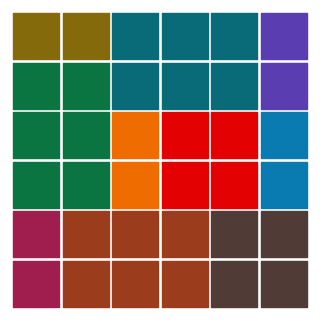

In [7]:
# Example rectangles (colors and tips taken from the repo example)
rectangles = {
    'yellow':  Rectangle((1, 2), RecType.ANY,      2, '#846A0B'),
    'teal':    Rectangle((1, 4), RecType.ANY,      6, '#096B78'),
    'purple':  Rectangle((2, 6), RecType.ANY,      2, '#5A3DB1'),
    'green':   Rectangle((3, 1), RecType.ANY,      6, '#0A7541'),
    'orange':  Rectangle((3, 3), RecType.VERTICAL, 2, '#EF6C00'),
    'red':     Rectangle((4, 4), RecType.SQUARE,   4, '#E30102'),
    'blue':    Rectangle((4, 6), RecType.ANY,      2, '#097BB1'),
    'magenta': Rectangle((5, 1), RecType.ANY,      2, '#A01E4E'),
    'brick':   Rectangle((6, 3), RecType.ANY,      6, '#9B3C1C'),
    'brown':   Rectangle((6, 5), RecType.ANY,      4, '#503B36')
}

patches = Patches((6,6), rectangles)
patches.solve()
patches.show()

Running above block, the method `show()` returns the solved game, which matches the official solution of Patches No. 16, as expected.

:::{figure} ../assets/5-patches/solution.jpg
:label: patches-solution
:alt: Patches solution
:align: center
:width: 50%
Solved instance visualization.
:::